# 07 — Probabilistic Forecasting and Liquidity Policy

## Objective

This notebook extends the frozen point-forecast model selected in Notebook 06 into a probabilistic forecasting and liquidity decision framework.

The notebook will:

1. Recover the 560 frozen out-of-sample predictions from the final universal point model.
2. Generate and evaluate predictive quantiles, including P50, P95 and P99.
3. Measure probabilistic accuracy using pinball loss, empirical coverage, interval width and calibration.
4. Model the joint distribution of cumulative cash outflow over the five-day funding lead time.
5. Translate forecast uncertainty into a cost-sensitive liquidity reserve policy.
6. Compare liquidity shortfall, idle capital, service level and total expected cost.

## Frozen decisions

The final universal point-forecast model is:

`calendar_promotion_trend_arima011_errors`

The following decisions are not reopened in this notebook:

* Point-model specification.
* Feature selection.
* ARIMA error order.
* Point-forecast back-transformation.
* Model ranking from Notebook 06.
* Settlement-aware model eligibility.
* Model-switching rules.

The probabilistic evaluation must use the same 20 expanding-window folds, 28 forecast horizons and 560 out-of-sample target dates used in the final model comparison.

## Methodological guardrails

* Out-of-sample forecast errors will be used as calibration evidence.
* In-sample residuals will not be presented as out-of-sample calibration results.
* Uncalibrated Gaussian intervals will not be treated as sufficient because non-Gaussian residual tails were previously documented.
* The five-day reserve will be estimated from cumulative simulated or resampled forecast paths.
* Daily P95 or P99 forecasts will not simply be added to define the principal reserve policy.
* All Notebook 07 artifacts will use the prefix `07_`.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display


# ---------------------------------------------------------------------
# Display configuration
# ---------------------------------------------------------------------
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


# ---------------------------------------------------------------------
# Frozen Notebook 07 constants
# ---------------------------------------------------------------------
NOTEBOOK_ID = "07"
NOTEBOOK_NAME = "probabilistic_forecasting_and_liquidity_policy"

FINAL_POINT_MODEL = "calendar_promotion_trend_arima011_errors"

EXPECTED_PREDICTION_ROWS = 560
EXPECTED_OUTER_FOLDS = 20
EXPECTED_FORECAST_HORIZONS = 28

FORECAST_HORIZON = 28
FUNDING_LEAD_TIME = 5

RANDOM_SEED = 42


# ---------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------
current_path = Path.cwd().resolve()

if current_path.name.lower() == "notebooks":
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path

# Local fallback used only when the notebook is started outside
# the project directory.
local_project_root = Path(
    r"C:\Users\Peter\ai-imaging-portfolio"
    r"\projects\06_fintech-liquidity-forecasting"
)

if not (PROJECT_ROOT / "data" / "processed").exists():
    if local_project_root.exists():
        PROJECT_ROOT = local_project_root
    else:
        raise FileNotFoundError(
            "The project root could not be located. "
            "Run the notebook from the project root or notebooks directory."
        )

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


print(f"Project root:        {PROJECT_ROOT}")
print(f"Processed data dir:  {DATA_PROCESSED_DIR}")
print(f"Figures dir:         {FIGURES_DIR}")
print(f"Funding lead time:   {FUNDING_LEAD_TIME} days")
print(f"Frozen point model:  {FINAL_POINT_MODEL}")

Project root:        C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting
Processed data dir:  C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed
Figures dir:         C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures
Funding lead time:   5 days
Frozen point model:  calendar_promotion_trend_arima011_errors


In [2]:
# ---------------------------------------------------------------------
# Notebook 06 handoff artifacts required at startup
# ---------------------------------------------------------------------
handoff_paths = {
    "notebook07_handoff": (
        DATA_PROCESSED_DIR / "06_notebook07_handoff.csv"
    ),
    "notebook06_technical_summary": (
        DATA_PROCESSED_DIR / "06_notebook06_technical_summary.csv"
    ),
    "final_point_model_selection": (
        DATA_PROCESSED_DIR / "06_final_point_model_selection.csv"
    ),
    "notebook06_artifact_registry": (
        DATA_PROCESSED_DIR / "06_notebook06_artifact_registry.csv"
    ),
    "final_universal_model_predictions": (
        DATA_PROCESSED_DIR / "06_final_universal_model_predictions.csv"
    ),
}


missing_files = [
    str(path)
    for path in handoff_paths.values()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Required Notebook 06 handoff artifacts are missing:\n"
        + "\n".join(missing_files)
    )


# ---------------------------------------------------------------------
# Load the frozen artifacts
# ---------------------------------------------------------------------
notebook07_handoff = pd.read_csv(
    handoff_paths["notebook07_handoff"]
)

notebook06_technical_summary = pd.read_csv(
    handoff_paths["notebook06_technical_summary"]
)

final_point_model_selection = pd.read_csv(
    handoff_paths["final_point_model_selection"]
)

notebook06_artifact_registry = pd.read_csv(
    handoff_paths["notebook06_artifact_registry"]
)

final_predictions = pd.read_csv(
    handoff_paths["final_universal_model_predictions"]
)


# ---------------------------------------------------------------------
# Small helper for expected column-name variants
# ---------------------------------------------------------------------
def find_column(dataframe, candidates, label):
    """Return the first available column from a bounded candidate list."""
    for candidate in candidates:
        if candidate in dataframe.columns:
            return candidate

    raise KeyError(
        f"No column was found for '{label}'. "
        f"Expected one of: {candidates}"
    )


fold_column = find_column(
    final_predictions,
    candidates=["fold_id", "outer_fold_id", "fold"],
    label="outer fold",
)

horizon_column = find_column(
    final_predictions,
    candidates=["forecast_horizon", "horizon", "h"],
    label="forecast horizon",
)

model_column = find_column(
    final_predictions,
    candidates=[
        "model_name",
        "selected_model",
        "final_model_name",
    ],
    label="model name",
)


# ---------------------------------------------------------------------
# Minimum startup facts only
# ---------------------------------------------------------------------
observed_models = sorted(
    final_predictions[model_column]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

observed_model_name = (
    observed_models[0]
    if len(observed_models) == 1
    else " | ".join(observed_models)
)

startup_audit = pd.DataFrame(
    [
        {
            "check": "prediction_rows",
            "observed": len(final_predictions),
            "expected": EXPECTED_PREDICTION_ROWS,
        },
        {
            "check": "outer_folds",
            "observed": final_predictions[fold_column].nunique(),
            "expected": EXPECTED_OUTER_FOLDS,
        },
        {
            "check": "forecast_horizons",
            "observed": final_predictions[horizon_column].nunique(),
            "expected": EXPECTED_FORECAST_HORIZONS,
        },
        {
            "check": "selected_model_name",
            "observed": observed_model_name,
            "expected": FINAL_POINT_MODEL,
        },
    ]
)

startup_audit["status"] = np.where(
    startup_audit["observed"].astype(str)
    == startup_audit["expected"].astype(str),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Save the startup audit in the same cell that generates it
# ---------------------------------------------------------------------
startup_audit_path = (
    DATA_PROCESSED_DIR / "07_notebook07_startup_audit.csv"
)

startup_audit.to_csv(startup_audit_path, index=False)

assert startup_audit_path.exists()
assert startup_audit["status"].eq("PASS").all(), (
    "Notebook 07 startup audit failed. "
    "Do not continue until the handoff inconsistency is resolved."
)


display(startup_audit)

print(
    "\nNotebook 07 startup handoff loaded successfully."
)
print(
    f"Saved startup audit: {startup_audit_path.name}"
)

,check,observed,expected,status
0,prediction_rows,560,560,PASS
1,outer_folds,20,20,PASS
2,forecast_horizons,28,28,PASS
3,selected_model_name,calendar_promotion_trend_arima011_errors,calendar_promotion_trend_arima011_errors,PASS



Notebook 07 startup handoff loaded successfully.
Saved startup audit: 07_notebook07_startup_audit.csv


## 1. Frozen out-of-sample probabilistic base

Probabilistic forecasts must be calibrated using errors generated outside the training sample.

The frozen Notebook 06 predictions provide one error observation for each combination of:

* Outer fold.
* Forecast origin.
* Forecast horizon.
* Target date.

Because the target and point forecasts are strictly positive, uncertainty will initially be analyzed using three complementary error representations:

$$
e_{t,h} = y_{t,h} - \hat{y}_{t,h}
$$

$$
r_{t,h} = \frac{y_{t,h}}{\hat{y}_{t,h}} - 1
$$

$$
\ell_{t,h} = \log\left(\frac{y_{t,h}}{\hat{y}_{t,h}}\right)
$$

The raw error is directly interpretable in ARS million. Relative and logarithmic errors are useful when forecast uncertainty changes with the predicted cash-outflow level.

The logarithmic representation also preserves positive simulated cash-outflow values when errors are added back to the point forecast.

Operational target-date conditions are retained only for probabilistic diagnostics. They are not added as new model features and do not reopen the frozen point-model specification.


In [3]:
# ---------------------------------------------------------------------
# Resolve the columns required for probabilistic forecasting
# ---------------------------------------------------------------------
actual_column = find_column(
    final_predictions,
    candidates=["actual", "observed", "y_true", "target"],
    label="actual cash outflow",
)

prediction_column = find_column(
    final_predictions,
    candidates=[
        "prediction",
        "point_forecast",
        "forecast",
        "y_pred",
    ],
    label="point prediction",
)

target_date_column = find_column(
    final_predictions,
    candidates=["target_date", "date", "forecast_date"],
    label="target date",
)

forecast_origin_candidates = [
    "forecast_origin",
    "origin_date",
    "train_end",
]

forecast_origin_column = next(
    (
        column
        for column in forecast_origin_candidates
        if column in final_predictions.columns
    ),
    None,
)


# ---------------------------------------------------------------------
# Construct the frozen prediction-level base
# ---------------------------------------------------------------------
rename_map = {
    fold_column: "fold_id",
    horizon_column: "forecast_horizon",
    model_column: "model_name",
    actual_column: "actual",
    prediction_column: "point_prediction",
    target_date_column: "target_date",
}

if forecast_origin_column is not None:
    rename_map[forecast_origin_column] = "forecast_origin"


probabilistic_base = (
    final_predictions
    .rename(columns=rename_map)
    .copy()
)

probabilistic_base["target_date"] = pd.to_datetime(
    probabilistic_base["target_date"],
    errors="coerce",
)

if "forecast_origin" in probabilistic_base.columns:
    probabilistic_base["forecast_origin"] = pd.to_datetime(
        probabilistic_base["forecast_origin"],
        errors="coerce",
    )

probabilistic_base["forecast_horizon"] = pd.to_numeric(
    probabilistic_base["forecast_horizon"],
    errors="raise",
).astype(int)

probabilistic_base["actual"] = pd.to_numeric(
    probabilistic_base["actual"],
    errors="raise",
)

probabilistic_base["point_prediction"] = pd.to_numeric(
    probabilistic_base["point_prediction"],
    errors="raise",
)


# ---------------------------------------------------------------------
# Recover target-date conditions from the Notebook 06 comparison table
# when they are not already present in the final prediction file.
# ---------------------------------------------------------------------
condition_candidates = [
    "is_weekend",
    "is_holiday",
    "is_payday",
    "is_payday_window",
    "is_month_end",
    "promotion_intensity",
    "merchant_settlement_intensity",
    "system_incident",
    "macro_shock",
]

available_conditions = [
    column
    for column in condition_candidates
    if column in probabilistic_base.columns
]

missing_conditions = [
    column
    for column in condition_candidates
    if column not in probabilistic_base.columns
]

conditions_source_path = (
    DATA_PROCESSED_DIR
    / "06_all_model_predictions_with_conditions.csv"
)

if missing_conditions and conditions_source_path.exists():
    conditions_source = pd.read_csv(conditions_source_path)

    conditions_fold_column = find_column(
        conditions_source,
        candidates=["fold_id", "outer_fold_id", "fold"],
        label="condition-table fold",
    )

    conditions_horizon_column = find_column(
        conditions_source,
        candidates=["forecast_horizon", "horizon", "h"],
        label="condition-table horizon",
    )

    conditions_date_column = find_column(
        conditions_source,
        candidates=["target_date", "date", "forecast_date"],
        label="condition-table target date",
    )

    conditions_model_column = find_column(
        conditions_source,
        candidates=[
            "model_name",
            "selected_model",
            "final_model_name",
        ],
        label="condition-table model name",
    )

    conditions_source = conditions_source.loc[
        conditions_source[conditions_model_column].astype(str)
        == FINAL_POINT_MODEL
    ].copy()

    conditions_source = conditions_source.rename(
        columns={
            conditions_fold_column: "fold_id",
            conditions_horizon_column: "forecast_horizon",
            conditions_date_column: "target_date",
        }
    )

    conditions_source["target_date"] = pd.to_datetime(
        conditions_source["target_date"],
        errors="coerce",
    )

    columns_to_merge = [
        column
        for column in missing_conditions
        if column in conditions_source.columns
    ]

    if columns_to_merge:
        conditions_for_merge = (
            conditions_source[
                [
                    "fold_id",
                    "forecast_horizon",
                    "target_date",
                    *columns_to_merge,
                ]
            ]
            .drop_duplicates(
                subset=[
                    "fold_id",
                    "forecast_horizon",
                    "target_date",
                ]
            )
        )

        probabilistic_base = probabilistic_base.merge(
            conditions_for_merge,
            on=[
                "fold_id",
                "forecast_horizon",
                "target_date",
            ],
            how="left",
            validate="one_to_one",
        )

available_conditions = [
    column
    for column in condition_candidates
    if column in probabilistic_base.columns
]


# ---------------------------------------------------------------------
# Create error representations
# Positive error means that the point model underpredicted the outflow.
# ---------------------------------------------------------------------
probabilistic_base["error"] = (
    probabilistic_base["actual"]
    - probabilistic_base["point_prediction"]
)

probabilistic_base["absolute_error"] = (
    probabilistic_base["error"].abs()
)

probabilistic_base["relative_error"] = (
    probabilistic_base["actual"]
    / probabilistic_base["point_prediction"]
    - 1.0
)

probabilistic_base["log_error"] = np.log(
    probabilistic_base["actual"]
    / probabilistic_base["point_prediction"]
)


# ---------------------------------------------------------------------
# Weekly forecast-horizon bands used in Notebook 06
# ---------------------------------------------------------------------
probabilistic_base["horizon_band"] = pd.cut(
    probabilistic_base["forecast_horizon"],
    bins=[0, 7, 14, 21, 28],
    labels=[
        "days_01_07",
        "days_08_14",
        "days_15_21",
        "days_22_28",
    ],
    include_lowest=True,
)


# ---------------------------------------------------------------------
# Relevant audit for probabilistic calibration and path construction
# ---------------------------------------------------------------------
fold_sizes = (
    probabilistic_base
    .groupby("fold_id", observed=True)
    .size()
)

probabilistic_base_audit = pd.DataFrame(
    [
        {
            "check": "prediction_rows",
            "observed": len(probabilistic_base),
            "expected": EXPECTED_PREDICTION_ROWS,
        },
        {
            "check": "nonpositive_actual_values",
            "observed": int(
                (probabilistic_base["actual"] <= 0).sum()
            ),
            "expected": 0,
        },
        {
            "check": "nonpositive_point_predictions",
            "observed": int(
                (
                    probabilistic_base["point_prediction"]
                    <= 0
                ).sum()
            ),
            "expected": 0,
        },
        {
            "check": "missing_target_dates",
            "observed": int(
                probabilistic_base["target_date"].isna().sum()
            ),
            "expected": 0,
        },
        {
            "check": "nonfinite_log_errors",
            "observed": int(
                (
                    ~np.isfinite(
                        probabilistic_base["log_error"]
                    )
                ).sum()
            ),
            "expected": 0,
        },
        {
            "check": "duplicate_fold_horizon_rows",
            "observed": int(
                probabilistic_base.duplicated(
                    subset=["fold_id", "forecast_horizon"]
                ).sum()
            ),
            "expected": 0,
        },
        {
            "check": "folds_with_28_ordered_rows",
            "observed": int(
                (fold_sizes == FORECAST_HORIZON).sum()
            ),
            "expected": EXPECTED_OUTER_FOLDS,
        },
        {
            "check": "horizon_bands",
            "observed": int(
                probabilistic_base["horizon_band"].nunique()
            ),
            "expected": 4,
        },
    ]
)

probabilistic_base_audit["status"] = np.where(
    probabilistic_base_audit["observed"].astype(str)
    == probabilistic_base_audit["expected"].astype(str),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Summarize available operational-condition support
# ---------------------------------------------------------------------
def condition_is_active(series):
    """Convert binary or intensity condition columns to active flags."""
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)

    numeric_values = pd.to_numeric(series, errors="coerce")

    if numeric_values.notna().any():
        return numeric_values.fillna(0).gt(0)

    normalized_values = (
        series.astype(str)
        .str.strip()
        .str.lower()
    )

    return normalized_values.isin(
        ["true", "1", "yes", "active"]
    )


condition_support_rows = []

for condition in available_conditions:
    active_flag = condition_is_active(
        probabilistic_base[condition]
    )

    condition_support_rows.append(
        {
            "condition": condition,
            "available_rows": int(
                probabilistic_base[condition].notna().sum()
            ),
            "active_target_dates": int(active_flag.sum()),
            "active_share_percent": float(
                100 * active_flag.mean()
            ),
        }
    )

condition_support = pd.DataFrame(condition_support_rows)


# ---------------------------------------------------------------------
# Sort and save all outputs generated by this cell
# ---------------------------------------------------------------------
sort_columns = ["fold_id", "forecast_horizon"]

probabilistic_base = (
    probabilistic_base
    .sort_values(sort_columns)
    .reset_index(drop=True)
)

probabilistic_base_path = (
    DATA_PROCESSED_DIR
    / "07_frozen_oos_probabilistic_base.csv"
)

probabilistic_base_audit_path = (
    DATA_PROCESSED_DIR
    / "07_frozen_oos_probabilistic_base_audit.csv"
)

condition_support_path = (
    DATA_PROCESSED_DIR
    / "07_operational_condition_support.csv"
)

probabilistic_base.to_csv(
    probabilistic_base_path,
    index=False,
)

probabilistic_base_audit.to_csv(
    probabilistic_base_audit_path,
    index=False,
)

condition_support.to_csv(
    condition_support_path,
    index=False,
)


assert probabilistic_base_path.exists()
assert probabilistic_base_audit_path.exists()
assert condition_support_path.exists()

assert probabilistic_base_audit["status"].eq("PASS").all(), (
    "The probabilistic base audit failed. "
    "Do not continue with uncertainty calibration."
)


display(probabilistic_base_audit)

print("\nAvailable operational conditions:")
display(condition_support)

print(
    "\nSaved probabilistic base:",
    probabilistic_base_path.name,
)

,check,observed,expected,status
0,prediction_rows,560,560,PASS
1,nonpositive_actual_values,0,0,PASS
2,nonpositive_point_predictions,0,0,PASS
3,missing_target_dates,0,0,PASS
4,nonfinite_log_errors,0,0,PASS
5,duplicate_fold_horizon_rows,0,0,PASS
6,folds_with_28_ordered_rows,20,20,PASS
7,horizon_bands,4,4,PASS



Available operational conditions:


,condition,available_rows,active_target_dates,active_share_percent
0,is_weekend,560,160,28.5714
1,is_holiday,560,32,5.7143
2,is_payday_window,560,108,19.2857
3,is_month_end,560,19,3.3929
4,promotion_intensity,560,16,2.8571
5,merchant_settlement_intensity,560,3,0.5357



Saved probabilistic base: 07_frozen_oos_probabilistic_base.csv


## 2. Probabilistic evaluation protocol

Probabilistic calibration must precede the fold being evaluated.

The first five outer folds are therefore used as an initial out-of-sample calibration period. They provide:

* 140 out-of-sample forecast errors.
* Five complete 28-day forecast-error paths.
* No information from the folds used for probabilistic evaluation.

Probabilistic performance is evaluated prequentially over folds 6–20. For every evaluation fold, the calibration sample contains only errors from earlier folds and expands through time.

This produces:

```text
Initial calibration folds: 5
Probabilistic evaluation folds: 15
Probabilistic evaluation rows: 420
```

The first five folds are not discarded. They initialize the uncertainty model and will also be included when the final selected probabilistic method is calibrated using all available out-of-sample errors.

### Quantiles

The principal reported quantiles are:

```text
P50, P95 and P99
```

The auxiliary lower quantiles P01 and P05 are also generated so that central predictive intervals can be evaluated:

$$
PI_{90} = [P05, P95]
$$

$$
PI_{98} = [P01, P99]
$$

### Bounded candidate set

Three fixed methods will be compared:

1. **Gaussian log-error benchmark**

   Estimates a normal distribution from prior out-of-sample logarithmic errors. It is included only as a benchmark because non-Gaussian tails were previously documented.

2. **Expanding empirical log-error quantiles**

   Uses finite-sample empirical quantiles from all prior out-of-sample logarithmic errors. It makes no Gaussian assumption.

3. **Shrunk horizon-band empirical log-error quantiles**

   Combines the empirical quantile of the corresponding seven-day horizon band with the pooled empirical quantile. Shrinkage limits instability when the horizon-band sample remains small.

For all methods, the uncertainty correction for fold $$k$$ is estimated only from folds preceding $$k$$.


In [4]:
# ---------------------------------------------------------------------
# Frozen probabilistic-evaluation configuration
# ---------------------------------------------------------------------
INITIAL_CALIBRATION_FOLDS = 5

PROBABILISTIC_QUANTILES = [
    0.01,
    0.05,
    0.50,
    0.95,
    0.99,
]

SHRINKAGE_STRENGTH = 70

EXPECTED_PROBABILISTIC_EVALUATION_FOLDS = (
    EXPECTED_OUTER_FOLDS
    - INITIAL_CALIBRATION_FOLDS
)

EXPECTED_PROBABILISTIC_EVALUATION_ROWS = (
    EXPECTED_PROBABILISTIC_EVALUATION_FOLDS
    * FORECAST_HORIZON
)


# ---------------------------------------------------------------------
# Recover the chronological fold order from target dates rather than
# relying on the textual or numeric format of fold_id.
# ---------------------------------------------------------------------
fold_order = (
    probabilistic_base
    .groupby("fold_id", as_index=False)
    .agg(
        fold_start=("target_date", "min"),
        fold_end=("target_date", "max"),
        fold_rows=("target_date", "size"),
    )
    .sort_values("fold_start")
    .reset_index(drop=True)
)

fold_order["fold_sequence"] = np.arange(
    1,
    len(fold_order) + 1,
)

fold_order["probabilistic_role"] = np.where(
    fold_order["fold_sequence"]
    <= INITIAL_CALIBRATION_FOLDS,
    "initial_calibration",
    "prequential_evaluation",
)

fold_order["prior_calibration_folds"] = (
    fold_order["fold_sequence"] - 1
)

fold_order["prior_calibration_rows"] = (
    fold_order["prior_calibration_folds"]
    * FORECAST_HORIZON
)

fold_order["probabilistic_evaluation_rows"] = np.where(
    fold_order["probabilistic_role"]
    == "prequential_evaluation",
    fold_order["fold_rows"],
    0,
)


# ---------------------------------------------------------------------
# Verify that each evaluation fold begins strictly after every fold
# available for its calibration.
# ---------------------------------------------------------------------
temporal_order_checks = []

for row in fold_order.itertuples(index=False):
    if row.probabilistic_role != "prequential_evaluation":
        continue

    prior_folds = fold_order.loc[
        fold_order["fold_sequence"] < row.fold_sequence,
        "fold_id",
    ]

    maximum_prior_date = (
        probabilistic_base.loc[
            probabilistic_base["fold_id"].isin(prior_folds),
            "target_date",
        ]
        .max()
    )

    temporal_order_checks.append(
        maximum_prior_date < row.fold_start
    )

all_temporal_order_checks_pass = bool(
    all(temporal_order_checks)
)


# ---------------------------------------------------------------------
# Freeze the bounded probabilistic candidate set
# ---------------------------------------------------------------------
probabilistic_method_registry = pd.DataFrame(
    [
        {
            "method_id": "gaussian_log_expanding",
            "error_representation": "log_error",
            "calibration_scope": "pooled_prior_folds",
            "distribution_assumption": "gaussian",
            "horizon_adaptation": "none",
            "selection_role": "benchmark",
            "non_gaussian_tail_protection": False,
        },
        {
            "method_id": "empirical_log_expanding",
            "error_representation": "log_error",
            "calibration_scope": "pooled_prior_folds",
            "distribution_assumption": "empirical",
            "horizon_adaptation": "none",
            "selection_role": "eligible_candidate",
            "non_gaussian_tail_protection": True,
        },
        {
            "method_id": "empirical_log_horizon_band_shrunk",
            "error_representation": "log_error",
            "calibration_scope": (
                "prior_folds_pooled_and_horizon_band"
            ),
            "distribution_assumption": "empirical",
            "horizon_adaptation": (
                "seven_day_band_with_pooled_shrinkage"
            ),
            "selection_role": "eligible_candidate",
            "non_gaussian_tail_protection": True,
        },
    ]
)


# ---------------------------------------------------------------------
# Compact protocol audit
# ---------------------------------------------------------------------
probabilistic_protocol_audit = pd.DataFrame(
    [
        {
            "check": "outer_folds_registered",
            "observed": len(fold_order),
            "expected": EXPECTED_OUTER_FOLDS,
        },
        {
            "check": "initial_calibration_folds",
            "observed": int(
                (
                    fold_order["probabilistic_role"]
                    == "initial_calibration"
                ).sum()
            ),
            "expected": INITIAL_CALIBRATION_FOLDS,
        },
        {
            "check": "probabilistic_evaluation_folds",
            "observed": int(
                (
                    fold_order["probabilistic_role"]
                    == "prequential_evaluation"
                ).sum()
            ),
            "expected": (
                EXPECTED_PROBABILISTIC_EVALUATION_FOLDS
            ),
        },
        {
            "check": "probabilistic_evaluation_rows",
            "observed": int(
                fold_order[
                    "probabilistic_evaluation_rows"
                ].sum()
            ),
            "expected": (
                EXPECTED_PROBABILISTIC_EVALUATION_ROWS
            ),
        },
        {
            "check": "minimum_prior_calibration_rows",
            "observed": int(
                fold_order.loc[
                    fold_order["probabilistic_role"]
                    == "prequential_evaluation",
                    "prior_calibration_rows",
                ].min()
            ),
            "expected": (
                INITIAL_CALIBRATION_FOLDS
                * FORECAST_HORIZON
            ),
        },
        {
            "check": "strict_prior_fold_calibration",
            "observed": all_temporal_order_checks_pass,
            "expected": True,
        },
        {
            "check": "frozen_probabilistic_methods",
            "observed": len(
                probabilistic_method_registry
            ),
            "expected": 3,
        },
        {
            "check": "required_quantiles",
            "observed": " | ".join(
                f"P{int(quantile * 100):02d}"
                for quantile in PROBABILISTIC_QUANTILES
            ),
            "expected": "P01 | P05 | P50 | P95 | P99",
        },
    ]
)

probabilistic_protocol_audit["status"] = np.where(
    probabilistic_protocol_audit["observed"].astype(str)
    == probabilistic_protocol_audit["expected"].astype(str),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Save every table generated by this cell
# ---------------------------------------------------------------------
fold_protocol_path = (
    DATA_PROCESSED_DIR
    / "07_probabilistic_fold_protocol.csv"
)

method_registry_path = (
    DATA_PROCESSED_DIR
    / "07_probabilistic_method_registry.csv"
)

protocol_audit_path = (
    DATA_PROCESSED_DIR
    / "07_probabilistic_protocol_audit.csv"
)

fold_order.to_csv(
    fold_protocol_path,
    index=False,
)

probabilistic_method_registry.to_csv(
    method_registry_path,
    index=False,
)

probabilistic_protocol_audit.to_csv(
    protocol_audit_path,
    index=False,
)


assert fold_protocol_path.exists()
assert method_registry_path.exists()
assert protocol_audit_path.exists()

assert probabilistic_protocol_audit[
    "status"
].eq("PASS").all(), (
    "The probabilistic evaluation protocol failed its audit."
)


display(probabilistic_protocol_audit)

print("\nFrozen candidate methods:")
display(probabilistic_method_registry)

print("\nChronological fold protocol:")
display(
    fold_order[
        [
            "fold_id",
            "fold_sequence",
            "fold_start",
            "fold_end",
            "probabilistic_role",
            "prior_calibration_rows",
        ]
    ]
)

,check,observed,expected,status
0,outer_folds_registered,20,20,PASS
1,initial_calibration_folds,5,5,PASS
2,probabilistic_evaluation_folds,15,15,PASS
3,probabilistic_evaluation_rows,420,420,PASS
4,minimum_prior_calibration_rows,140,140,PASS
5,strict_prior_fold_calibration,True,True,PASS
6,frozen_probabilistic_methods,3,3,PASS
7,required_quantiles,P01 | P05 | P50 | P95 | P99,P01 | P05 | P50 | P95 | P99,PASS



Frozen candidate methods:


,method_id,error_representation,calibration_scope,distribution_assumption,horizon_adaptation,selection_role,non_gaussian_tail_protection
0,gaussian_log_expanding,log_error,pooled_prior_folds,gaussian,none,benchmark,False
1,empirical_log_expanding,log_error,pooled_prior_folds,empirical,none,eligible_candidate,True
2,empirical_log_horizon_band_shrunk,log_error,prior_folds_pooled_and_horizon_band,empirical,seven_day_band_with_pooled_shrinkage,eligible_candidate,True



Chronological fold protocol:


,fold_id,fold_sequence,fold_start,fold_end,probabilistic_role,prior_calibration_rows
0,fold_01,1,2025-01-18,2025-02-14,initial_calibration,0
1,fold_02,2,2025-02-15,2025-03-14,initial_calibration,28
2,fold_03,3,2025-03-15,2025-04-11,initial_calibration,56
3,fold_04,4,2025-04-12,2025-05-09,initial_calibration,84
4,fold_05,5,2025-05-10,2025-06-06,initial_calibration,112
5,fold_06,6,2025-06-07,2025-07-04,prequential_evaluation,140
6,fold_07,7,2025-07-05,2025-08-01,prequential_evaluation,168
7,fold_08,8,2025-08-02,2025-08-29,prequential_evaluation,196
8,fold_09,9,2025-08-30,2025-09-26,prequential_evaluation,224
9,fold_10,10,2025-09-27,2025-10-24,prequential_evaluation,252


## 3. Prequential predictive quantiles

For each probabilistic evaluation fold, uncertainty is estimated exclusively from out-of-sample errors observed in previous folds.

For a point prediction $$\hat{y}_{t,h}$$ and a logarithmic-error quantile $$Q_q(\ell)$$, the predictive quantile is:

$$
\hat{Q}_{q,t,h}
=
\hat{y}_{t,h}
\exp\left(Q_q(\ell)\right)
$$

This transformation guarantees positive predictive quantiles.

The Gaussian benchmark estimates:

$$
Q_q(\ell)
=
\hat{\mu}_{\ell}
+
z_q\hat{\sigma}_{\ell}
$$

The pooled empirical method directly estimates each quantile from all previous out-of-sample logarithmic errors.

The horizon-band method combines pooled and band-specific empirical quantiles:

$$
\widetilde{Q}_{q,b}
=
w_b Q_{q,b}
+
(1-w_b)Q_{q,\text{pooled}}
$$

where:

$$
w_b
=
\frac{n_b}{n_b+\lambda}
$$

and $$\lambda=70$$ is a fixed shrinkage strength. It is not tuned using the probabilistic evaluation folds.

Conditions such as holidays and promotions are not used for calibration at this stage. Fragmenting the calibration sample by condition would produce unstable tail estimates, especially for P95 and P99.

In [5]:
from statistics import NormalDist


# ---------------------------------------------------------------------
# Fixed quantile-generation settings
# ---------------------------------------------------------------------
EMPIRICAL_QUANTILE_METHOD = "linear"

QUANTILE_COLUMN_MAP = {
    0.01: "p01",
    0.05: "p05",
    0.50: "p50",
    0.95: "p95",
    0.99: "p99",
}

normal_distribution = NormalDist()

normal_z_scores = {
    quantile: normal_distribution.inv_cdf(quantile)
    for quantile in PROBABILISTIC_QUANTILES
}


# ---------------------------------------------------------------------
# Attach the chronological fold sequence to the frozen OOS base
# ---------------------------------------------------------------------
fold_sequence_map = fold_order[
    ["fold_id", "fold_sequence", "probabilistic_role"]
].copy()

probabilistic_generation_base = probabilistic_base.merge(
    fold_sequence_map,
    on="fold_id",
    how="left",
    validate="many_to_one",
)

probabilistic_generation_base = (
    probabilistic_generation_base
    .sort_values(["fold_sequence", "forecast_horizon"])
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------
def empirical_quantiles(values, quantiles):
    """Estimate empirical quantiles using a fixed interpolation rule."""
    clean_values = np.asarray(values, dtype=float)

    if clean_values.size == 0:
        raise ValueError(
            "Empirical quantiles cannot be estimated from an empty sample."
        )

    estimated_values = np.quantile(
        clean_values,
        quantiles,
        method=EMPIRICAL_QUANTILE_METHOD,
    )

    return {
        quantile: float(value)
        for quantile, value in zip(
            quantiles,
            estimated_values,
        )
    }


def predictive_quantile(point_prediction, log_error_quantile):
    """Transform a logarithmic-error quantile to the original scale."""
    return float(
        point_prediction
        * np.exp(log_error_quantile)
    )


# ---------------------------------------------------------------------
# Generate each evaluation fold using only prior OOS folds
# ---------------------------------------------------------------------
probabilistic_prediction_frames = []

evaluation_sequences = (
    fold_order.loc[
        fold_order["probabilistic_role"]
        == "prequential_evaluation",
        "fold_sequence",
    ]
    .sort_values()
    .tolist()
)

for evaluation_sequence in evaluation_sequences:

    calibration_data = probabilistic_generation_base.loc[
        probabilistic_generation_base["fold_sequence"]
        < evaluation_sequence
    ].copy()

    evaluation_data = probabilistic_generation_base.loc[
        probabilistic_generation_base["fold_sequence"]
        == evaluation_sequence
    ].copy()

    calibration_log_errors = (
        calibration_data["log_error"]
        .to_numpy(dtype=float)
    )

    calibration_rows = len(calibration_data)
    calibration_folds = (
        calibration_data["fold_id"].nunique()
    )

    calibration_start = calibration_data[
        "target_date"
    ].min()

    calibration_end = calibration_data[
        "target_date"
    ].max()

    pooled_empirical_quantiles = empirical_quantiles(
        calibration_log_errors,
        PROBABILISTIC_QUANTILES,
    )

    gaussian_location = float(
        np.mean(calibration_log_errors)
    )

    gaussian_scale = float(
        np.std(
            calibration_log_errors,
            ddof=1,
        )
    )

    gaussian_log_quantiles = {
        quantile: (
            gaussian_location
            + normal_z_scores[quantile]
            * gaussian_scale
        )
        for quantile in PROBABILISTIC_QUANTILES
    }

    # -------------------------------------------------------------
    # Candidate 1: Gaussian benchmark
    # -------------------------------------------------------------
    gaussian_predictions = evaluation_data.copy()

    gaussian_predictions["method_id"] = (
        "gaussian_log_expanding"
    )

    gaussian_predictions["calibration_rows"] = (
        calibration_rows
    )

    gaussian_predictions["calibration_folds"] = (
        calibration_folds
    )

    gaussian_predictions["calibration_start"] = (
        calibration_start
    )

    gaussian_predictions["calibration_end"] = (
        calibration_end
    )

    gaussian_predictions["band_calibration_rows"] = np.nan
    gaussian_predictions["horizon_band_weight"] = np.nan
    gaussian_predictions["gaussian_location"] = gaussian_location
    gaussian_predictions["gaussian_scale"] = gaussian_scale

    for quantile, output_column in QUANTILE_COLUMN_MAP.items():
        gaussian_predictions[output_column] = (
            gaussian_predictions["point_prediction"]
            .apply(
                lambda point_prediction: predictive_quantile(
                    point_prediction,
                    gaussian_log_quantiles[quantile],
                )
            )
        )

    probabilistic_prediction_frames.append(
        gaussian_predictions
    )

    # -------------------------------------------------------------
    # Candidate 2: pooled empirical log errors
    # -------------------------------------------------------------
    empirical_predictions = evaluation_data.copy()

    empirical_predictions["method_id"] = (
        "empirical_log_expanding"
    )

    empirical_predictions["calibration_rows"] = (
        calibration_rows
    )

    empirical_predictions["calibration_folds"] = (
        calibration_folds
    )

    empirical_predictions["calibration_start"] = (
        calibration_start
    )

    empirical_predictions["calibration_end"] = (
        calibration_end
    )

    empirical_predictions["band_calibration_rows"] = np.nan
    empirical_predictions["horizon_band_weight"] = np.nan
    empirical_predictions["gaussian_location"] = np.nan
    empirical_predictions["gaussian_scale"] = np.nan

    for quantile, output_column in QUANTILE_COLUMN_MAP.items():
        empirical_predictions[output_column] = (
            empirical_predictions["point_prediction"]
            .apply(
                lambda point_prediction: predictive_quantile(
                    point_prediction,
                    pooled_empirical_quantiles[quantile],
                )
            )
        )

    probabilistic_prediction_frames.append(
        empirical_predictions
    )

    # -------------------------------------------------------------
    # Candidate 3: empirical horizon-band quantiles with shrinkage
    # -------------------------------------------------------------
    band_prediction_frames = []

    for horizon_band, band_evaluation_data in (
        evaluation_data.groupby(
            "horizon_band",
            observed=True,
        )
    ):
        band_calibration_data = calibration_data.loc[
            calibration_data["horizon_band"]
            == horizon_band
        ]

        band_calibration_rows = len(
            band_calibration_data
        )

        band_empirical_quantiles = empirical_quantiles(
            band_calibration_data["log_error"],
            PROBABILISTIC_QUANTILES,
        )

        horizon_band_weight = (
            band_calibration_rows
            / (
                band_calibration_rows
                + SHRINKAGE_STRENGTH
            )
        )

        shrunk_log_quantiles = {
            quantile: (
                horizon_band_weight
                * band_empirical_quantiles[quantile]
                + (1.0 - horizon_band_weight)
                * pooled_empirical_quantiles[quantile]
            )
            for quantile in PROBABILISTIC_QUANTILES
        }

        band_predictions = band_evaluation_data.copy()

        band_predictions["method_id"] = (
            "empirical_log_horizon_band_shrunk"
        )

        band_predictions["calibration_rows"] = (
            calibration_rows
        )

        band_predictions["calibration_folds"] = (
            calibration_folds
        )

        band_predictions["calibration_start"] = (
            calibration_start
        )

        band_predictions["calibration_end"] = (
            calibration_end
        )

        band_predictions["band_calibration_rows"] = (
            band_calibration_rows
        )

        band_predictions["horizon_band_weight"] = (
            horizon_band_weight
        )

        band_predictions["gaussian_location"] = np.nan
        band_predictions["gaussian_scale"] = np.nan

        for quantile, output_column in (
            QUANTILE_COLUMN_MAP.items()
        ):
            band_predictions[output_column] = (
                band_predictions["point_prediction"]
                .apply(
                    lambda point_prediction: predictive_quantile(
                        point_prediction,
                        shrunk_log_quantiles[quantile],
                    )
                )
            )

        band_prediction_frames.append(
            band_predictions
        )

    probabilistic_prediction_frames.append(
        pd.concat(
            band_prediction_frames,
            ignore_index=True,
        )
    )


# ---------------------------------------------------------------------
# Canonical prediction-level probabilistic table
# ---------------------------------------------------------------------
probabilistic_predictions = pd.concat(
    probabilistic_prediction_frames,
    ignore_index=True,
)

probabilistic_predictions = (
    probabilistic_predictions
    .sort_values(
        [
            "method_id",
            "fold_sequence",
            "forecast_horizon",
        ]
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Method-level generation summary
# ---------------------------------------------------------------------
probabilistic_generation_summary = (
    probabilistic_predictions
    .groupby("method_id", as_index=False)
    .agg(
        prediction_rows=("actual", "size"),
        evaluation_folds=("fold_id", "nunique"),
        forecast_horizons=(
            "forecast_horizon",
            "nunique",
        ),
        minimum_calibration_rows=(
            "calibration_rows",
            "min",
        ),
        maximum_calibration_rows=(
            "calibration_rows",
            "max",
        ),
        minimum_p50=("p50", "min"),
        maximum_p99=("p99", "max"),
    )
)


# ---------------------------------------------------------------------
# Quantile-order and structural audit
# ---------------------------------------------------------------------
quantile_columns = [
    "p01",
    "p05",
    "p50",
    "p95",
    "p99",
]

quantile_values = probabilistic_predictions[
    quantile_columns
].to_numpy(dtype=float)

quantile_order_violations = int(
    (
        np.diff(
            quantile_values,
            axis=1,
        ) < 0
    )
    .any(axis=1)
    .sum()
)

nonpositive_quantiles = int(
    (quantile_values <= 0).sum()
)

nonfinite_quantiles = int(
    (~np.isfinite(quantile_values)).sum()
)

duplicate_prediction_keys = int(
    probabilistic_predictions.duplicated(
        subset=[
            "method_id",
            "fold_id",
            "forecast_horizon",
        ]
    ).sum()
)

prior_fold_calibration_violations = int(
    (
        probabilistic_predictions[
            "calibration_folds"
        ]
        != (
            probabilistic_predictions[
                "fold_sequence"
            ] - 1
        )
    ).sum()
)

method_row_counts = (
    probabilistic_predictions
    .groupby("method_id")
    .size()
)

probabilistic_generation_audit = pd.DataFrame(
    [
        {
            "check": "generated_methods",
            "observed": (
                probabilistic_predictions[
                    "method_id"
                ].nunique()
            ),
            "expected": 3,
        },
        {
            "check": "total_probabilistic_rows",
            "observed": len(
                probabilistic_predictions
            ),
            "expected": (
                3
                * EXPECTED_PROBABILISTIC_EVALUATION_ROWS
            ),
        },
        {
            "check": "methods_with_420_rows",
            "observed": int(
                (
                    method_row_counts
                    == EXPECTED_PROBABILISTIC_EVALUATION_ROWS
                ).sum()
            ),
            "expected": 3,
        },
        {
            "check": "evaluation_folds_per_method",
            "observed": int(
                probabilistic_predictions
                .groupby("method_id")["fold_id"]
                .nunique()
                .min()
            ),
            "expected": (
                EXPECTED_PROBABILISTIC_EVALUATION_FOLDS
            ),
        },
        {
            "check": "minimum_calibration_rows",
            "observed": int(
                probabilistic_predictions[
                    "calibration_rows"
                ].min()
            ),
            "expected": 140,
        },
        {
            "check": "maximum_calibration_rows",
            "observed": int(
                probabilistic_predictions[
                    "calibration_rows"
                ].max()
            ),
            "expected": 532,
        },
        {
            "check": "prior_fold_calibration_violations",
            "observed": (
                prior_fold_calibration_violations
            ),
            "expected": 0,
        },
        {
            "check": "duplicate_prediction_keys",
            "observed": duplicate_prediction_keys,
            "expected": 0,
        },
        {
            "check": "nonfinite_quantiles",
            "observed": nonfinite_quantiles,
            "expected": 0,
        },
        {
            "check": "nonpositive_quantiles",
            "observed": nonpositive_quantiles,
            "expected": 0,
        },
        {
            "check": "quantile_order_violations",
            "observed": quantile_order_violations,
            "expected": 0,
        },
    ]
)

probabilistic_generation_audit["status"] = np.where(
    probabilistic_generation_audit[
        "observed"
    ].astype(str)
    == probabilistic_generation_audit[
        "expected"
    ].astype(str),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Save all generated artifacts
# ---------------------------------------------------------------------
probabilistic_predictions_path = (
    DATA_PROCESSED_DIR
    / "07_prequential_probabilistic_predictions.csv"
)

probabilistic_generation_summary_path = (
    DATA_PROCESSED_DIR
    / "07_probabilistic_generation_summary.csv"
)

probabilistic_generation_audit_path = (
    DATA_PROCESSED_DIR
    / "07_probabilistic_generation_audit.csv"
)

probabilistic_predictions.to_csv(
    probabilistic_predictions_path,
    index=False,
)

probabilistic_generation_summary.to_csv(
    probabilistic_generation_summary_path,
    index=False,
)

probabilistic_generation_audit.to_csv(
    probabilistic_generation_audit_path,
    index=False,
)


assert probabilistic_predictions_path.exists()
assert probabilistic_generation_summary_path.exists()
assert probabilistic_generation_audit_path.exists()

assert probabilistic_generation_audit[
    "status"
].eq("PASS").all(), (
    "Prequential quantile generation failed its audit."
)


display(probabilistic_generation_audit)

print("\nProbabilistic generation summary:")
display(probabilistic_generation_summary)

print("\nExample predictions from the first evaluation fold:")
display(
    probabilistic_predictions[
        [
            "method_id",
            "fold_id",
            "forecast_horizon",
            "actual",
            "point_prediction",
            "p01",
            "p05",
            "p50",
            "p95",
            "p99",
            "calibration_rows",
        ]
    ]
    .groupby("method_id", as_index=False)
    .head(2)
)

,check,observed,expected,status
0,generated_methods,3,3,PASS
1,total_probabilistic_rows,1260,1260,PASS
2,methods_with_420_rows,3,3,PASS
3,evaluation_folds_per_method,15,15,PASS
4,minimum_calibration_rows,140,140,PASS
5,maximum_calibration_rows,532,532,PASS
6,prior_fold_calibration_violations,0,0,PASS
7,duplicate_prediction_keys,0,0,PASS
8,nonfinite_quantiles,0,0,PASS
9,nonpositive_quantiles,0,0,PASS



Probabilistic generation summary:


,method_id,prediction_rows,evaluation_folds,forecast_horizons,minimum_calibration_rows,maximum_calibration_rows,minimum_p50,maximum_p99
0,empirical_log_expanding,420,15,28,140,532,471.5270,"2,209.5325"
1,empirical_log_horizon_band_shrunk,420,15,28,140,532,465.3232,"2,214.3529"
2,gaussian_log_expanding,420,15,28,140,532,471.2606,"2,252.2136"



Example predictions from the first evaluation fold:


,method_id,fold_id,forecast_horizon,actual,point_prediction,p01,p05,p50,p95,p99,calibration_rows
0,empirical_log_expanding,fold_06,1,697.6330,625.5003,514.0158,529.8856,617.3763,737.1476,812.1681,140
1,empirical_log_expanding,fold_06,2,573.8670,495.5463,407.2238,419.7965,489.1102,583.9977,643.4320,140
420,empirical_log_horizon_band_shrunk,fold_06,1,697.6330,625.5003,508.4818,534.4766,623.0302,733.2655,795.5740,140
421,empirical_log_horizon_band_shrunk,fold_06,2,573.8670,495.5463,402.8396,423.4337,493.5894,580.9222,630.2854,140
840,gaussian_log_expanding,fold_06,1,697.6330,625.5003,488.2561,522.9357,617.1275,728.2852,780.0134,140
841,gaussian_log_expanding,fold_06,2,573.8670,495.5463,386.8160,414.2905,488.9130,576.9766,617.9577,140


## 4. Global probabilistic evaluation

For a predictive quantile $$\hat{Q}_q$$ and an observed value $$y$$, the pinball loss is:

$$
L_q(y,\hat{Q}_q)
=
\begin{cases}
q(y-\hat{Q}_q), & y \geq \hat{Q}_q \\
(1-q)(\hat{Q}_q-y), & y < \hat{Q}_q
\end{cases}
$$

Lower pinball loss indicates a more accurate predictive quantile.

Quantile calibration is evaluated using:

$$
\widehat{C}_q
=
\frac{1}{N}
\sum_{i=1}^{N}
\mathbb{1}(y_i \leq \hat{Q}_{q,i})
$$

A calibrated P95 should therefore satisfy:

$$
\widehat{C}_{0.95} \approx 0.95
$$

Two central predictive intervals are evaluated:

$$
PI_{90}=[P05,P95]
$$

$$
PI_{98}=[P01,P99]
$$

Coverage alone is insufficient because an excessively wide interval can obtain high coverage. Interval width and interval score are therefore reported together with empirical coverage.

P01 and P99 contain limited effective tail information in a sample of 420 observations. Their results must be interpreted as finite-sample evidence rather than exact proof of extreme-tail calibration.

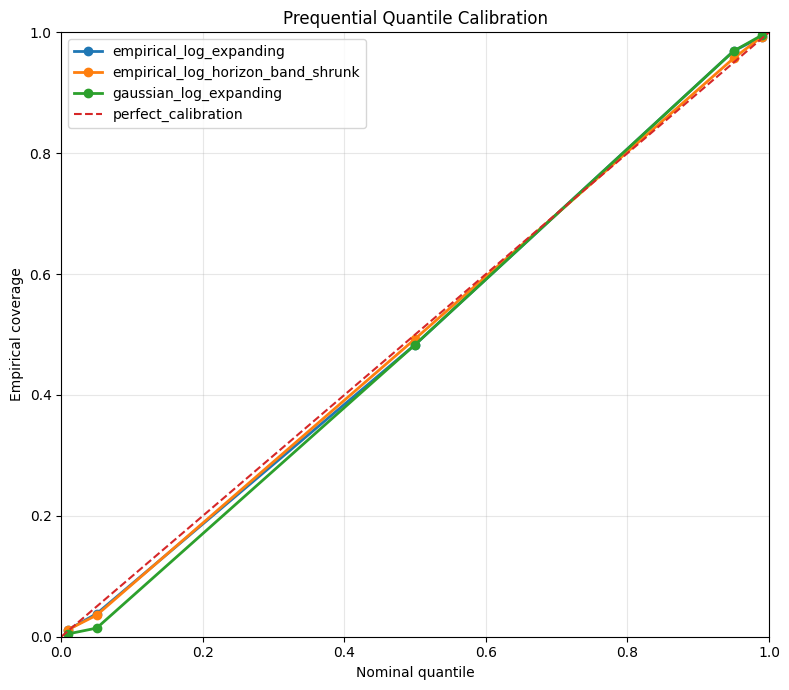

,check,observed,expected,status
0,quantile_metric_rows,15,15,PASS
1,interval_metric_rows,6,6,PASS
2,methods_in_summary,3,3,PASS
3,observations_per_quantile_metric,420,420,PASS
4,nonfinite_quantile_metrics,0,0,PASS
5,coverage_out_of_bounds,0,0,PASS
6,negative_interval_widths,0,0,PASS
7,calibration_figure_created,True,True,PASS



Global quantile metrics:


,method_id,nominal_quantile,quantile_label,observations,mean_actual,mean_predicted_quantile,mean_pinball_loss,empirical_coverage,calibration_error,absolute_calibration_error
0,empirical_log_expanding,0.0100,P01,420,962.5186,800.4123,2.4608,0.0119,0.0019,0.0019
1,empirical_log_expanding,0.0500,P05,420,962.5186,832.5576,8.1198,0.0381,-0.0119,0.0119
2,empirical_log_expanding,0.5000,P50,420,962.5186,956.1896,32.5181,0.4833,-0.0167,0.0167
3,empirical_log_expanding,0.9500,P95,420,962.5186,"1,113.2189",10.5325,0.9690,0.0190,0.0190
4,empirical_log_expanding,0.9900,P99,420,962.5186,"1,182.7921",4.0275,0.9929,0.0029,0.0029
5,empirical_log_horizon_band_shrunk,0.0100,P01,420,962.5186,796.0481,2.5220,0.0119,0.0019,0.0019
6,empirical_log_horizon_band_shrunk,0.0500,P05,420,962.5186,834.8602,8.1579,0.0357,-0.0143,0.0143
7,empirical_log_horizon_band_shrunk,0.5000,P50,420,962.5186,957.8306,32.6608,0.4929,-0.0071,0.0071
8,empirical_log_horizon_band_shrunk,0.9500,P95,420,962.5186,"1,110.8073",10.5389,0.9571,0.0071,0.0071
9,empirical_log_horizon_band_shrunk,0.9900,P99,420,962.5186,"1,185.6720",4.1800,0.9929,0.0029,0.0029



Global interval metrics:


,method_id,interval_name,observations,nominal_coverage,empirical_coverage,calibration_error,absolute_calibration_error,mean_interval_width,median_interval_width,mean_width_percent_of_actual,mean_interval_score
0,empirical_log_expanding,PI90,420,0.9000,0.9310,0.0310,0.0310,280.6613,275.0991,29.1591,373.0467
1,empirical_log_expanding,PI98,420,0.9800,0.9810,0.0010,0.0010,382.3799,374.2496,39.7270,648.8234
2,empirical_log_horizon_band_shrunk,PI90,420,0.9000,0.9214,0.0214,0.0214,275.9471,269.4662,28.6693,373.9359
3,empirical_log_horizon_band_shrunk,PI98,420,0.9800,0.9810,0.0010,0.0010,389.6239,377.3652,40.4796,670.1990
4,gaussian_log_expanding,PI90,420,0.9000,0.9548,0.0548,0.0548,301.6295,295.7613,31.3375,379.0999
5,gaussian_log_expanding,PI98,420,0.9800,0.9905,0.0105,0.0105,428.3582,419.9778,44.5039,660.4270



Compact probabilistic method summary:


,method_id,mean_pinball_loss_five_quantiles,mean_absolute_calibration_error,mean_upper_tail_pinball_loss,mean_upper_tail_absolute_calibration_error,p01_coverage,p05_coverage,p50_coverage,p95_coverage,p99_coverage,p01_pinball_loss,p05_pinball_loss,p50_pinball_loss,p95_pinball_loss,p99_pinball_loss,pi90_coverage,pi98_coverage,pi90_mean_width,pi98_mean_width,pi90_interval_score,pi98_interval_score
0,empirical_log_expanding,11.5317,0.0105,7.2800,0.0110,0.0119,0.0381,0.4833,0.9690,0.9929,2.4608,8.1198,32.5181,10.5325,4.0275,0.9310,0.9810,280.6613,382.3799,373.0467,648.8234
1,empirical_log_horizon_band_shrunk,11.6119,0.0067,7.3595,0.0050,0.0119,0.0357,0.4929,0.9571,0.9929,2.5220,8.1579,32.6608,10.5389,4.1800,0.9214,0.9810,275.9471,389.6239,373.9359,670.1990
2,gaussian_log_expanding,11.6236,0.0164,7.2926,0.0121,0.0048,0.0143,0.4833,0.9690,0.9952,2.5833,8.3907,32.5588,10.5643,4.0209,0.9548,0.9905,301.6295,428.3582,379.0999,660.4270


In [6]:
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Quantile-level evaluation
# ---------------------------------------------------------------------
quantile_evaluation_frames = []

for nominal_quantile, prediction_column_name in (
    QUANTILE_COLUMN_MAP.items()
):
    quantile_frame = probabilistic_predictions[
        [
            "method_id",
            "fold_id",
            "fold_sequence",
            "forecast_horizon",
            "target_date",
            "actual",
            prediction_column_name,
        ]
    ].copy()

    quantile_frame = quantile_frame.rename(
        columns={
            prediction_column_name: "predicted_quantile"
        }
    )

    quantile_frame["nominal_quantile"] = (
        nominal_quantile
    )

    quantile_frame["quantile_label"] = (
        f"P{int(nominal_quantile * 100):02d}"
    )

    residual = (
        quantile_frame["actual"]
        - quantile_frame["predicted_quantile"]
    )

    quantile_frame["pinball_loss"] = np.where(
        residual >= 0,
        nominal_quantile * residual,
        (1.0 - nominal_quantile) * (-residual),
    )

    quantile_frame["covered"] = (
        quantile_frame["actual"]
        <= quantile_frame["predicted_quantile"]
    )

    quantile_evaluation_frames.append(
        quantile_frame
    )


quantile_evaluation_long = pd.concat(
    quantile_evaluation_frames,
    ignore_index=True,
)


probabilistic_quantile_metrics = (
    quantile_evaluation_long
    .groupby(
        [
            "method_id",
            "nominal_quantile",
            "quantile_label",
        ],
        as_index=False,
    )
    .agg(
        observations=("actual", "size"),
        mean_actual=("actual", "mean"),
        mean_predicted_quantile=(
            "predicted_quantile",
            "mean",
        ),
        mean_pinball_loss=("pinball_loss", "mean"),
        empirical_coverage=("covered", "mean"),
    )
)

probabilistic_quantile_metrics[
    "calibration_error"
] = (
    probabilistic_quantile_metrics[
        "empirical_coverage"
    ]
    - probabilistic_quantile_metrics[
        "nominal_quantile"
    ]
)

probabilistic_quantile_metrics[
    "absolute_calibration_error"
] = (
    probabilistic_quantile_metrics[
        "calibration_error"
    ].abs()
)


# ---------------------------------------------------------------------
# Central interval evaluation
# ---------------------------------------------------------------------
interval_specifications = [
    {
        "interval_name": "PI90",
        "lower_column": "p05",
        "upper_column": "p95",
        "nominal_coverage": 0.90,
    },
    {
        "interval_name": "PI98",
        "lower_column": "p01",
        "upper_column": "p99",
        "nominal_coverage": 0.98,
    },
]

interval_metric_rows = []

for method_id, method_data in (
    probabilistic_predictions.groupby("method_id")
):
    mean_actual = float(
        method_data["actual"].mean()
    )

    for specification in interval_specifications:
        lower = method_data[
            specification["lower_column"]
        ].to_numpy(dtype=float)

        upper = method_data[
            specification["upper_column"]
        ].to_numpy(dtype=float)

        actual = method_data[
            "actual"
        ].to_numpy(dtype=float)

        nominal_coverage = specification[
            "nominal_coverage"
        ]

        alpha = 1.0 - nominal_coverage
        interval_width = upper - lower

        covered = (
            (actual >= lower)
            & (actual <= upper)
        )

        interval_score = (
            interval_width
            + (2.0 / alpha)
            * (lower - actual)
            * (actual < lower)
            + (2.0 / alpha)
            * (actual - upper)
            * (actual > upper)
        )

        interval_metric_rows.append(
            {
                "method_id": method_id,
                "interval_name": specification[
                    "interval_name"
                ],
                "observations": len(method_data),
                "nominal_coverage": nominal_coverage,
                "empirical_coverage": float(
                    covered.mean()
                ),
                "calibration_error": float(
                    covered.mean()
                    - nominal_coverage
                ),
                "absolute_calibration_error": float(
                    abs(
                        covered.mean()
                        - nominal_coverage
                    )
                ),
                "mean_interval_width": float(
                    interval_width.mean()
                ),
                "median_interval_width": float(
                    np.median(interval_width)
                ),
                "mean_width_percent_of_actual": float(
                    100.0
                    * interval_width.mean()
                    / mean_actual
                ),
                "mean_interval_score": float(
                    interval_score.mean()
                ),
            }
        )


probabilistic_interval_metrics = pd.DataFrame(
    interval_metric_rows
)


# ---------------------------------------------------------------------
# Compact method-level summary
# ---------------------------------------------------------------------
overall_quantile_summary = (
    probabilistic_quantile_metrics
    .groupby("method_id", as_index=False)
    .agg(
        mean_pinball_loss_five_quantiles=(
            "mean_pinball_loss",
            "mean",
        ),
        mean_absolute_calibration_error=(
            "absolute_calibration_error",
            "mean",
        ),
    )
)

tail_quantile_summary = (
    probabilistic_quantile_metrics.loc[
        probabilistic_quantile_metrics[
            "nominal_quantile"
        ].isin([0.95, 0.99])
    ]
    .groupby("method_id", as_index=False)
    .agg(
        mean_upper_tail_pinball_loss=(
            "mean_pinball_loss",
            "mean",
        ),
        mean_upper_tail_absolute_calibration_error=(
            "absolute_calibration_error",
            "mean",
        ),
    )
)


coverage_wide = (
    probabilistic_quantile_metrics
    .pivot(
        index="method_id",
        columns="quantile_label",
        values="empirical_coverage",
    )
    .rename(
        columns=lambda column: (
            f"{column.lower()}_coverage"
        )
    )
    .reset_index()
)

pinball_wide = (
    probabilistic_quantile_metrics
    .pivot(
        index="method_id",
        columns="quantile_label",
        values="mean_pinball_loss",
    )
    .rename(
        columns=lambda column: (
            f"{column.lower()}_pinball_loss"
        )
    )
    .reset_index()
)


interval_coverage_wide = (
    probabilistic_interval_metrics
    .pivot(
        index="method_id",
        columns="interval_name",
        values="empirical_coverage",
    )
    .rename(
        columns=lambda column: (
            f"{column.lower()}_coverage"
        )
    )
    .reset_index()
)

interval_width_wide = (
    probabilistic_interval_metrics
    .pivot(
        index="method_id",
        columns="interval_name",
        values="mean_interval_width",
    )
    .rename(
        columns=lambda column: (
            f"{column.lower()}_mean_width"
        )
    )
    .reset_index()
)

interval_score_wide = (
    probabilistic_interval_metrics
    .pivot(
        index="method_id",
        columns="interval_name",
        values="mean_interval_score",
    )
    .rename(
        columns=lambda column: (
            f"{column.lower()}_interval_score"
        )
    )
    .reset_index()
)


probabilistic_method_summary = (
    overall_quantile_summary
    .merge(
        tail_quantile_summary,
        on="method_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        coverage_wide,
        on="method_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        pinball_wide,
        on="method_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        interval_coverage_wide,
        on="method_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        interval_width_wide,
        on="method_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        interval_score_wide,
        on="method_id",
        how="left",
        validate="one_to_one",
    )
)


# ---------------------------------------------------------------------
# Calibration figure
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7))

for method_id, method_metrics in (
    probabilistic_quantile_metrics.groupby("method_id")
):
    method_metrics = method_metrics.sort_values(
        "nominal_quantile"
    )

    ax.plot(
        method_metrics["nominal_quantile"],
        method_metrics["empirical_coverage"],
        marker="o",
        linewidth=2,
        label=method_id,
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="perfect_calibration",
)

ax.set_title(
    "Prequential Quantile Calibration"
)
ax.set_xlabel("Nominal quantile")
ax.set_ylabel("Empirical coverage")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()

calibration_figure_path = (
    FIGURES_DIR
    / "07_prequential_quantile_calibration.png"
)

fig.savefig(
    calibration_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------------------
# Evaluation audit
# ---------------------------------------------------------------------
metric_numeric_columns = [
    "mean_pinball_loss",
    "empirical_coverage",
    "calibration_error",
    "absolute_calibration_error",
]

nonfinite_quantile_metrics = int(
    (
        ~np.isfinite(
            probabilistic_quantile_metrics[
                metric_numeric_columns
            ].to_numpy(dtype=float)
        )
    ).sum()
)

coverage_out_of_bounds = int(
    (
        (
            probabilistic_quantile_metrics[
                "empirical_coverage"
            ] < 0
        )
        | (
            probabilistic_quantile_metrics[
                "empirical_coverage"
            ] > 1
        )
    ).sum()
)

negative_interval_widths = int(
    (
        probabilistic_interval_metrics[
            "mean_interval_width"
        ] < 0
    ).sum()
)

probabilistic_evaluation_audit = pd.DataFrame(
    [
        {
            "check": "quantile_metric_rows",
            "observed": len(
                probabilistic_quantile_metrics
            ),
            "expected": 15,
        },
        {
            "check": "interval_metric_rows",
            "observed": len(
                probabilistic_interval_metrics
            ),
            "expected": 6,
        },
        {
            "check": "methods_in_summary",
            "observed": (
                probabilistic_method_summary[
                    "method_id"
                ].nunique()
            ),
            "expected": 3,
        },
        {
            "check": "observations_per_quantile_metric",
            "observed": int(
                probabilistic_quantile_metrics[
                    "observations"
                ].min()
            ),
            "expected": (
                EXPECTED_PROBABILISTIC_EVALUATION_ROWS
            ),
        },
        {
            "check": "nonfinite_quantile_metrics",
            "observed": nonfinite_quantile_metrics,
            "expected": 0,
        },
        {
            "check": "coverage_out_of_bounds",
            "observed": coverage_out_of_bounds,
            "expected": 0,
        },
        {
            "check": "negative_interval_widths",
            "observed": negative_interval_widths,
            "expected": 0,
        },
        {
            "check": "calibration_figure_created",
            "observed": calibration_figure_path.exists(),
            "expected": True,
        },
    ]
)

probabilistic_evaluation_audit["status"] = np.where(
    probabilistic_evaluation_audit[
        "observed"
    ].astype(str)
    == probabilistic_evaluation_audit[
        "expected"
    ].astype(str),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Save all tables generated by this cell
# ---------------------------------------------------------------------
quantile_metrics_path = (
    DATA_PROCESSED_DIR
    / "07_global_quantile_metrics.csv"
)

interval_metrics_path = (
    DATA_PROCESSED_DIR
    / "07_global_interval_metrics.csv"
)

method_summary_path = (
    DATA_PROCESSED_DIR
    / "07_global_probabilistic_method_summary.csv"
)

evaluation_audit_path = (
    DATA_PROCESSED_DIR
    / "07_global_probabilistic_evaluation_audit.csv"
)

probabilistic_quantile_metrics.to_csv(
    quantile_metrics_path,
    index=False,
)

probabilistic_interval_metrics.to_csv(
    interval_metrics_path,
    index=False,
)

probabilistic_method_summary.to_csv(
    method_summary_path,
    index=False,
)

probabilistic_evaluation_audit.to_csv(
    evaluation_audit_path,
    index=False,
)


assert quantile_metrics_path.exists()
assert interval_metrics_path.exists()
assert method_summary_path.exists()
assert evaluation_audit_path.exists()
assert calibration_figure_path.exists()

assert probabilistic_evaluation_audit[
    "status"
].eq("PASS").all(), (
    "The global probabilistic evaluation failed its audit."
)


display(probabilistic_evaluation_audit)

print("\nGlobal quantile metrics:")
display(probabilistic_quantile_metrics)

print("\nGlobal interval metrics:")
display(probabilistic_interval_metrics)

print("\nCompact probabilistic method summary:")
display(probabilistic_method_summary)

## 5. Probabilistic performance across the forecast horizon

Global probabilistic metrics can conceal deterioration at longer forecast horizons.

Each individual forecast horizon contains only 15 probabilistic evaluation observations. This is sufficient for comparing average pinball loss, but it is insufficient for drawing strong conclusions about P95 or P99 coverage.

Coverage and interval calibration are therefore evaluated over four seven-day horizon bands:

```text
days_01_07
days_08_14
days_15_21
days_22_28

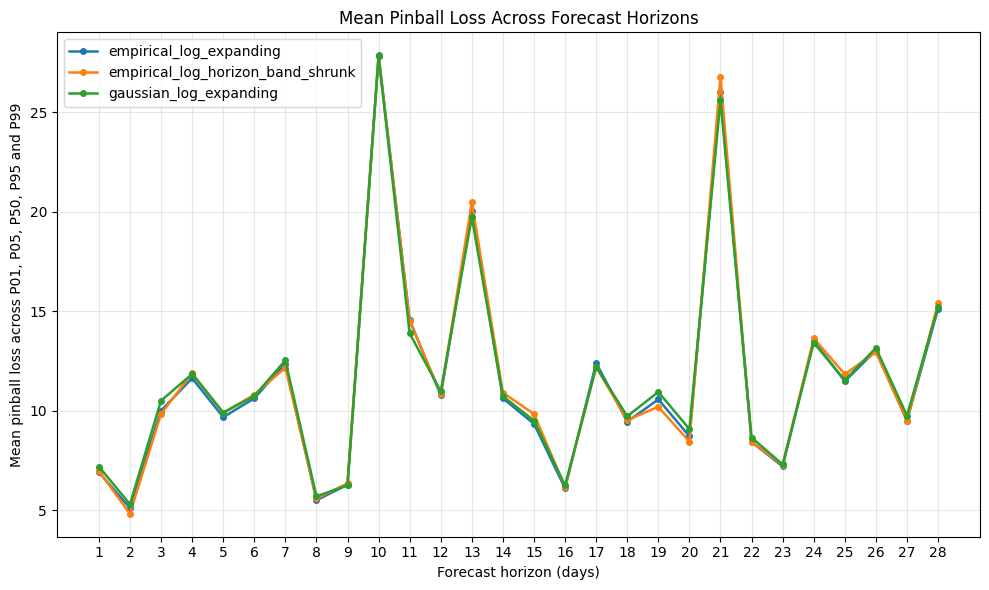

,check,observed,expected,status
0,horizon_quantile_metric_rows,420,420,PASS
1,horizon_method_summary_rows,84,84,PASS
2,horizon_band_quantile_rows,60,60,PASS
3,horizon_band_interval_rows,24,24,PASS
4,minimum_band_observations,105,105,PASS
5,horizon_pinball_figure_created,True,True,PASS



Individual horizons won on mean pinball loss:


,winning_method_id,horizons_won,winning_horizons
0,empirical_log_expanding,15,1 | 4 | 5 | 6 | 8 | 12 | 14 | 15 | 16 | 18 | 2...
1,empirical_log_horizon_band_shrunk,7,2 | 3 | 7 | 10 | 19 | 20 | 26
2,gaussian_log_expanding,6,9 | 11 | 13 | 17 | 21 | 24



Seven-day horizon-band winners:


,horizon_band,winning_method_id,mean_pinball_loss_five_quantiles,mean_absolute_calibration_error,p95_coverage,p99_coverage,pi90_coverage,pi98_coverage
0,days_01_07,empirical_log_expanding,9.4754,0.0250,0.9905,1.0000,0.9524,1.0000
1,days_08_14,gaussian_log_expanding,13.5839,0.0152,0.9619,0.9905,0.9333,0.9714
2,days_15_21,empirical_log_expanding,11.7990,0.0135,0.9714,0.9905,0.9333,0.9810
3,days_22_28,empirical_log_expanding,11.1861,0.0059,0.9524,0.9905,0.9238,0.9810



Complete horizon-band probabilistic summary:


,method_id,horizon_band,mean_pinball_loss_five_quantiles,mean_absolute_calibration_error,mean_upper_tail_pinball_loss,mean_upper_tail_absolute_calibration_error,p50_coverage,p95_coverage,p99_coverage,pi90_coverage,pi98_coverage,pi90_interval_score,pi98_interval_score
0,empirical_log_expanding,days_01_07,9.4754,0.0250,4.7761,0.0252,0.4476,0.9905,1.0000,0.9524,1.0000,291.6037,373.0969
1,empirical_log_horizon_band_shrunk,days_01_07,9.4863,0.0135,4.7311,0.0205,0.5143,0.9810,1.0000,0.9429,0.9905,291.7546,363.8856
2,gaussian_log_expanding,days_01_07,9.7186,0.0307,5.0028,0.0205,0.4381,0.9810,1.0000,0.9714,1.0000,303.3396,418.2990
3,empirical_log_expanding,days_08_14,13.6664,0.0152,9.6499,0.0062,0.4571,0.9619,0.9905,0.9143,0.9619,482.0305,"1,117.0328"
4,empirical_log_horizon_band_shrunk,days_08_14,13.7838,0.0133,9.8225,0.0062,0.4571,0.9619,0.9905,0.9143,0.9714,482.5849,"1,164.5185"
5,gaussian_log_expanding,days_08_14,13.5839,0.0152,9.5884,0.0062,0.4667,0.9619,0.9905,0.9333,0.9714,482.3479,"1,079.4307"
6,empirical_log_expanding,days_15_21,11.7990,0.0135,8.5223,0.0110,0.5333,0.9714,0.9905,0.9333,0.9810,375.9630,702.8677
7,empirical_log_horizon_band_shrunk,days_15_21,11.8836,0.0069,8.6528,0.0038,0.4952,0.9429,0.9905,0.9143,0.9810,377.0997,740.0789
8,gaussian_log_expanding,days_15_21,11.9015,0.0250,8.4788,0.0157,0.5429,0.9810,0.9905,0.9714,0.9905,383.5886,705.2454
9,empirical_log_expanding,days_22_28,11.1861,0.0059,6.1717,0.0014,0.4952,0.9524,0.9905,0.9238,0.9810,342.5896,402.2962


In [7]:

# ---------------------------------------------------------------------
# Add the frozen seven-day horizon bands to the long evaluation table
# ---------------------------------------------------------------------
quantile_evaluation_by_horizon = (
    quantile_evaluation_long.copy()
)

quantile_evaluation_by_horizon["horizon_band"] = pd.cut(
    quantile_evaluation_by_horizon["forecast_horizon"],
    bins=[0, 7, 14, 21, 28],
    labels=[
        "days_01_07",
        "days_08_14",
        "days_15_21",
        "days_22_28",
    ],
    include_lowest=True,
)


# ---------------------------------------------------------------------
# Quantile metrics by individual forecast horizon
# Coverage is retained for completeness but will not be interpreted
# strongly because each horizon contains only 15 observations.
# ---------------------------------------------------------------------
horizon_quantile_metrics = (
    quantile_evaluation_by_horizon
    .groupby(
        [
            "method_id",
            "forecast_horizon",
            "nominal_quantile",
            "quantile_label",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        observations=("actual", "size"),
        mean_pinball_loss=("pinball_loss", "mean"),
        empirical_coverage=("covered", "mean"),
    )
)

horizon_all_quantile_summary = (
    horizon_quantile_metrics
    .groupby(
        ["method_id", "forecast_horizon"],
        as_index=False,
    )
    .agg(
        mean_pinball_loss_five_quantiles=(
            "mean_pinball_loss",
            "mean",
        ),
    )
)

horizon_upper_tail_summary = (
    horizon_quantile_metrics.loc[
        horizon_quantile_metrics[
            "nominal_quantile"
        ].isin([0.95, 0.99])
    ]
    .groupby(
        ["method_id", "forecast_horizon"],
        as_index=False,
    )
    .agg(
        mean_upper_tail_pinball_loss=(
            "mean_pinball_loss",
            "mean",
        ),
    )
)

horizon_method_summary = (
    horizon_all_quantile_summary
    .merge(
        horizon_upper_tail_summary,
        on=["method_id", "forecast_horizon"],
        how="left",
        validate="one_to_one",
    )
)


# ---------------------------------------------------------------------
# Identify the method with the lowest five-quantile pinball loss at
# each individual horizon.
# ---------------------------------------------------------------------
horizon_winner_indices = (
    horizon_method_summary
    .groupby("forecast_horizon")[
        "mean_pinball_loss_five_quantiles"
    ]
    .idxmin()
)

horizon_winners = (
    horizon_method_summary
    .loc[horizon_winner_indices]
    .rename(
        columns={
            "method_id": "winning_method_id",
            "mean_pinball_loss_five_quantiles": (
                "winning_mean_pinball_loss"
            ),
        }
    )
    [
        [
            "forecast_horizon",
            "winning_method_id",
            "winning_mean_pinball_loss",
        ]
    ]
    .sort_values("forecast_horizon")
    .reset_index(drop=True)
)

horizon_winner_counts = (
    horizon_winners
    .groupby(
        "winning_method_id",
        as_index=False,
    )
    .agg(
        horizons_won=(
            "forecast_horizon",
            "size",
        ),
        winning_horizons=(
            "forecast_horizon",
            lambda values: " | ".join(
                str(int(value))
                for value in values
            ),
        ),
    )
    .sort_values(
        ["horizons_won", "winning_method_id"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Quantile metrics by seven-day horizon band
# ---------------------------------------------------------------------
horizon_band_quantile_metrics = (
    quantile_evaluation_by_horizon
    .groupby(
        [
            "method_id",
            "horizon_band",
            "nominal_quantile",
            "quantile_label",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        observations=("actual", "size"),
        mean_pinball_loss=("pinball_loss", "mean"),
        empirical_coverage=("covered", "mean"),
    )
)

horizon_band_quantile_metrics[
    "calibration_error"
] = (
    horizon_band_quantile_metrics[
        "empirical_coverage"
    ]
    - horizon_band_quantile_metrics[
        "nominal_quantile"
    ]
)

horizon_band_quantile_metrics[
    "absolute_calibration_error"
] = (
    horizon_band_quantile_metrics[
        "calibration_error"
    ].abs()
)


# ---------------------------------------------------------------------
# Interval metrics by seven-day horizon band
# ---------------------------------------------------------------------
horizon_band_interval_rows = []

for (
    method_id,
    horizon_band,
), band_data in probabilistic_predictions.groupby(
    ["method_id", "horizon_band"],
    observed=True,
):
    for specification in interval_specifications:
        actual = band_data["actual"].to_numpy(
            dtype=float
        )

        lower = band_data[
            specification["lower_column"]
        ].to_numpy(dtype=float)

        upper = band_data[
            specification["upper_column"]
        ].to_numpy(dtype=float)

        nominal_coverage = specification[
            "nominal_coverage"
        ]

        alpha = 1.0 - nominal_coverage

        covered = (
            (actual >= lower)
            & (actual <= upper)
        )

        interval_width = upper - lower

        interval_score = (
            interval_width
            + (2.0 / alpha)
            * (lower - actual)
            * (actual < lower)
            + (2.0 / alpha)
            * (actual - upper)
            * (actual > upper)
        )

        horizon_band_interval_rows.append(
            {
                "method_id": method_id,
                "horizon_band": str(horizon_band),
                "interval_name": specification[
                    "interval_name"
                ],
                "observations": len(band_data),
                "nominal_coverage": nominal_coverage,
                "empirical_coverage": float(
                    covered.mean()
                ),
                "calibration_error": float(
                    covered.mean()
                    - nominal_coverage
                ),
                "absolute_calibration_error": float(
                    abs(
                        covered.mean()
                        - nominal_coverage
                    )
                ),
                "mean_interval_width": float(
                    interval_width.mean()
                ),
                "mean_interval_score": float(
                    interval_score.mean()
                ),
            }
        )

horizon_band_interval_metrics = pd.DataFrame(
    horizon_band_interval_rows
)


# ---------------------------------------------------------------------
# Compact one-row-per-method-and-band summary
# ---------------------------------------------------------------------
band_pinball_summary = (
    horizon_band_quantile_metrics
    .groupby(
        ["method_id", "horizon_band"],
        as_index=False,
        observed=True,
    )
    .agg(
        mean_pinball_loss_five_quantiles=(
            "mean_pinball_loss",
            "mean",
        ),
        mean_absolute_calibration_error=(
            "absolute_calibration_error",
            "mean",
        ),
    )
)

band_upper_tail_summary = (
    horizon_band_quantile_metrics.loc[
        horizon_band_quantile_metrics[
            "nominal_quantile"
        ].isin([0.95, 0.99])
    ]
    .groupby(
        ["method_id", "horizon_band"],
        as_index=False,
        observed=True,
    )
    .agg(
        mean_upper_tail_pinball_loss=(
            "mean_pinball_loss",
            "mean",
        ),
        mean_upper_tail_absolute_calibration_error=(
            "absolute_calibration_error",
            "mean",
        ),
    )
)

band_quantile_coverage_wide = (
    horizon_band_quantile_metrics.loc[
        horizon_band_quantile_metrics[
            "quantile_label"
        ].isin(["P50", "P95", "P99"])
    ]
    .pivot(
        index=["method_id", "horizon_band"],
        columns="quantile_label",
        values="empirical_coverage",
    )
    .rename(
        columns=lambda column: (
            f"{column.lower()}_coverage"
        )
    )
    .reset_index()
)

band_interval_coverage_wide = (
    horizon_band_interval_metrics
    .pivot(
        index=["method_id", "horizon_band"],
        columns="interval_name",
        values="empirical_coverage",
    )
    .rename(
        columns=lambda column: (
            f"{column.lower()}_coverage"
        )
    )
    .reset_index()
)

band_interval_score_wide = (
    horizon_band_interval_metrics
    .pivot(
        index=["method_id", "horizon_band"],
        columns="interval_name",
        values="mean_interval_score",
    )
    .rename(
        columns=lambda column: (
            f"{column.lower()}_interval_score"
        )
    )
    .reset_index()
)

horizon_band_probabilistic_summary = (
    band_pinball_summary
    .merge(
        band_upper_tail_summary,
        on=["method_id", "horizon_band"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        band_quantile_coverage_wide,
        on=["method_id", "horizon_band"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        band_interval_coverage_wide,
        on=["method_id", "horizon_band"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        band_interval_score_wide,
        on=["method_id", "horizon_band"],
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        ["horizon_band", "method_id"]
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Identify the lowest-pinball method in each seven-day band
# ---------------------------------------------------------------------
band_winner_indices = (
    horizon_band_probabilistic_summary
    .groupby("horizon_band")[
        "mean_pinball_loss_five_quantiles"
    ]
    .idxmin()
)

horizon_band_winners = (
    horizon_band_probabilistic_summary
    .loc[
        band_winner_indices,
        [
            "horizon_band",
            "method_id",
            "mean_pinball_loss_five_quantiles",
            "mean_absolute_calibration_error",
            "p95_coverage",
            "p99_coverage",
            "pi90_coverage",
            "pi98_coverage",
        ],
    ]
    .rename(
        columns={
            "method_id": "winning_method_id",
        }
    )
    .sort_values("horizon_band")
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Figure: mean five-quantile pinball loss by forecast horizon
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

for method_id, method_data in (
    horizon_method_summary.groupby("method_id")
):
    method_data = method_data.sort_values(
        "forecast_horizon"
    )

    ax.plot(
        method_data["forecast_horizon"],
        method_data[
            "mean_pinball_loss_five_quantiles"
        ],
        marker="o",
        linewidth=1.8,
        markersize=4,
        label=method_id,
    )

ax.set_title(
    "Mean Pinball Loss Across Forecast Horizons"
)
ax.set_xlabel("Forecast horizon (days)")
ax.set_ylabel(
    "Mean pinball loss across P01, P05, P50, P95 and P99"
)
ax.set_xticks(range(1, 29))
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()

horizon_pinball_figure_path = (
    FIGURES_DIR
    / "07_mean_pinball_loss_by_forecast_horizon.png"
)

fig.savefig(
    horizon_pinball_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------------------
# Minimal structural audit
# ---------------------------------------------------------------------
horizon_stability_audit = pd.DataFrame(
    [
        {
            "check": "horizon_quantile_metric_rows",
            "observed": len(
                horizon_quantile_metrics
            ),
            "expected": 420,
        },
        {
            "check": "horizon_method_summary_rows",
            "observed": len(
                horizon_method_summary
            ),
            "expected": 84,
        },
        {
            "check": "horizon_band_quantile_rows",
            "observed": len(
                horizon_band_quantile_metrics
            ),
            "expected": 60,
        },
        {
            "check": "horizon_band_interval_rows",
            "observed": len(
                horizon_band_interval_metrics
            ),
            "expected": 24,
        },
        {
            "check": "minimum_band_observations",
            "observed": int(
                horizon_band_quantile_metrics[
                    "observations"
                ].min()
            ),
            "expected": 105,
        },
        {
            "check": "horizon_pinball_figure_created",
            "observed": (
                horizon_pinball_figure_path.exists()
            ),
            "expected": True,
        },
    ]
)

horizon_stability_audit["status"] = np.where(
    horizon_stability_audit[
        "observed"
    ].astype(str)
    == horizon_stability_audit[
        "expected"
    ].astype(str),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Save every output generated by this cell
# ---------------------------------------------------------------------
horizon_metrics_path = (
    DATA_PROCESSED_DIR
    / "07_horizon_quantile_metrics.csv"
)

horizon_summary_path = (
    DATA_PROCESSED_DIR
    / "07_horizon_probabilistic_method_summary.csv"
)

horizon_winners_path = (
    DATA_PROCESSED_DIR
    / "07_horizon_probabilistic_winners.csv"
)

horizon_winner_counts_path = (
    DATA_PROCESSED_DIR
    / "07_horizon_probabilistic_winner_counts.csv"
)

band_quantile_metrics_path = (
    DATA_PROCESSED_DIR
    / "07_horizon_band_quantile_metrics.csv"
)

band_interval_metrics_path = (
    DATA_PROCESSED_DIR
    / "07_horizon_band_interval_metrics.csv"
)

band_summary_path = (
    DATA_PROCESSED_DIR
    / "07_horizon_band_probabilistic_summary.csv"
)

band_winners_path = (
    DATA_PROCESSED_DIR
    / "07_horizon_band_probabilistic_winners.csv"
)

horizon_stability_audit_path = (
    DATA_PROCESSED_DIR
    / "07_horizon_stability_audit.csv"
)

horizon_quantile_metrics.to_csv(
    horizon_metrics_path,
    index=False,
)

horizon_method_summary.to_csv(
    horizon_summary_path,
    index=False,
)

horizon_winners.to_csv(
    horizon_winners_path,
    index=False,
)

horizon_winner_counts.to_csv(
    horizon_winner_counts_path,
    index=False,
)

horizon_band_quantile_metrics.to_csv(
    band_quantile_metrics_path,
    index=False,
)

horizon_band_interval_metrics.to_csv(
    band_interval_metrics_path,
    index=False,
)

horizon_band_probabilistic_summary.to_csv(
    band_summary_path,
    index=False,
)

horizon_band_winners.to_csv(
    band_winners_path,
    index=False,
)

horizon_stability_audit.to_csv(
    horizon_stability_audit_path,
    index=False,
)


required_paths = [
    horizon_metrics_path,
    horizon_summary_path,
    horizon_winners_path,
    horizon_winner_counts_path,
    band_quantile_metrics_path,
    band_interval_metrics_path,
    band_summary_path,
    band_winners_path,
    horizon_stability_audit_path,
    horizon_pinball_figure_path,
]

assert all(path.exists() for path in required_paths)

assert horizon_stability_audit[
    "status"
].eq("PASS").all(), (
    "The horizon-stability evaluation failed its audit."
)


display(horizon_stability_audit)

print("\nIndividual horizons won on mean pinball loss:")
display(horizon_winner_counts)

print("\nSeven-day horizon-band winners:")
display(horizon_band_winners)

print("\nComplete horizon-band probabilistic summary:")
display(horizon_band_probabilistic_summary)

## 6. Probabilistic performance under operational conditions

Operational-condition diagnostics are evaluated only over the 420 prequential probabilistic predictions.

Conditions can overlap. For example, a target date may simultaneously belong to a weekend, holiday or promotion period. These results are therefore diagnostic views and not mutually exclusive evaluation subsets.

Because tail calibration requires substantially more support than point-error evaluation, condition evidence is classified as:

- **Selection support:** at least 50 active evaluation observations.
- **Descriptive only:** between 10 and 49 active observations.
- **Insufficient support:** fewer than 10 active observations.
- **Conditional scenario only:** merchant settlements, which remain outside universal model selection regardless of their count.

P95 and P99 coverage are reported for all groups, but small-support groups will not determine the probabilistic-method selection.

The primary business-oriented comparison uses the mean pinball loss across P95 and P99 because liquidity reserve decisions depend principally on the upper predictive tail.

In [8]:
# ---------------------------------------------------------------------
# Fixed support thresholds for condition-level probabilistic evidence
# ---------------------------------------------------------------------
MIN_SELECTION_SUPPORT = 50
MIN_DESCRIPTIVE_SUPPORT = 10

condition_columns = [
    "is_weekend",
    "is_holiday",
    "is_payday_window",
    "is_month_end",
    "promotion_intensity",
    "merchant_settlement_intensity",
]

condition_columns = [
    column
    for column in condition_columns
    if column in probabilistic_predictions.columns
]


# ---------------------------------------------------------------------
# Use one prediction row per target-date key to measure condition support
# without counting the same observation once for every method.
# ---------------------------------------------------------------------
evaluation_condition_base = (
    probabilistic_predictions.loc[
        probabilistic_predictions["method_id"]
        == probabilistic_predictions["method_id"].iloc[0]
    ]
    .copy()
)

evaluation_condition_base = (
    evaluation_condition_base
    .drop_duplicates(
        subset=[
            "fold_id",
            "forecast_horizon",
            "target_date",
        ]
    )
)


condition_registry_rows = []

for condition in condition_columns:
    active_flag = condition_is_active(
        evaluation_condition_base[condition]
    )

    active_rows = int(active_flag.sum())

    if condition == "merchant_settlement_intensity":
        evidence_status = "conditional_scenario_only"
    elif active_rows >= MIN_SELECTION_SUPPORT:
        evidence_status = "selection_support"
    elif active_rows >= MIN_DESCRIPTIVE_SUPPORT:
        evidence_status = "descriptive_only"
    else:
        evidence_status = "insufficient_support"

    condition_registry_rows.append(
        {
            "condition": condition,
            "evaluation_rows": len(
                evaluation_condition_base
            ),
            "active_evaluation_rows": active_rows,
            "active_share_percent": float(
                100.0 * active_flag.mean()
            ),
            "minimum_selection_support": (
                MIN_SELECTION_SUPPORT
            ),
            "evidence_status": evidence_status,
        }
    )


probabilistic_condition_registry = pd.DataFrame(
    condition_registry_rows
)


# ---------------------------------------------------------------------
# Helper for pinball loss
# ---------------------------------------------------------------------
def calculate_pinball_loss(
    actual,
    predicted_quantile,
    nominal_quantile,
):
    """Return row-level pinball loss."""
    residual = actual - predicted_quantile

    return np.where(
        residual >= 0,
        nominal_quantile * residual,
        (1.0 - nominal_quantile) * (-residual),
    )


# ---------------------------------------------------------------------
# Evaluate active observations for every method and condition
# ---------------------------------------------------------------------
condition_metric_rows = []

for method_id, method_data in (
    probabilistic_predictions.groupby("method_id")
):
    for registry_row in (
        probabilistic_condition_registry.itertuples(
            index=False
        )
    ):
        condition = registry_row.condition

        active_flag = condition_is_active(
            method_data[condition]
        )

        active_data = method_data.loc[
            active_flag
        ].copy()

        if active_data.empty:
            continue

        actual = active_data["actual"].to_numpy(
            dtype=float
        )

        p50 = active_data["p50"].to_numpy(
            dtype=float
        )

        p95 = active_data["p95"].to_numpy(
            dtype=float
        )

        p99 = active_data["p99"].to_numpy(
            dtype=float
        )

        p05 = active_data["p05"].to_numpy(
            dtype=float
        )

        p01 = active_data["p01"].to_numpy(
            dtype=float
        )

        p50_pinball = calculate_pinball_loss(
            actual,
            p50,
            0.50,
        )

        p95_pinball = calculate_pinball_loss(
            actual,
            p95,
            0.95,
        )

        p99_pinball = calculate_pinball_loss(
            actual,
            p99,
            0.99,
        )

        pi90_covered = (
            (actual >= p05)
            & (actual <= p95)
        )

        pi98_covered = (
            (actual >= p01)
            & (actual <= p99)
        )

        pi90_width = p95 - p05
        pi98_width = p99 - p01

        pi90_alpha = 0.10
        pi98_alpha = 0.02

        pi90_interval_score = (
            pi90_width
            + (2.0 / pi90_alpha)
            * (p05 - actual)
            * (actual < p05)
            + (2.0 / pi90_alpha)
            * (actual - p95)
            * (actual > p95)
        )

        pi98_interval_score = (
            pi98_width
            + (2.0 / pi98_alpha)
            * (p01 - actual)
            * (actual < p01)
            + (2.0 / pi98_alpha)
            * (actual - p99)
            * (actual > p99)
        )

        p50_coverage = float(
            np.mean(actual <= p50)
        )

        p95_coverage = float(
            np.mean(actual <= p95)
        )

        p99_coverage = float(
            np.mean(actual <= p99)
        )

        condition_metric_rows.append(
            {
                "method_id": method_id,
                "condition": condition,
                "evidence_status": (
                    registry_row.evidence_status
                ),
                "observations": len(active_data),
                "mean_actual": float(
                    np.mean(actual)
                ),
                "p50_pinball_loss": float(
                    np.mean(p50_pinball)
                ),
                "p95_pinball_loss": float(
                    np.mean(p95_pinball)
                ),
                "p99_pinball_loss": float(
                    np.mean(p99_pinball)
                ),
                "mean_upper_tail_pinball_loss": float(
                    np.mean(
                        [
                            np.mean(p95_pinball),
                            np.mean(p99_pinball),
                        ]
                    )
                ),
                "p50_coverage": p50_coverage,
                "p95_coverage": p95_coverage,
                "p99_coverage": p99_coverage,
                "p50_absolute_calibration_error": float(
                    abs(p50_coverage - 0.50)
                ),
                "p95_absolute_calibration_error": float(
                    abs(p95_coverage - 0.95)
                ),
                "p99_absolute_calibration_error": float(
                    abs(p99_coverage - 0.99)
                ),
                "mean_upper_tail_absolute_calibration_error": float(
                    np.mean(
                        [
                            abs(p95_coverage - 0.95),
                            abs(p99_coverage - 0.99),
                        ]
                    )
                ),
                "pi90_coverage": float(
                    np.mean(pi90_covered)
                ),
                "pi98_coverage": float(
                    np.mean(pi98_covered)
                ),
                "pi90_mean_width": float(
                    np.mean(pi90_width)
                ),
                "pi98_mean_width": float(
                    np.mean(pi98_width)
                ),
                "pi90_interval_score": float(
                    np.mean(pi90_interval_score)
                ),
                "pi98_interval_score": float(
                    np.mean(pi98_interval_score)
                ),
            }
        )


probabilistic_condition_metrics = pd.DataFrame(
    condition_metric_rows
)

probabilistic_condition_metrics = (
    probabilistic_condition_metrics
    .sort_values(
        ["condition", "method_id"]
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Compare only the two eligible empirical candidates for condition-level
# selection evidence. The Gaussian method remains visible as a benchmark.
# ---------------------------------------------------------------------
eligible_method_ids = (
    probabilistic_method_registry.loc[
        probabilistic_method_registry[
            "selection_role"
        ] == "eligible_candidate",
        "method_id",
    ]
    .tolist()
)

eligible_condition_metrics = (
    probabilistic_condition_metrics.loc[
        probabilistic_condition_metrics[
            "method_id"
        ].isin(eligible_method_ids)
    ]
    .copy()
)

eligible_condition_winner_indices = (
    eligible_condition_metrics
    .groupby("condition")[
        "mean_upper_tail_pinball_loss"
    ]
    .idxmin()
)

eligible_condition_winners = (
    eligible_condition_metrics
    .loc[
        eligible_condition_winner_indices,
        [
            "condition",
            "evidence_status",
            "observations",
            "method_id",
            "mean_upper_tail_pinball_loss",
            "mean_upper_tail_absolute_calibration_error",
            "p95_coverage",
            "p99_coverage",
            "pi90_coverage",
            "pi98_coverage",
        ],
    ]
    .rename(
        columns={
            "method_id": "winning_eligible_method_id"
        }
    )
    .sort_values("condition")
    .reset_index(drop=True)
)


eligible_condition_winner_counts = (
    eligible_condition_winners.loc[
        eligible_condition_winners[
            "evidence_status"
        ] == "selection_support"
    ]
    .groupby(
        "winning_eligible_method_id",
        as_index=False,
    )
    .agg(
        supported_conditions_won=(
            "condition",
            "size",
        ),
        supported_conditions=(
            "condition",
            lambda values: " | ".join(values),
        ),
    )
    .sort_values(
        [
            "supported_conditions_won",
            "winning_eligible_method_id",
        ],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Structural audit
# ---------------------------------------------------------------------
condition_numeric_columns = [
    "p50_pinball_loss",
    "p95_pinball_loss",
    "p99_pinball_loss",
    "mean_upper_tail_pinball_loss",
    "p50_coverage",
    "p95_coverage",
    "p99_coverage",
    "pi90_coverage",
    "pi98_coverage",
    "pi90_mean_width",
    "pi98_mean_width",
]

nonfinite_condition_metrics = int(
    (
        ~np.isfinite(
            probabilistic_condition_metrics[
                condition_numeric_columns
            ].to_numpy(dtype=float)
        )
    ).sum()
)

condition_coverage_out_of_bounds = int(
    (
        (
            probabilistic_condition_metrics[
                [
                    "p50_coverage",
                    "p95_coverage",
                    "p99_coverage",
                    "pi90_coverage",
                    "pi98_coverage",
                ]
            ] < 0
        )
        | (
            probabilistic_condition_metrics[
                [
                    "p50_coverage",
                    "p95_coverage",
                    "p99_coverage",
                    "pi90_coverage",
                    "pi98_coverage",
                ]
            ] > 1
        )
    )
    .to_numpy()
    .sum()
)

condition_evaluation_audit = pd.DataFrame(
    [
        {
            "check": "registered_conditions",
            "observed": len(
                probabilistic_condition_registry
            ),
            "expected": len(condition_columns),
        },
        {
            "check": "condition_metric_rows",
            "observed": len(
                probabilistic_condition_metrics
            ),
            "expected": (
                len(condition_columns)
                * probabilistic_predictions[
                    "method_id"
                ].nunique()
            ),
        },
        {
            "check": "eligible_condition_winner_rows",
            "observed": len(
                eligible_condition_winners
            ),
            "expected": len(condition_columns),
        },
        {
            "check": "duplicate_method_condition_rows",
            "observed": int(
                probabilistic_condition_metrics
                .duplicated(
                    subset=[
                        "method_id",
                        "condition",
                    ]
                )
                .sum()
            ),
            "expected": 0,
        },
        {
            "check": "nonfinite_condition_metrics",
            "observed": nonfinite_condition_metrics,
            "expected": 0,
        },
        {
            "check": "condition_coverage_out_of_bounds",
            "observed": (
                condition_coverage_out_of_bounds
            ),
            "expected": 0,
        },
        {
            "check": "settlement_conditional_only",
            "observed": (
                probabilistic_condition_registry.loc[
                    probabilistic_condition_registry[
                        "condition"
                    ]
                    == "merchant_settlement_intensity",
                    "evidence_status",
                ]
                .iloc[0]
            ),
            "expected": "conditional_scenario_only",
        },
    ]
)

condition_evaluation_audit["status"] = np.where(
    condition_evaluation_audit[
        "observed"
    ].astype(str)
    == condition_evaluation_audit[
        "expected"
    ].astype(str),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Save all outputs generated by this cell
# ---------------------------------------------------------------------
condition_registry_path = (
    DATA_PROCESSED_DIR
    / "07_probabilistic_condition_registry.csv"
)

condition_metrics_path = (
    DATA_PROCESSED_DIR
    / "07_probabilistic_condition_metrics.csv"
)

condition_winners_path = (
    DATA_PROCESSED_DIR
    / "07_eligible_probabilistic_condition_winners.csv"
)

condition_winner_counts_path = (
    DATA_PROCESSED_DIR
    / "07_eligible_probabilistic_condition_winner_counts.csv"
)

condition_audit_path = (
    DATA_PROCESSED_DIR
    / "07_probabilistic_condition_evaluation_audit.csv"
)

probabilistic_condition_registry.to_csv(
    condition_registry_path,
    index=False,
)

probabilistic_condition_metrics.to_csv(
    condition_metrics_path,
    index=False,
)

eligible_condition_winners.to_csv(
    condition_winners_path,
    index=False,
)

eligible_condition_winner_counts.to_csv(
    condition_winner_counts_path,
    index=False,
)

condition_evaluation_audit.to_csv(
    condition_audit_path,
    index=False,
)


required_condition_paths = [
    condition_registry_path,
    condition_metrics_path,
    condition_winners_path,
    condition_winner_counts_path,
    condition_audit_path,
]

assert all(
    path.exists()
    for path in required_condition_paths
)

assert condition_evaluation_audit[
    "status"
].eq("PASS").all(), (
    "The operational-condition evaluation failed its audit."
)


display(condition_evaluation_audit)

print("\nCondition evidence registry:")
display(probabilistic_condition_registry)

print("\nEligible-method winner by condition:")
display(eligible_condition_winners)

print("\nSelection-supported condition wins:")
display(eligible_condition_winner_counts)

,check,observed,expected,status
0,registered_conditions,6,6,PASS
1,condition_metric_rows,18,18,PASS
2,eligible_condition_winner_rows,6,6,PASS
3,duplicate_method_condition_rows,0,0,PASS
4,nonfinite_condition_metrics,0,0,PASS
5,condition_coverage_out_of_bounds,0,0,PASS
6,settlement_conditional_only,conditional_scenario_only,conditional_scenario_only,PASS



Condition evidence registry:


,condition,evaluation_rows,active_evaluation_rows,active_share_percent,minimum_selection_support,evidence_status
0,is_weekend,420,120,28.5714,50,selection_support
1,is_holiday,420,23,5.4762,50,descriptive_only
2,is_payday_window,420,81,19.2857,50,selection_support
3,is_month_end,420,14,3.3333,50,descriptive_only
4,promotion_intensity,420,13,3.0952,50,descriptive_only
5,merchant_settlement_intensity,420,2,0.4762,50,conditional_scenario_only



Eligible-method winner by condition:


,condition,evidence_status,observations,winning_eligible_method_id,mean_upper_tail_pinball_loss,mean_upper_tail_absolute_calibration_error,p95_coverage,p99_coverage,pi90_coverage,pi98_coverage
0,is_holiday,descriptive_only,23,empirical_log_horizon_band_shrunk,3.8901,0.0083,0.9565,1.0000,0.9565,1.0000
1,is_month_end,descriptive_only,14,empirical_log_expanding,6.3291,0.0157,0.9286,1.0000,0.8571,0.9286
2,is_payday_window,selection_support,81,empirical_log_horizon_band_shrunk,8.0571,0.0070,0.9383,0.9877,0.9012,0.9753
3,is_weekend,selection_support,120,empirical_log_expanding,3.4993,0.0217,0.9833,1.0000,0.9667,0.9917
4,merchant_settlement_intensity,conditional_scenario_only,2,empirical_log_expanding,401.3744,0.9700,0.0000,0.0000,0.0000,0.0000
5,promotion_intensity,descriptive_only,13,empirical_log_expanding,5.8374,0.0300,1.0000,1.0000,1.0000,1.0000



Selection-supported condition wins:


,winning_eligible_method_id,supported_conditions_won,supported_conditions
0,empirical_log_expanding,1,is_weekend
1,empirical_log_horizon_band_shrunk,1,is_payday_window


## 7. Daily probabilistic-method selection

The selected method for daily marginal predictive quantiles is:

```text
empirical_log_expanding

In [9]:

# ---------------------------------------------------------------------
# Compare only methods eligible under the non-Gaussian-tail guardrail
# ---------------------------------------------------------------------
eligible_method_ids = (
    probabilistic_method_registry.loc[
        probabilistic_method_registry["selection_role"]
        == "eligible_candidate",
        "method_id",
    ]
    .tolist()
)


# ---------------------------------------------------------------------
# Individual-horizon winners among eligible methods only
# ---------------------------------------------------------------------
eligible_horizon_metrics = (
    horizon_method_summary.loc[
        horizon_method_summary["method_id"].isin(
            eligible_method_ids
        )
    ]
    .copy()
)

eligible_horizon_winner_indices = (
    eligible_horizon_metrics
    .groupby("forecast_horizon")[
        "mean_pinball_loss_five_quantiles"
    ]
    .idxmin()
)

eligible_horizon_winners = (
    eligible_horizon_metrics
    .loc[
        eligible_horizon_winner_indices,
        [
            "forecast_horizon",
            "method_id",
            "mean_pinball_loss_five_quantiles",
        ],
    ]
    .rename(
        columns={
            "method_id": "winning_method_id",
        }
    )
    .sort_values("forecast_horizon")
    .reset_index(drop=True)
)

eligible_horizon_winner_counts = (
    eligible_horizon_winners
    .groupby(
        "winning_method_id",
        as_index=False,
    )
    .agg(
        eligible_horizons_won=(
            "forecast_horizon",
            "size",
        ),
        winning_horizons=(
            "forecast_horizon",
            lambda values: " | ".join(
                str(int(value))
                for value in values
            ),
        ),
    )
    .rename(
        columns={
            "winning_method_id": "method_id",
        }
    )
)


# ---------------------------------------------------------------------
# Seven-day-band winners among eligible methods only
# ---------------------------------------------------------------------
eligible_band_metrics = (
    horizon_band_probabilistic_summary.loc[
        horizon_band_probabilistic_summary[
            "method_id"
        ].isin(eligible_method_ids)
    ]
    .copy()
)

eligible_band_winner_indices = (
    eligible_band_metrics
    .groupby("horizon_band")[
        "mean_pinball_loss_five_quantiles"
    ]
    .idxmin()
)

eligible_horizon_band_winners = (
    eligible_band_metrics
    .loc[
        eligible_band_winner_indices,
        [
            "horizon_band",
            "method_id",
            "mean_pinball_loss_five_quantiles",
            "mean_absolute_calibration_error",
            "p95_coverage",
            "p99_coverage",
            "pi90_coverage",
            "pi98_coverage",
        ],
    ]
    .rename(
        columns={
            "method_id": "winning_method_id",
        }
    )
    .sort_values("horizon_band")
    .reset_index(drop=True)
)

eligible_band_winner_counts = (
    eligible_horizon_band_winners
    .groupby(
        "winning_method_id",
        as_index=False,
    )
    .agg(
        eligible_horizon_bands_won=(
            "horizon_band",
            "size",
        ),
        winning_horizon_bands=(
            "horizon_band",
            lambda values: " | ".join(
                str(value)
                for value in values
            ),
        ),
    )
    .rename(
        columns={
            "winning_method_id": "method_id",
        }
    )
)


# ---------------------------------------------------------------------
# Supported operational-condition wins
# ---------------------------------------------------------------------
supported_condition_win_counts = (
    eligible_condition_winner_counts
    .rename(
        columns={
            "winning_eligible_method_id": "method_id",
            "supported_conditions_won": (
                "selection_supported_conditions_won"
            ),
            "supported_conditions": (
                "winning_supported_conditions"
            ),
        }
    )
)


# ---------------------------------------------------------------------
# One-row-per-eligible-method selection evidence
# ---------------------------------------------------------------------
registry_selection_columns = [
    "method_id",
    "distribution_assumption",
    "horizon_adaptation",
    "selection_role",
    "non_gaussian_tail_protection",
]

probabilistic_method_selection_evidence = (
    probabilistic_method_summary.loc[
        probabilistic_method_summary[
            "method_id"
        ].isin(eligible_method_ids)
    ]
    .merge(
        probabilistic_method_registry[
            registry_selection_columns
        ],
        on="method_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        eligible_horizon_winner_counts,
        on="method_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        eligible_band_winner_counts,
        on="method_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        supported_condition_win_counts,
        on="method_id",
        how="left",
        validate="one_to_one",
    )
)

count_columns = [
    "eligible_horizons_won",
    "eligible_horizon_bands_won",
    "selection_supported_conditions_won",
]

probabilistic_method_selection_evidence[
    count_columns
] = (
    probabilistic_method_selection_evidence[
        count_columns
    ]
    .fillna(0)
    .astype(int)
)

text_columns = [
    "winning_horizons",
    "winning_horizon_bands",
    "winning_supported_conditions",
]

probabilistic_method_selection_evidence[
    text_columns
] = (
    probabilistic_method_selection_evidence[
        text_columns
    ]
    .fillna("")
)


# ---------------------------------------------------------------------
# Explicit decision hierarchy:
# 1. eligibility under the residual-tail guardrail;
# 2. global mean pinball loss;
# 3. interval scores and horizon consistency as supporting evidence.
# ---------------------------------------------------------------------
probabilistic_method_selection_evidence[
    "global_pinball_rank"
] = (
    probabilistic_method_selection_evidence[
        "mean_pinball_loss_five_quantiles"
    ]
    .rank(method="min", ascending=True)
    .astype(int)
)

probabilistic_method_selection_evidence[
    "pi90_interval_score_rank"
] = (
    probabilistic_method_selection_evidence[
        "pi90_interval_score"
    ]
    .rank(method="min", ascending=True)
    .astype(int)
)

probabilistic_method_selection_evidence[
    "pi98_interval_score_rank"
] = (
    probabilistic_method_selection_evidence[
        "pi98_interval_score"
    ]
    .rank(method="min", ascending=True)
    .astype(int)
)

probabilistic_method_selection_evidence = (
    probabilistic_method_selection_evidence
    .sort_values(
        [
            "global_pinball_rank",
            "pi90_interval_score_rank",
            "pi98_interval_score_rank",
        ]
    )
    .reset_index(drop=True)
)


SELECTED_PROBABILISTIC_METHOD = (
    probabilistic_method_selection_evidence
    .iloc[0]["method_id"]
)

EXPECTED_SELECTED_PROBABILISTIC_METHOD = (
    "empirical_log_expanding"
)

assert (
    SELECTED_PROBABILISTIC_METHOD
    == EXPECTED_SELECTED_PROBABILISTIC_METHOD
)


# ---------------------------------------------------------------------
# Freeze the selected prequential daily quantiles
# ---------------------------------------------------------------------
selected_probabilistic_predictions = (
    probabilistic_predictions.loc[
        probabilistic_predictions["method_id"]
        == SELECTED_PROBABILISTIC_METHOD
    ]
    .copy()
    .sort_values(
        ["fold_sequence", "forecast_horizon"]
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Formal method decision
# ---------------------------------------------------------------------
selected_evidence_row = (
    probabilistic_method_selection_evidence.loc[
        probabilistic_method_selection_evidence[
            "method_id"
        ] == SELECTED_PROBABILISTIC_METHOD
    ]
    .iloc[0]
)

probabilistic_method_decision = pd.DataFrame(
    [
        {
            "decision_scope": (
                "daily_marginal_predictive_quantiles"
            ),
            "selected_method_id": (
                SELECTED_PROBABILISTIC_METHOD
            ),
            "decision_status": (
                "SELECTED_DAILY_PROBABILISTIC_METHOD"
            ),
            "error_representation": "log_error",
            "distribution_assumption": "empirical",
            "calibration_protocol": (
                "expanding_prior_oos_folds"
            ),
            "evaluation_rows": len(
                selected_probabilistic_predictions
            ),
            "evaluation_folds": (
                selected_probabilistic_predictions[
                    "fold_id"
                ].nunique()
            ),
            "mean_pinball_loss_five_quantiles": float(
                selected_evidence_row[
                    "mean_pinball_loss_five_quantiles"
                ]
            ),
            "mean_upper_tail_pinball_loss": float(
                selected_evidence_row[
                    "mean_upper_tail_pinball_loss"
                ]
            ),
            "p95_coverage": float(
                selected_evidence_row[
                    "p95_coverage"
                ]
            ),
            "p99_coverage": float(
                selected_evidence_row[
                    "p99_coverage"
                ]
            ),
            "pi90_coverage": float(
                selected_evidence_row[
                    "pi90_coverage"
                ]
            ),
            "pi98_coverage": float(
                selected_evidence_row[
                    "pi98_coverage"
                ]
            ),
            "eligible_horizons_won": int(
                selected_evidence_row[
                    "eligible_horizons_won"
                ]
            ),
            "eligible_horizon_bands_won": int(
                selected_evidence_row[
                    "eligible_horizon_bands_won"
                ]
            ),
            "supported_conditions_won": int(
                selected_evidence_row[
                    "selection_supported_conditions_won"
                ]
            ),
            "gaussian_method_status": (
                "BENCHMARK_ONLY"
            ),
            "horizon_band_method_status": (
                "RETAINED_AS_CHALLENGER"
            ),
            "joint_five_day_path_method": (
                "PENDING_SEPARATE_SELECTION"
            ),
            "selection_reason": (
                "Lowest global mean pinball loss, lowest "
                "PI90 and PI98 interval scores, and all four "
                "eligible seven-day horizon bands won."
            ),
        }
    ]
)


# ---------------------------------------------------------------------
# Compact decision audit
# ---------------------------------------------------------------------
selected_registry_row = (
    probabilistic_method_registry.loc[
        probabilistic_method_registry["method_id"]
        == SELECTED_PROBABILISTIC_METHOD
    ]
    .iloc[0]
)

selected_horizon_wins = int(
    selected_evidence_row["eligible_horizons_won"]
)

maximum_other_horizon_wins = int(
    probabilistic_method_selection_evidence.loc[
        probabilistic_method_selection_evidence[
            "method_id"
        ] != SELECTED_PROBABILISTIC_METHOD,
        "eligible_horizons_won",
    ].max()
)

probabilistic_method_selection_audit = pd.DataFrame(
    [
        {
            "check": "eligible_methods_compared",
            "observed": len(
                probabilistic_method_selection_evidence
            ),
            "expected": 2,
        },
        {
            "check": "one_method_selected",
            "observed": len(
                probabilistic_method_decision
            ),
            "expected": 1,
        },
        {
            "check": "selected_method_matches_decision",
            "observed": SELECTED_PROBABILISTIC_METHOD,
            "expected": (
                EXPECTED_SELECTED_PROBABILISTIC_METHOD
            ),
        },
        {
            "check": "selected_method_tail_protection",
            "observed": bool(
                selected_registry_row[
                    "non_gaussian_tail_protection"
                ]
            ),
            "expected": True,
        },
        {
            "check": "selected_prediction_rows",
            "observed": len(
                selected_probabilistic_predictions
            ),
            "expected": (
                EXPECTED_PROBABILISTIC_EVALUATION_ROWS
            ),
        },
        {
            "check": "selected_evaluation_folds",
            "observed": (
                selected_probabilistic_predictions[
                    "fold_id"
                ].nunique()
            ),
            "expected": (
                EXPECTED_PROBABILISTIC_EVALUATION_FOLDS
            ),
        },
        {
            "check": "eligible_horizon_bands_won",
            "observed": int(
                selected_evidence_row[
                    "eligible_horizon_bands_won"
                ]
            ),
            "expected": 4,
        },
        {
            "check": "selected_wins_more_horizons",
            "observed": (
                selected_horizon_wins
                > maximum_other_horizon_wins
            ),
            "expected": True,
        },
        {
            "check": "point_model_remains_frozen",
            "observed": (
                selected_probabilistic_predictions[
                    "model_name"
                ].nunique() == 1
                and selected_probabilistic_predictions[
                    "model_name"
                ].iloc[0] == FINAL_POINT_MODEL
            ),
            "expected": True,
        },
        {
            "check": "joint_path_method_not_assumed",
            "observed": (
                probabilistic_method_decision[
                    "joint_five_day_path_method"
                ].iloc[0]
            ),
            "expected": (
                "PENDING_SEPARATE_SELECTION"
            ),
        },
    ]
)

probabilistic_method_selection_audit[
    "status"
] = np.where(
    probabilistic_method_selection_audit[
        "observed"
    ].astype(str)
    == probabilistic_method_selection_audit[
        "expected"
    ].astype(str),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Save all decision artifacts
# ---------------------------------------------------------------------
selection_evidence_path = (
    DATA_PROCESSED_DIR
    / "07_probabilistic_method_selection_evidence.csv"
)

eligible_horizon_winners_path = (
    DATA_PROCESSED_DIR
    / "07_eligible_probabilistic_horizon_winners.csv"
)

eligible_band_winners_path = (
    DATA_PROCESSED_DIR
    / "07_eligible_probabilistic_horizon_band_winners.csv"
)

selected_predictions_path = (
    DATA_PROCESSED_DIR
    / "07_selected_prequential_probabilistic_predictions.csv"
)

method_decision_path = (
    DATA_PROCESSED_DIR
    / "07_probabilistic_method_decision.csv"
)

method_selection_audit_path = (
    DATA_PROCESSED_DIR
    / "07_probabilistic_method_selection_audit.csv"
)

probabilistic_method_selection_evidence.to_csv(
    selection_evidence_path,
    index=False,
)

eligible_horizon_winners.to_csv(
    eligible_horizon_winners_path,
    index=False,
)

eligible_horizon_band_winners.to_csv(
    eligible_band_winners_path,
    index=False,
)

selected_probabilistic_predictions.to_csv(
    selected_predictions_path,
    index=False,
)

probabilistic_method_decision.to_csv(
    method_decision_path,
    index=False,
)

probabilistic_method_selection_audit.to_csv(
    method_selection_audit_path,
    index=False,
)


required_selection_paths = [
    selection_evidence_path,
    eligible_horizon_winners_path,
    eligible_band_winners_path,
    selected_predictions_path,
    method_decision_path,
    method_selection_audit_path,
]

assert all(
    path.exists()
    for path in required_selection_paths
)

assert probabilistic_method_selection_audit[
    "status"
].eq("PASS").all(), (
    "The probabilistic-method selection failed its audit."
)


display(probabilistic_method_selection_audit)

print("\nEligible-method selection evidence:")
display(
    probabilistic_method_selection_evidence[
        [
            "method_id",
            "mean_pinball_loss_five_quantiles",
            "mean_absolute_calibration_error",
            "mean_upper_tail_pinball_loss",
            "p95_coverage",
            "p99_coverage",
            "pi90_interval_score",
            "pi98_interval_score",
            "eligible_horizons_won",
            "eligible_horizon_bands_won",
            "selection_supported_conditions_won",
            "global_pinball_rank",
        ]
    ]
)

print("\nFrozen probabilistic-method decision:")
display(probabilistic_method_decision)

,check,observed,expected,status
0,eligible_methods_compared,2,2,PASS
1,one_method_selected,1,1,PASS
2,selected_method_matches_decision,empirical_log_expanding,empirical_log_expanding,PASS
3,selected_method_tail_protection,True,True,PASS
4,selected_prediction_rows,420,420,PASS
5,selected_evaluation_folds,15,15,PASS
6,eligible_horizon_bands_won,4,4,PASS
7,selected_wins_more_horizons,True,True,PASS
8,point_model_remains_frozen,True,True,PASS
9,joint_path_method_not_assumed,PENDING_SEPARATE_SELECTION,PENDING_SEPARATE_SELECTION,PASS



Eligible-method selection evidence:


,method_id,mean_pinball_loss_five_quantiles,mean_absolute_calibration_error,mean_upper_tail_pinball_loss,p95_coverage,p99_coverage,pi90_interval_score,pi98_interval_score,eligible_horizons_won,eligible_horizon_bands_won,selection_supported_conditions_won,global_pinball_rank
0,empirical_log_expanding,11.5317,0.0105,7.2800,0.9690,0.9929,373.0467,648.8234,19,4,1,1
1,empirical_log_horizon_band_shrunk,11.6119,0.0067,7.3595,0.9571,0.9929,373.9359,670.1990,9,0,1,2



Frozen probabilistic-method decision:


,decision_scope,selected_method_id,decision_status,error_representation,distribution_assumption,calibration_protocol,evaluation_rows,evaluation_folds,mean_pinball_loss_five_quantiles,mean_upper_tail_pinball_loss,p95_coverage,p99_coverage,pi90_coverage,pi98_coverage,eligible_horizons_won,eligible_horizon_bands_won,supported_conditions_won,gaussian_method_status,horizon_band_method_status,joint_five_day_path_method,selection_reason
0,daily_marginal_predictive_quantiles,empirical_log_expanding,SELECTED_DAILY_PROBABILISTIC_METHOD,log_error,empirical,expanding_prior_oos_folds,420,15,11.5317,7.2800,0.9690,0.9929,0.9310,0.9810,19,4,1,BENCHMARK_ONLY,RETAINED_AS_CHALLENGER,PENDING_SEPARATE_SELECTION,"Lowest global mean pinball loss, lowest PI90 a..."


## 8. Joint five-day cumulative-outflow distributions

The operational reserve must cover the cumulative cash outflow over the five-day funding lead time:

$$
S_{t,5}
=
\sum_{h=1}^{5}Y_{t+h}
$$

The reserve distribution cannot be obtained by simply adding daily marginal quantiles because:

$$
Q_q\left(\sum_{h=1}^{5}Y_{t+h}\right)
\neq
\sum_{h=1}^{5}Q_q(Y_{t+h})
$$

in general.

Two fixed path-generation methods are evaluated.

### Independent log-error bootstrap

Five logarithmic errors are sampled independently from all prior out-of-sample errors.

This method preserves the selected empirical marginal error distribution but removes temporal dependence. It is included only as a benchmark.

### Moving-block log-error bootstrap

Contiguous five-day logarithmic-error blocks are sampled from prior complete 28-day out-of-sample forecast paths.

Blocks:

- Remain inside a single historical forecast fold.
- Preserve the observed order and dependence of consecutive errors.
- Never use errors from the fold being evaluated or from future folds.
- Are applied multiplicatively to the current five-day point-forecast path.

For simulated log-error path $$\ell^{(b)}_1,\ldots,\ell^{(b)}_5$$:

$$
Y^{(b)}_{t+h}
=
\hat{Y}_{t+h}
\exp\left(\ell^{(b)}_h\right)
$$

and:

$$
S^{(b)}_{t,5}
=
\sum_{h=1}^{5}
Y^{(b)}_{t+h}
$$

Each evaluation fold uses 20,000 simulated cumulative paths. Random seeds are fixed and recorded for reproducibility.

In [10]:
# ---------------------------------------------------------------------
# Frozen five-day path-generation settings
# ---------------------------------------------------------------------
FIVE_DAY_BLOCK_LENGTH = FUNDING_LEAD_TIME
FIVE_DAY_SIMULATIONS = 20_000

FIVE_DAY_QUANTILE_MAP = {
    0.50: "p50_5d",
    0.95: "p95_5d",
    0.99: "p99_5d",
}

FIVE_DAY_METHOD_SEED_OFFSETS = {
    "independent_log_bootstrap": 10_000,
    "moving_block_log_bootstrap": 20_000,
}


# ---------------------------------------------------------------------
# Freeze the bounded joint-path candidate set
# ---------------------------------------------------------------------
five_day_joint_method_registry = pd.DataFrame(
    [
        {
            "method_id": "independent_log_bootstrap",
            "error_representation": "log_error",
            "calibration_protocol": "expanding_prior_oos_folds",
            "dependence_structure": "independent_daily_errors",
            "block_length_days": 1,
            "selection_role": "benchmark",
            "preserves_temporal_dependence": False,
            "simulation_count_per_fold": FIVE_DAY_SIMULATIONS,
        },
        {
            "method_id": "moving_block_log_bootstrap",
            "error_representation": "log_error",
            "calibration_protocol": "expanding_prior_oos_folds",
            "dependence_structure": (
                "contiguous_five_day_blocks_within_prior_folds"
            ),
            "block_length_days": FIVE_DAY_BLOCK_LENGTH,
            "selection_role": "eligible_candidate",
            "preserves_temporal_dependence": True,
            "simulation_count_per_fold": FIVE_DAY_SIMULATIONS,
        },
    ]
)


# ---------------------------------------------------------------------
# Build all contiguous five-day blocks without crossing fold boundaries
# ---------------------------------------------------------------------
def build_contiguous_log_error_blocks(
    calibration_data,
    block_length,
):
    """
    Build ordered log-error blocks contained inside individual OOS folds.

    Returns
    -------
    np.ndarray
        Array with shape (number_of_blocks, block_length).
    """
    blocks = []

    for _, fold_data in calibration_data.groupby(
        "fold_sequence",
        sort=True,
    ):
        fold_data = fold_data.sort_values(
            "forecast_horizon"
        )

        fold_log_errors = fold_data[
            "log_error"
        ].to_numpy(dtype=float)

        if len(fold_log_errors) != FORECAST_HORIZON:
            raise ValueError(
                "Every calibration fold must contain exactly "
                f"{FORECAST_HORIZON} ordered errors."
            )

        number_of_starts = (
            len(fold_log_errors)
            - block_length
            + 1
        )

        for start_position in range(number_of_starts):
            blocks.append(
                fold_log_errors[
                    start_position:
                    start_position + block_length
                ]
            )

    if not blocks:
        raise ValueError(
            "No contiguous error blocks were generated."
        )

    return np.vstack(blocks)


# ---------------------------------------------------------------------
# Simulate cumulative five-day totals
# ---------------------------------------------------------------------
five_day_forecast_rows = []
five_day_geometry_checks = []

for evaluation_sequence in evaluation_sequences:

    calibration_data = (
        probabilistic_generation_base.loc[
            probabilistic_generation_base["fold_sequence"]
            < evaluation_sequence
        ]
        .sort_values(
            ["fold_sequence", "forecast_horizon"]
        )
        .copy()
    )

    evaluation_data = (
        probabilistic_generation_base.loc[
            probabilistic_generation_base["fold_sequence"]
            == evaluation_sequence
        ]
        .sort_values("forecast_horizon")
        .copy()
    )

    five_day_evaluation_path = (
        evaluation_data.loc[
            evaluation_data["forecast_horizon"]
            <= FUNDING_LEAD_TIME
        ]
        .sort_values("forecast_horizon")
        .copy()
    )

    expected_five_day_horizons = list(
        range(1, FUNDING_LEAD_TIME + 1)
    )

    observed_five_day_horizons = (
        five_day_evaluation_path[
            "forecast_horizon"
        ]
        .astype(int)
        .tolist()
    )

    geometry_passed = (
        len(five_day_evaluation_path)
        == FUNDING_LEAD_TIME
        and observed_five_day_horizons
        == expected_five_day_horizons
    )

    five_day_geometry_checks.append(
        geometry_passed
    )

    if not geometry_passed:
        raise ValueError(
            "The five-day evaluation path does not contain "
            "forecast horizons 1 through 5 exactly once."
        )

    point_path = five_day_evaluation_path[
        "point_prediction"
    ].to_numpy(dtype=float)

    actual_path = five_day_evaluation_path[
        "actual"
    ].to_numpy(dtype=float)

    actual_five_day_total = float(
        actual_path.sum()
    )

    point_five_day_total = float(
        point_path.sum()
    )

    pooled_prior_log_errors = calibration_data[
        "log_error"
    ].to_numpy(dtype=float)

    contiguous_blocks = (
        build_contiguous_log_error_blocks(
            calibration_data=calibration_data,
            block_length=FIVE_DAY_BLOCK_LENGTH,
        )
    )

    fold_id_value = (
        five_day_evaluation_path["fold_id"]
        .iloc[0]
    )

    forecast_origin_value = (
        five_day_evaluation_path[
            "forecast_origin"
        ].iloc[0]
        if "forecast_origin"
        in five_day_evaluation_path.columns
        else pd.NaT
    )

    target_start = five_day_evaluation_path[
        "target_date"
    ].min()

    target_end = five_day_evaluation_path[
        "target_date"
    ].max()

    for method_id in five_day_joint_method_registry[
        "method_id"
    ]:
        simulation_seed = (
            RANDOM_SEED
            + evaluation_sequence * 1_000
            + FIVE_DAY_METHOD_SEED_OFFSETS[method_id]
        )

        rng = np.random.default_rng(
            simulation_seed
        )

        if method_id == "independent_log_bootstrap":
            sampled_log_error_paths = rng.choice(
                pooled_prior_log_errors,
                size=(
                    FIVE_DAY_SIMULATIONS,
                    FUNDING_LEAD_TIME,
                ),
                replace=True,
            )

        elif method_id == "moving_block_log_bootstrap":
            sampled_block_indices = rng.integers(
                low=0,
                high=len(contiguous_blocks),
                size=FIVE_DAY_SIMULATIONS,
            )

            sampled_log_error_paths = (
                contiguous_blocks[
                    sampled_block_indices
                ]
            )

        else:
            raise ValueError(
                f"Unknown five-day method: {method_id}"
            )

        simulated_daily_outflows = (
            point_path[np.newaxis, :]
            * np.exp(sampled_log_error_paths)
        )

        simulated_five_day_totals = (
            simulated_daily_outflows.sum(axis=1)
        )

        simulated_quantiles = np.quantile(
            simulated_five_day_totals,
            list(FIVE_DAY_QUANTILE_MAP.keys()),
            method=EMPIRICAL_QUANTILE_METHOD,
        )

        result_row = {
            "method_id": method_id,
            "fold_id": fold_id_value,
            "fold_sequence": evaluation_sequence,
            "forecast_origin": forecast_origin_value,
            "target_start": target_start,
            "target_end": target_end,
            "funding_lead_time_days": (
                FUNDING_LEAD_TIME
            ),
            "actual_5d_total": actual_five_day_total,
            "point_5d_total": point_five_day_total,
            "simulation_mean_5d": float(
                np.mean(simulated_five_day_totals)
            ),
            "simulation_std_5d": float(
                np.std(
                    simulated_five_day_totals,
                    ddof=1,
                )
            ),
            "calibration_folds": int(
                calibration_data[
                    "fold_id"
                ].nunique()
            ),
            "calibration_error_rows": int(
                len(calibration_data)
            ),
            "available_contiguous_blocks": int(
                len(contiguous_blocks)
            ),
            "simulation_count": (
                FIVE_DAY_SIMULATIONS
            ),
            "simulation_seed": simulation_seed,
            "selected_daily_marginal_method": (
                SELECTED_PROBABILISTIC_METHOD
            ),
        }

        for (
            quantile_value,
            output_column,
        ), simulated_quantile in zip(
            FIVE_DAY_QUANTILE_MAP.items(),
            simulated_quantiles,
        ):
            result_row[output_column] = float(
                simulated_quantile
            )

        five_day_forecast_rows.append(
            result_row
        )


five_day_cumulative_forecasts = pd.DataFrame(
    five_day_forecast_rows
)

five_day_cumulative_forecasts = (
    five_day_cumulative_forecasts
    .sort_values(
        ["method_id", "fold_sequence"]
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Compact generation summary
# ---------------------------------------------------------------------
five_day_generation_summary = (
    five_day_cumulative_forecasts
    .groupby("method_id", as_index=False)
    .agg(
        evaluation_folds=("fold_id", "nunique"),
        forecast_rows=("actual_5d_total", "size"),
        minimum_calibration_folds=(
            "calibration_folds",
            "min",
        ),
        maximum_calibration_folds=(
            "calibration_folds",
            "max",
        ),
        minimum_calibration_error_rows=(
            "calibration_error_rows",
            "min",
        ),
        maximum_calibration_error_rows=(
            "calibration_error_rows",
            "max",
        ),
        minimum_available_blocks=(
            "available_contiguous_blocks",
            "min",
        ),
        maximum_available_blocks=(
            "available_contiguous_blocks",
            "max",
        ),
        mean_actual_5d_total=(
            "actual_5d_total",
            "mean",
        ),
        mean_point_5d_total=(
            "point_5d_total",
            "mean",
        ),
        mean_simulated_5d_total=(
            "simulation_mean_5d",
            "mean",
        ),
        mean_p95_5d=("p95_5d", "mean"),
        mean_p99_5d=("p99_5d", "mean"),
    )
)


# ---------------------------------------------------------------------
# Structural and numerical audit
# ---------------------------------------------------------------------
quantile_matrix = five_day_cumulative_forecasts[
    ["p50_5d", "p95_5d", "p99_5d"]
].to_numpy(dtype=float)

quantile_order_violations_5d = int(
    (
        np.diff(quantile_matrix, axis=1) < 0
    )
    .any(axis=1)
    .sum()
)

nonfinite_five_day_values = int(
    (
        ~np.isfinite(
            five_day_cumulative_forecasts[
                [
                    "actual_5d_total",
                    "point_5d_total",
                    "simulation_mean_5d",
                    "simulation_std_5d",
                    "p50_5d",
                    "p95_5d",
                    "p99_5d",
                ]
            ].to_numpy(dtype=float)
        )
    ).sum()
)

nonpositive_five_day_quantiles = int(
    (quantile_matrix <= 0).sum()
)

duplicate_method_fold_rows = int(
    five_day_cumulative_forecasts
    .duplicated(
        subset=["method_id", "fold_id"]
    )
    .sum()
)

actual_total_inconsistencies = int(
    (
        five_day_cumulative_forecasts
        .groupby("fold_id")[
            "actual_5d_total"
        ]
        .nunique()
        > 1
    ).sum()
)

point_total_inconsistencies = int(
    (
        five_day_cumulative_forecasts
        .groupby("fold_id")[
            "point_5d_total"
        ]
        .nunique()
        > 1
    ).sum()
)

method_fold_counts = (
    five_day_cumulative_forecasts
    .groupby("method_id")["fold_id"]
    .nunique()
)

five_day_joint_generation_audit = pd.DataFrame(
    [
        {
            "check": "joint_methods_generated",
            "observed": (
                five_day_cumulative_forecasts[
                    "method_id"
                ].nunique()
            ),
            "expected": 2,
        },
        {
            "check": "total_five_day_forecast_rows",
            "observed": len(
                five_day_cumulative_forecasts
            ),
            "expected": (
                2
                * EXPECTED_PROBABILISTIC_EVALUATION_FOLDS
            ),
        },
        {
            "check": "evaluation_folds_per_method",
            "observed": int(
                method_fold_counts.min()
            ),
            "expected": (
                EXPECTED_PROBABILISTIC_EVALUATION_FOLDS
            ),
        },
        {
            "check": "five_day_path_geometry",
            "observed": int(
                sum(five_day_geometry_checks)
            ),
            "expected": (
                EXPECTED_PROBABILISTIC_EVALUATION_FOLDS
            ),
        },
        {
            "check": "minimum_calibration_error_rows",
            "observed": int(
                five_day_cumulative_forecasts[
                    "calibration_error_rows"
                ].min()
            ),
            "expected": 140,
        },
        {
            "check": "maximum_calibration_error_rows",
            "observed": int(
                five_day_cumulative_forecasts[
                    "calibration_error_rows"
                ].max()
            ),
            "expected": 532,
        },
        {
            "check": "minimum_contiguous_blocks",
            "observed": int(
                five_day_cumulative_forecasts[
                    "available_contiguous_blocks"
                ].min()
            ),
            "expected": 120,
        },
        {
            "check": "maximum_contiguous_blocks",
            "observed": int(
                five_day_cumulative_forecasts[
                    "available_contiguous_blocks"
                ].max()
            ),
            "expected": 456,
        },
        {
            "check": "duplicate_method_fold_rows",
            "observed": duplicate_method_fold_rows,
            "expected": 0,
        },
        {
            "check": "actual_total_inconsistencies",
            "observed": actual_total_inconsistencies,
            "expected": 0,
        },
        {
            "check": "point_total_inconsistencies",
            "observed": point_total_inconsistencies,
            "expected": 0,
        },
        {
            "check": "nonfinite_five_day_values",
            "observed": nonfinite_five_day_values,
            "expected": 0,
        },
        {
            "check": "nonpositive_five_day_quantiles",
            "observed": nonpositive_five_day_quantiles,
            "expected": 0,
        },
        {
            "check": "five_day_quantile_order_violations",
            "observed": quantile_order_violations_5d,
            "expected": 0,
        },
    ]
)

five_day_joint_generation_audit[
    "status"
] = np.where(
    five_day_joint_generation_audit[
        "observed"
    ].astype(str)
    == five_day_joint_generation_audit[
        "expected"
    ].astype(str),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Save all outputs generated by this cell
# ---------------------------------------------------------------------
five_day_method_registry_path = (
    DATA_PROCESSED_DIR
    / "07_five_day_joint_method_registry.csv"
)

five_day_forecasts_path = (
    DATA_PROCESSED_DIR
    / "07_prequential_five_day_cumulative_forecasts.csv"
)

five_day_generation_summary_path = (
    DATA_PROCESSED_DIR
    / "07_five_day_joint_generation_summary.csv"
)

five_day_generation_audit_path = (
    DATA_PROCESSED_DIR
    / "07_five_day_joint_generation_audit.csv"
)

five_day_joint_method_registry.to_csv(
    five_day_method_registry_path,
    index=False,
)

five_day_cumulative_forecasts.to_csv(
    five_day_forecasts_path,
    index=False,
)

five_day_generation_summary.to_csv(
    five_day_generation_summary_path,
    index=False,
)

five_day_joint_generation_audit.to_csv(
    five_day_generation_audit_path,
    index=False,
)


required_five_day_paths = [
    five_day_method_registry_path,
    five_day_forecasts_path,
    five_day_generation_summary_path,
    five_day_generation_audit_path,
]

assert all(
    path.exists()
    for path in required_five_day_paths
)

assert five_day_joint_generation_audit[
    "status"
].eq("PASS").all(), (
    "The five-day joint-distribution generation failed its audit."
)


display(five_day_joint_generation_audit)

print("\nFive-day joint-method registry:")
display(five_day_joint_method_registry)

print("\nFive-day generation summary:")
display(five_day_generation_summary)

print("\nFirst cumulative forecasts:")
display(
    five_day_cumulative_forecasts[
        [
            "method_id",
            "fold_id",
            "actual_5d_total",
            "point_5d_total",
            "p50_5d",
            "p95_5d",
            "p99_5d",
            "calibration_folds",
            "available_contiguous_blocks",
        ]
    ]
    .groupby("method_id", as_index=False)
    .head(3)
)

,check,observed,expected,status
0,joint_methods_generated,2,2,PASS
1,total_five_day_forecast_rows,30,30,PASS
2,evaluation_folds_per_method,15,15,PASS
3,five_day_path_geometry,15,15,PASS
4,minimum_calibration_error_rows,140,140,PASS
5,maximum_calibration_error_rows,532,532,PASS
6,minimum_contiguous_blocks,120,120,PASS
7,maximum_contiguous_blocks,456,456,PASS
8,duplicate_method_fold_rows,0,0,PASS
9,actual_total_inconsistencies,0,0,PASS



Five-day joint-method registry:


,method_id,error_representation,calibration_protocol,dependence_structure,block_length_days,selection_role,preserves_temporal_dependence,simulation_count_per_fold
0,independent_log_bootstrap,log_error,expanding_prior_oos_folds,independent_daily_errors,1,benchmark,False,20000
1,moving_block_log_bootstrap,log_error,expanding_prior_oos_folds,contiguous_five_day_blocks_within_prior_folds,5,eligible_candidate,True,20000



Five-day generation summary:


,method_id,evaluation_folds,forecast_rows,minimum_calibration_folds,maximum_calibration_folds,minimum_calibration_error_rows,maximum_calibration_error_rows,minimum_available_blocks,maximum_available_blocks,mean_actual_5d_total,mean_point_5d_total,mean_simulated_5d_total,mean_p95_5d,mean_p99_5d
0,independent_log_bootstrap,15,15,5,19,140,532,120,456,"4,422.4716","4,425.1513","4,401.9686","4,722.6946","4,914.8075"
1,moving_block_log_bootstrap,15,15,5,19,140,532,120,456,"4,422.4716","4,425.1513","4,389.5639","4,819.2425","4,964.6922"



First cumulative forecasts:


,method_id,fold_id,actual_5d_total,point_5d_total,p50_5d,p95_5d,p99_5d,calibration_folds,available_contiguous_blocks
0,independent_log_bootstrap,fold_06,"4,033.8440","3,539.8931","3,500.9231","3,794.7573","3,937.6688",5,120
1,independent_log_bootstrap,fold_07,"3,462.5410","3,495.5571","3,474.4021","3,763.6259","3,903.9475",6,144
2,independent_log_bootstrap,fold_08,"4,064.1200","4,182.2301","4,164.5869","4,489.0535","4,637.5928",7,168
15,moving_block_log_bootstrap,fold_06,"4,033.8440","3,539.8931","3,492.9724","3,845.6869","3,966.4568",5,120
16,moving_block_log_bootstrap,fold_07,"3,462.5410","3,495.5571","3,455.9012","3,860.3336","3,926.8340",6,144
17,moving_block_log_bootstrap,fold_08,"4,064.1200","4,182.2301","4,141.0107","4,542.9186","4,695.2773",7,168


## 9. Five-day joint-distribution evaluation

The two five-day path methods are evaluated over the same 15 prequential folds.

For each fold, the observed cumulative outflow is compared with:

```text
P50_5d
P95_5d
P99_5d

In [11]:

# ---------------------------------------------------------------------
# Quantile-level five-day evaluation
# ---------------------------------------------------------------------
five_day_quantile_map = {
    0.50: "p50_5d",
    0.95: "p95_5d",
    0.99: "p99_5d",
}

five_day_quantile_frames = []

for nominal_quantile, quantile_column in (
    five_day_quantile_map.items()
):
    quantile_frame = five_day_cumulative_forecasts[
        [
            "method_id",
            "fold_id",
            "fold_sequence",
            "actual_5d_total",
            "point_5d_total",
            "simulation_std_5d",
            quantile_column,
        ]
    ].copy()

    quantile_frame = quantile_frame.rename(
        columns={
            quantile_column: "predicted_quantile"
        }
    )

    quantile_frame["nominal_quantile"] = (
        nominal_quantile
    )

    quantile_frame["quantile_label"] = (
        f"P{int(nominal_quantile * 100):02d}"
    )

    quantile_frame["pinball_loss"] = (
        calculate_pinball_loss(
            actual=quantile_frame[
                "actual_5d_total"
            ].to_numpy(dtype=float),
            predicted_quantile=quantile_frame[
                "predicted_quantile"
            ].to_numpy(dtype=float),
            nominal_quantile=nominal_quantile,
        )
    )

    quantile_frame["covered"] = (
        quantile_frame["actual_5d_total"]
        <= quantile_frame["predicted_quantile"]
    )

    quantile_frame["exceeded"] = (
        quantile_frame["actual_5d_total"]
        > quantile_frame["predicted_quantile"]
    )

    quantile_frame["reserve_increment_vs_point"] = (
        quantile_frame["predicted_quantile"]
        - quantile_frame["point_5d_total"]
    )

    five_day_quantile_frames.append(
        quantile_frame
    )


five_day_quantile_evaluation_long = pd.concat(
    five_day_quantile_frames,
    ignore_index=True,
)


five_day_quantile_metrics = (
    five_day_quantile_evaluation_long
    .groupby(
        [
            "method_id",
            "nominal_quantile",
            "quantile_label",
        ],
        as_index=False,
    )
    .agg(
        observations=("actual_5d_total", "size"),
        mean_actual_5d_total=(
            "actual_5d_total",
            "mean",
        ),
        mean_predicted_quantile=(
            "predicted_quantile",
            "mean",
        ),
        mean_pinball_loss=(
            "pinball_loss",
            "mean",
        ),
        empirical_coverage=(
            "covered",
            "mean",
        ),
        covered_folds=("covered", "sum"),
        exceedance_folds=("exceeded", "sum"),
        mean_reserve_increment_vs_point=(
            "reserve_increment_vs_point",
            "mean",
        ),
    )
)

five_day_quantile_metrics[
    "calibration_error"
] = (
    five_day_quantile_metrics[
        "empirical_coverage"
    ]
    - five_day_quantile_metrics[
        "nominal_quantile"
    ]
)

five_day_quantile_metrics[
    "absolute_calibration_error"
] = (
    five_day_quantile_metrics[
        "calibration_error"
    ].abs()
)


# ---------------------------------------------------------------------
# One-row-per-method summary
# ---------------------------------------------------------------------
five_day_pinball_summary = (
    five_day_quantile_metrics
    .groupby("method_id", as_index=False)
    .agg(
        mean_pinball_loss_three_quantiles=(
            "mean_pinball_loss",
            "mean",
        ),
        mean_absolute_calibration_error=(
            "absolute_calibration_error",
            "mean",
        ),
    )
)

five_day_upper_tail_summary = (
    five_day_quantile_metrics.loc[
        five_day_quantile_metrics[
            "nominal_quantile"
        ].isin([0.95, 0.99])
    ]
    .groupby("method_id", as_index=False)
    .agg(
        mean_upper_tail_pinball_loss=(
            "mean_pinball_loss",
            "mean",
        ),
        mean_upper_tail_absolute_calibration_error=(
            "absolute_calibration_error",
            "mean",
        ),
        total_upper_tail_exceedances=(
            "exceedance_folds",
            "sum",
        ),
    )
)


five_day_coverage_wide = (
    five_day_quantile_metrics
    .pivot(
        index="method_id",
        columns="quantile_label",
        values="empirical_coverage",
    )
    .rename(
        columns=lambda column: (
            f"{column.lower()}_coverage"
        )
    )
    .reset_index()
)

five_day_exceedance_wide = (
    five_day_quantile_metrics
    .pivot(
        index="method_id",
        columns="quantile_label",
        values="exceedance_folds",
    )
    .rename(
        columns=lambda column: (
            f"{column.lower()}_exceedances"
        )
    )
    .reset_index()
)

five_day_pinball_wide = (
    five_day_quantile_metrics
    .pivot(
        index="method_id",
        columns="quantile_label",
        values="mean_pinball_loss",
    )
    .rename(
        columns=lambda column: (
            f"{column.lower()}_pinball_loss"
        )
    )
    .reset_index()
)

five_day_increment_wide = (
    five_day_quantile_metrics
    .pivot(
        index="method_id",
        columns="quantile_label",
        values="mean_reserve_increment_vs_point",
    )
    .rename(
        columns=lambda column: (
            f"{column.lower()}_mean_increment_vs_point"
        )
    )
    .reset_index()
)


five_day_method_summary = (
    five_day_pinball_summary
    .merge(
        five_day_upper_tail_summary,
        on="method_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        five_day_coverage_wide,
        on="method_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        five_day_exceedance_wide,
        on="method_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        five_day_pinball_wide,
        on="method_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        five_day_increment_wide,
        on="method_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        five_day_generation_summary[
            [
                "method_id",
                "mean_simulated_5d_total",
                "mean_p95_5d",
                "mean_p99_5d",
            ]
        ],
        on="method_id",
        how="left",
        validate="one_to_one",
    )
)


# ---------------------------------------------------------------------
# Paired comparison by fold
# ---------------------------------------------------------------------
fold_pinball_summary = (
    five_day_quantile_evaluation_long
    .groupby(
        ["method_id", "fold_id"],
        as_index=False,
    )
    .agg(
        mean_pinball_loss_three_quantiles=(
            "pinball_loss",
            "mean",
        ),
    )
)

fold_upper_tail_summary = (
    five_day_quantile_evaluation_long.loc[
        five_day_quantile_evaluation_long[
            "nominal_quantile"
        ].isin([0.95, 0.99])
    ]
    .groupby(
        ["method_id", "fold_id"],
        as_index=False,
    )
    .agg(
        mean_upper_tail_pinball_loss=(
            "pinball_loss",
            "mean",
        ),
    )
)

fold_method_metrics = (
    fold_pinball_summary
    .merge(
        fold_upper_tail_summary,
        on=["method_id", "fold_id"],
        how="left",
        validate="one_to_one",
    )
)


paired_five_day_comparison = (
    fold_method_metrics
    .pivot(
        index="fold_id",
        columns="method_id",
        values=[
            "mean_pinball_loss_three_quantiles",
            "mean_upper_tail_pinball_loss",
        ],
    )
)

paired_five_day_comparison.columns = [
    f"{metric}__{method}"
    for metric, method in (
        paired_five_day_comparison.columns
    )
]

paired_five_day_comparison = (
    paired_five_day_comparison
    .reset_index()
)


independent_column = (
    "mean_pinball_loss_three_quantiles"
    "__independent_log_bootstrap"
)

moving_block_column = (
    "mean_pinball_loss_three_quantiles"
    "__moving_block_log_bootstrap"
)

independent_tail_column = (
    "mean_upper_tail_pinball_loss"
    "__independent_log_bootstrap"
)

moving_block_tail_column = (
    "mean_upper_tail_pinball_loss"
    "__moving_block_log_bootstrap"
)


paired_five_day_comparison[
    "moving_minus_independent_pinball"
] = (
    paired_five_day_comparison[
        moving_block_column
    ]
    - paired_five_day_comparison[
        independent_column
    ]
)

paired_five_day_comparison[
    "moving_minus_independent_upper_tail_pinball"
] = (
    paired_five_day_comparison[
        moving_block_tail_column
    ]
    - paired_five_day_comparison[
        independent_tail_column
    ]
)

paired_five_day_comparison[
    "three_quantile_winner"
] = np.select(
    [
        paired_five_day_comparison[
            moving_block_column
        ]
        < paired_five_day_comparison[
            independent_column
        ],
        paired_five_day_comparison[
            independent_column
        ]
        < paired_five_day_comparison[
            moving_block_column
        ],
    ],
    [
        "moving_block_log_bootstrap",
        "independent_log_bootstrap",
    ],
    default="tie",
)

paired_five_day_comparison[
    "upper_tail_winner"
] = np.select(
    [
        paired_five_day_comparison[
            moving_block_tail_column
        ]
        < paired_five_day_comparison[
            independent_tail_column
        ],
        paired_five_day_comparison[
            independent_tail_column
        ]
        < paired_five_day_comparison[
            moving_block_tail_column
        ],
    ],
    [
        "moving_block_log_bootstrap",
        "independent_log_bootstrap",
    ],
    default="tie",
)


paired_five_day_winner_summary = pd.DataFrame(
    [
        {
            "comparison": (
                "mean_pinball_loss_three_quantiles"
            ),
            "moving_block_wins": int(
                (
                    paired_five_day_comparison[
                        "three_quantile_winner"
                    ]
                    == "moving_block_log_bootstrap"
                ).sum()
            ),
            "independent_wins": int(
                (
                    paired_five_day_comparison[
                        "three_quantile_winner"
                    ]
                    == "independent_log_bootstrap"
                ).sum()
            ),
            "ties": int(
                (
                    paired_five_day_comparison[
                        "three_quantile_winner"
                    ]
                    == "tie"
                ).sum()
            ),
            "mean_moving_minus_independent": float(
                paired_five_day_comparison[
                    "moving_minus_independent_pinball"
                ].mean()
            ),
            "median_moving_minus_independent": float(
                paired_five_day_comparison[
                    "moving_minus_independent_pinball"
                ].median()
            ),
        },
        {
            "comparison": (
                "mean_upper_tail_pinball_loss"
            ),
            "moving_block_wins": int(
                (
                    paired_five_day_comparison[
                        "upper_tail_winner"
                    ]
                    == "moving_block_log_bootstrap"
                ).sum()
            ),
            "independent_wins": int(
                (
                    paired_five_day_comparison[
                        "upper_tail_winner"
                    ]
                    == "independent_log_bootstrap"
                ).sum()
            ),
            "ties": int(
                (
                    paired_five_day_comparison[
                        "upper_tail_winner"
                    ]
                    == "tie"
                ).sum()
            ),
            "mean_moving_minus_independent": float(
                paired_five_day_comparison[
                    "moving_minus_independent_upper_tail_pinball"
                ].mean()
            ),
            "median_moving_minus_independent": float(
                paired_five_day_comparison[
                    "moving_minus_independent_upper_tail_pinball"
                ].median()
            ),
        },
    ]
)


# ---------------------------------------------------------------------
# Structural audit
# ---------------------------------------------------------------------
nonfinite_five_day_metrics = int(
    (
        ~np.isfinite(
            five_day_quantile_metrics[
                [
                    "mean_predicted_quantile",
                    "mean_pinball_loss",
                    "empirical_coverage",
                    "mean_reserve_increment_vs_point",
                    "calibration_error",
                ]
            ].to_numpy(dtype=float)
        )
    ).sum()
)

five_day_coverage_out_of_bounds = int(
    (
        (
            five_day_quantile_metrics[
                "empirical_coverage"
            ] < 0
        )
        | (
            five_day_quantile_metrics[
                "empirical_coverage"
            ] > 1
        )
    ).sum()
)

five_day_joint_evaluation_audit = pd.DataFrame(
    [
        {
            "check": "five_day_quantile_metric_rows",
            "observed": len(
                five_day_quantile_metrics
            ),
            "expected": 6,
        },
        {
            "check": "five_day_method_summary_rows",
            "observed": len(
                five_day_method_summary
            ),
            "expected": 2,
        },
        {
            "check": "paired_fold_rows",
            "observed": len(
                paired_five_day_comparison
            ),
            "expected": (
                EXPECTED_PROBABILISTIC_EVALUATION_FOLDS
            ),
        },
        {
            "check": "paired_summary_rows",
            "observed": len(
                paired_five_day_winner_summary
            ),
            "expected": 2,
        },
        {
            "check": "observations_per_quantile_metric",
            "observed": int(
                five_day_quantile_metrics[
                    "observations"
                ].min()
            ),
            "expected": (
                EXPECTED_PROBABILISTIC_EVALUATION_FOLDS
            ),
        },
        {
            "check": "nonfinite_five_day_metrics",
            "observed": nonfinite_five_day_metrics,
            "expected": 0,
        },
        {
            "check": "five_day_coverage_out_of_bounds",
            "observed": (
                five_day_coverage_out_of_bounds
            ),
            "expected": 0,
        },
        {
            "check": "paired_method_columns_complete",
            "observed": all(
                column
                in paired_five_day_comparison.columns
                for column in [
                    independent_column,
                    moving_block_column,
                    independent_tail_column,
                    moving_block_tail_column,
                ]
            ),
            "expected": True,
        },
    ]
)

five_day_joint_evaluation_audit[
    "status"
] = np.where(
    five_day_joint_evaluation_audit[
        "observed"
    ].astype(str)
    == five_day_joint_evaluation_audit[
        "expected"
    ].astype(str),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Save all outputs generated by this cell
# ---------------------------------------------------------------------
five_day_quantile_metrics_path = (
    DATA_PROCESSED_DIR
    / "07_five_day_quantile_metrics.csv"
)

five_day_method_summary_path = (
    DATA_PROCESSED_DIR
    / "07_five_day_joint_method_summary.csv"
)

paired_five_day_comparison_path = (
    DATA_PROCESSED_DIR
    / "07_five_day_paired_method_comparison.csv"
)

paired_five_day_winner_summary_path = (
    DATA_PROCESSED_DIR
    / "07_five_day_paired_winner_summary.csv"
)

five_day_joint_evaluation_audit_path = (
    DATA_PROCESSED_DIR
    / "07_five_day_joint_evaluation_audit.csv"
)

five_day_quantile_metrics.to_csv(
    five_day_quantile_metrics_path,
    index=False,
)

five_day_method_summary.to_csv(
    five_day_method_summary_path,
    index=False,
)

paired_five_day_comparison.to_csv(
    paired_five_day_comparison_path,
    index=False,
)

paired_five_day_winner_summary.to_csv(
    paired_five_day_winner_summary_path,
    index=False,
)

five_day_joint_evaluation_audit.to_csv(
    five_day_joint_evaluation_audit_path,
    index=False,
)


required_evaluation_paths = [
    five_day_quantile_metrics_path,
    five_day_method_summary_path,
    paired_five_day_comparison_path,
    paired_five_day_winner_summary_path,
    five_day_joint_evaluation_audit_path,
]

assert all(
    path.exists()
    for path in required_evaluation_paths
)

assert five_day_joint_evaluation_audit[
    "status"
].eq("PASS").all(), (
    "The five-day joint-method evaluation failed its audit."
)


display(five_day_joint_evaluation_audit)

print("\nFive-day quantile metrics:")
display(five_day_quantile_metrics)

print("\nFive-day joint-method summary:")
display(five_day_method_summary)

print("\nPaired fold comparison summary:")
display(paired_five_day_winner_summary)

,check,observed,expected,status
0,five_day_quantile_metric_rows,6,6,PASS
1,five_day_method_summary_rows,2,2,PASS
2,paired_fold_rows,15,15,PASS
3,paired_summary_rows,2,2,PASS
4,observations_per_quantile_metric,15,15,PASS
5,nonfinite_five_day_metrics,0,0,PASS
6,five_day_coverage_out_of_bounds,0,0,PASS
7,paired_method_columns_complete,True,True,PASS



Five-day quantile metrics:


,method_id,nominal_quantile,quantile_label,observations,mean_actual_5d_total,mean_predicted_quantile,mean_pinball_loss,empirical_coverage,covered_folds,exceedance_folds,mean_reserve_increment_vs_point,calibration_error,absolute_calibration_error
0,independent_log_bootstrap,0.5000,P50,15,"4,422.4716","4,394.3271",88.5075,0.5333,8,7,-30.8242,0.0333,0.0333
1,independent_log_bootstrap,0.9500,P95,15,"4,422.4716","4,722.6946",31.2243,0.8667,13,2,297.5432,-0.0833,0.0833
2,independent_log_bootstrap,0.9900,P99,15,"4,422.4716","4,914.8075",11.3350,0.9333,14,1,489.6561,-0.0567,0.0567
3,moving_block_log_bootstrap,0.5000,P50,15,"4,422.4716","4,374.1911",90.0901,0.4667,7,8,-50.9602,-0.0333,0.0333
4,moving_block_log_bootstrap,0.9500,P95,15,"4,422.4716","4,819.2425",32.3823,0.9333,14,1,394.0912,-0.0167,0.0167
5,moving_block_log_bootstrap,0.9900,P99,15,"4,422.4716","4,964.6922",9.9147,0.9333,14,1,539.5409,-0.0567,0.0567



Five-day joint-method summary:


,method_id,mean_pinball_loss_three_quantiles,mean_absolute_calibration_error,mean_upper_tail_pinball_loss,mean_upper_tail_absolute_calibration_error,total_upper_tail_exceedances,p50_coverage,p95_coverage,p99_coverage,p50_exceedances,p95_exceedances,p99_exceedances,p50_pinball_loss,p95_pinball_loss,p99_pinball_loss,p50_mean_increment_vs_point,p95_mean_increment_vs_point,p99_mean_increment_vs_point,mean_simulated_5d_total,mean_p95_5d,mean_p99_5d
0,independent_log_bootstrap,43.6889,0.0578,21.2796,0.0700,3,0.5333,0.8667,0.9333,7,2,1,88.5075,31.2243,11.3350,-30.8242,297.5432,489.6561,"4,401.9686","4,722.6946","4,914.8075"
1,moving_block_log_bootstrap,44.1290,0.0356,21.1485,0.0367,2,0.4667,0.9333,0.9333,8,1,1,90.0901,32.3823,9.9147,-50.9602,394.0912,539.5409,"4,389.5639","4,819.2425","4,964.6922"



Paired fold comparison summary:


,comparison,moving_block_wins,independent_wins,ties,mean_moving_minus_independent,median_moving_minus_independent
0,mean_pinball_loss_three_quantiles,7,8,0,0.4401,0.8179
1,mean_upper_tail_pinball_loss,2,13,0,-0.1311,2.3019


## 10. Five-day joint-distribution method selection

The selected method for the operational five-day cumulative distribution is:

```text
moving_block_log_bootstrap

In [13]:

# ---------------------------------------------------------------------
# Join registry information with evaluated metrics and generation facts
# ---------------------------------------------------------------------
five_day_joint_method_selection_evidence = (
    five_day_joint_method_registry
    .merge(
        five_day_method_summary,
        on="method_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        five_day_generation_summary[
            [
                "method_id",
                "evaluation_folds",
            ]
        ],
        on="method_id",
        how="left",
        validate="one_to_one",
    )
)


# ---------------------------------------------------------------------
# Add paired fold-win evidence
# ---------------------------------------------------------------------
upper_tail_paired_row = (
    paired_five_day_winner_summary.loc[
        paired_five_day_winner_summary["comparison"]
        == "mean_upper_tail_pinball_loss"
    ]
    .iloc[0]
)

three_quantile_paired_row = (
    paired_five_day_winner_summary.loc[
        paired_five_day_winner_summary["comparison"]
        == "mean_pinball_loss_three_quantiles"
    ]
    .iloc[0]
)

five_day_joint_method_selection_evidence[
    "paired_three_quantile_fold_wins"
] = np.where(
    five_day_joint_method_selection_evidence["method_id"]
    == "moving_block_log_bootstrap",
    int(three_quantile_paired_row["moving_block_wins"]),
    int(three_quantile_paired_row["independent_wins"]),
)

five_day_joint_method_selection_evidence[
    "paired_upper_tail_fold_wins"
] = np.where(
    five_day_joint_method_selection_evidence["method_id"]
    == "moving_block_log_bootstrap",
    int(upper_tail_paired_row["moving_block_wins"]),
    int(upper_tail_paired_row["independent_wins"]),
)


# ---------------------------------------------------------------------
# Eligibility precedes numerical ranking
# ---------------------------------------------------------------------
eligible_joint_methods = (
    five_day_joint_method_selection_evidence.loc[
        five_day_joint_method_selection_evidence[
            "selection_role"
        ] == "eligible_candidate"
    ]
    .copy()
)

if len(eligible_joint_methods) != 1:
    raise ValueError(
        "Exactly one dependence-preserving joint method "
        "was expected to be operationally eligible."
    )


SELECTED_FIVE_DAY_JOINT_METHOD = (
    eligible_joint_methods.iloc[0]["method_id"]
)

EXPECTED_FIVE_DAY_JOINT_METHOD = (
    "moving_block_log_bootstrap"
)

assert (
    SELECTED_FIVE_DAY_JOINT_METHOD
    == EXPECTED_FIVE_DAY_JOINT_METHOD
)


# ---------------------------------------------------------------------
# Freeze the selected prequential five-day distributions
# ---------------------------------------------------------------------
selected_five_day_cumulative_forecasts = (
    five_day_cumulative_forecasts.loc[
        five_day_cumulative_forecasts["method_id"]
        == SELECTED_FIVE_DAY_JOINT_METHOD
    ]
    .copy()
    .sort_values("fold_sequence")
    .reset_index(drop=True)
)


selected_joint_evidence = (
    five_day_joint_method_selection_evidence.loc[
        five_day_joint_method_selection_evidence["method_id"]
        == SELECTED_FIVE_DAY_JOINT_METHOD
    ]
    .iloc[0]
)

independent_joint_evidence = (
    five_day_joint_method_selection_evidence.loc[
        five_day_joint_method_selection_evidence["method_id"]
        == "independent_log_bootstrap"
    ]
    .iloc[0]
)


# ---------------------------------------------------------------------
# Formal joint-distribution decision
# ---------------------------------------------------------------------
five_day_joint_method_decision = pd.DataFrame(
    [
        {
            "decision_scope": (
                "joint_five_day_cumulative_outflow_distribution"
            ),
            "selected_method_id": (
                SELECTED_FIVE_DAY_JOINT_METHOD
            ),
            "decision_status": (
                "SELECTED_FIVE_DAY_JOINT_METHOD"
            ),
            "funding_lead_time_days": FUNDING_LEAD_TIME,
            "daily_marginal_method": (
                SELECTED_PROBABILISTIC_METHOD
            ),
            "error_representation": "log_error",
            "calibration_protocol": (
                "expanding_prior_oos_folds"
            ),
            "dependence_structure": (
                selected_joint_evidence[
                    "dependence_structure"
                ]
            ),
            "evaluation_folds": int(
                selected_joint_evidence[
                    "evaluation_folds"
                ]
            ),
            "simulations_per_fold": (
                FIVE_DAY_SIMULATIONS
            ),
            "mean_pinball_loss_three_quantiles": float(
                selected_joint_evidence[
                    "mean_pinball_loss_three_quantiles"
                ]
            ),
            "mean_upper_tail_pinball_loss": float(
                selected_joint_evidence[
                    "mean_upper_tail_pinball_loss"
                ]
            ),
            "p95_coverage": float(
                selected_joint_evidence[
                    "p95_coverage"
                ]
            ),
            "p99_coverage": float(
                selected_joint_evidence[
                    "p99_coverage"
                ]
            ),
            "p95_exceedances": int(
                selected_joint_evidence[
                    "p95_exceedances"
                ]
            ),
            "p99_exceedances": int(
                selected_joint_evidence[
                    "p99_exceedances"
                ]
            ),
            "mean_p95_reserve": float(
                selected_joint_evidence[
                    "mean_p95_5d"
                ]
            ),
            "mean_p99_reserve": float(
                selected_joint_evidence[
                    "mean_p99_5d"
                ]
            ),
            "mean_p95_increment_vs_point": float(
                selected_joint_evidence[
                    "p95_mean_increment_vs_point"
                ]
            ),
            "mean_p99_increment_vs_point": float(
                selected_joint_evidence[
                    "p99_mean_increment_vs_point"
                ]
            ),
            "p95_increment_vs_independent": float(
                selected_joint_evidence[
                    "mean_p95_5d"
                ]
                - independent_joint_evidence[
                    "mean_p95_5d"
                ]
            ),
            "p99_increment_vs_independent": float(
                selected_joint_evidence[
                    "mean_p99_5d"
                ]
                - independent_joint_evidence[
                    "mean_p99_5d"
                ]
            ),
            "independent_method_status": (
                "BENCHMARK_ONLY"
            ),
            "evidence_limitation": (
                "Only 15 prequential five-day evaluation "
                "windows are available."
            ),
            "selection_reason": (
                "Preserves temporal dependence, improves "
                "P95 coverage, reduces upper-tail exceedances "
                "and slightly improves mean upper-tail pinball "
                "loss relative to the independence benchmark."
            ),
        }
    ]
)


# ---------------------------------------------------------------------
# Joint-method selection audit
# ---------------------------------------------------------------------
five_day_joint_method_selection_audit = pd.DataFrame(
    [
        {
            "check": "joint_methods_compared",
            "observed": len(
                five_day_joint_method_selection_evidence
            ),
            "expected": 2,
        },
        {
            "check": "eligible_joint_methods",
            "observed": len(
                eligible_joint_methods
            ),
            "expected": 1,
        },
        {
            "check": "one_joint_method_selected",
            "observed": len(
                five_day_joint_method_decision
            ),
            "expected": 1,
        },
        {
            "check": "selected_joint_method_matches_decision",
            "observed": (
                SELECTED_FIVE_DAY_JOINT_METHOD
            ),
            "expected": (
                EXPECTED_FIVE_DAY_JOINT_METHOD
            ),
        },
        {
            "check": "selected_method_preserves_dependence",
            "observed": bool(
                selected_joint_evidence[
                    "preserves_temporal_dependence"
                ]
            ),
            "expected": True,
        },
        {
            "check": "selected_five_day_rows",
            "observed": len(
                selected_five_day_cumulative_forecasts
            ),
            "expected": (
                EXPECTED_PROBABILISTIC_EVALUATION_FOLDS
            ),
        },
        {
            "check": "selected_p95_exceedances_not_higher",
            "observed": (
                int(
                    selected_joint_evidence[
                        "p95_exceedances"
                    ]
                )
                <= int(
                    independent_joint_evidence[
                        "p95_exceedances"
                    ]
                )
            ),
            "expected": True,
        },
        {
            "check": "selected_p99_exceedances_not_higher",
            "observed": (
                int(
                    selected_joint_evidence[
                        "p99_exceedances"
                    ]
                )
                <= int(
                    independent_joint_evidence[
                        "p99_exceedances"
                    ]
                )
            ),
            "expected": True,
        },
        {
            "check": "selected_upper_tail_loss_not_higher",
            "observed": (
                float(
                    selected_joint_evidence[
                        "mean_upper_tail_pinball_loss"
                    ]
                )
                <= float(
                    independent_joint_evidence[
                        "mean_upper_tail_pinball_loss"
                    ]
                )
            ),
            "expected": True,
        },
        {
            "check": "daily_marginal_method_remains_frozen",
            "observed": (
                five_day_joint_method_decision[
                    "daily_marginal_method"
                ].iloc[0]
            ),
            "expected": (
                SELECTED_PROBABILISTIC_METHOD
            ),
        },
        {
            "check": "evidence_limitation_recorded",
            "observed": (
                five_day_joint_method_decision[
                    "evidence_limitation"
                ]
                .str.len()
                .gt(0)
                .all()
            ),
            "expected": True,
        },
    ]
)

five_day_joint_method_selection_audit[
    "status"
] = np.where(
    five_day_joint_method_selection_audit[
        "observed"
    ].astype(str)
    == five_day_joint_method_selection_audit[
        "expected"
    ].astype(str),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Save all decision artifacts
# ---------------------------------------------------------------------
joint_selection_evidence_path = (
    DATA_PROCESSED_DIR
    / "07_five_day_joint_method_selection_evidence.csv"
)

selected_joint_forecasts_path = (
    DATA_PROCESSED_DIR
    / "07_selected_five_day_cumulative_forecasts.csv"
)

joint_method_decision_path = (
    DATA_PROCESSED_DIR
    / "07_five_day_joint_method_decision.csv"
)

joint_method_selection_audit_path = (
    DATA_PROCESSED_DIR
    / "07_five_day_joint_method_selection_audit.csv"
)

five_day_joint_method_selection_evidence.to_csv(
    joint_selection_evidence_path,
    index=False,
)

selected_five_day_cumulative_forecasts.to_csv(
    selected_joint_forecasts_path,
    index=False,
)

five_day_joint_method_decision.to_csv(
    joint_method_decision_path,
    index=False,
)

five_day_joint_method_selection_audit.to_csv(
    joint_method_selection_audit_path,
    index=False,
)


required_joint_selection_paths = [
    joint_selection_evidence_path,
    selected_joint_forecasts_path,
    joint_method_decision_path,
    joint_method_selection_audit_path,
]

assert all(
    path.exists()
    for path in required_joint_selection_paths
)

assert five_day_joint_method_selection_audit[
    "status"
].eq("PASS").all(), (
    "The five-day joint-method selection failed its audit."
)


display(five_day_joint_method_selection_audit)

print("\nFive-day joint-method selection evidence:")
display(
    five_day_joint_method_selection_evidence[
        [
            "method_id",
            "selection_role",
            "preserves_temporal_dependence",
            "mean_pinball_loss_three_quantiles",
            "mean_upper_tail_pinball_loss",
            "p95_coverage",
            "p99_coverage",
            "p95_exceedances",
            "p99_exceedances",
            "p95_mean_increment_vs_point",
            "p99_mean_increment_vs_point",
            "paired_three_quantile_fold_wins",
            "paired_upper_tail_fold_wins",
        ]
    ]
)

print("\nFrozen five-day joint-method decision:")
display(five_day_joint_method_decision)

,check,observed,expected,status
0,joint_methods_compared,2,2,PASS
1,eligible_joint_methods,1,1,PASS
2,one_joint_method_selected,1,1,PASS
3,selected_joint_method_matches_decision,moving_block_log_bootstrap,moving_block_log_bootstrap,PASS
4,selected_method_preserves_dependence,True,True,PASS
5,selected_five_day_rows,15,15,PASS
6,selected_p95_exceedances_not_higher,True,True,PASS
7,selected_p99_exceedances_not_higher,True,True,PASS
8,selected_upper_tail_loss_not_higher,True,True,PASS
9,daily_marginal_method_remains_frozen,empirical_log_expanding,empirical_log_expanding,PASS



Five-day joint-method selection evidence:


,method_id,selection_role,preserves_temporal_dependence,mean_pinball_loss_three_quantiles,mean_upper_tail_pinball_loss,p95_coverage,p99_coverage,p95_exceedances,p99_exceedances,p95_mean_increment_vs_point,p99_mean_increment_vs_point,paired_three_quantile_fold_wins,paired_upper_tail_fold_wins
0,independent_log_bootstrap,benchmark,False,43.6889,21.2796,0.8667,0.9333,2,1,297.5432,489.6561,8,13
1,moving_block_log_bootstrap,eligible_candidate,True,44.1290,21.1485,0.9333,0.9333,1,1,394.0912,539.5409,7,2



Frozen five-day joint-method decision:


,decision_scope,selected_method_id,decision_status,funding_lead_time_days,daily_marginal_method,error_representation,calibration_protocol,dependence_structure,evaluation_folds,simulations_per_fold,mean_pinball_loss_three_quantiles,mean_upper_tail_pinball_loss,p95_coverage,p99_coverage,p95_exceedances,p99_exceedances,mean_p95_reserve,mean_p99_reserve,mean_p95_increment_vs_point,mean_p99_increment_vs_point,p95_increment_vs_independent,p99_increment_vs_independent,independent_method_status,evidence_limitation,selection_reason
0,joint_five_day_cumulative_outflow_distribution,moving_block_log_bootstrap,SELECTED_FIVE_DAY_JOINT_METHOD,5,empirical_log_expanding,log_error,expanding_prior_oos_folds,contiguous_five_day_blocks_within_prior_folds,15,20000,44.1290,21.1485,0.9333,0.9333,1,1,"4,819.2425","4,964.6922",394.0912,539.5409,96.5479,49.8847,BENCHMARK_ONLY,Only 15 prequential five-day evaluation window...,"Preserves temporal dependence, improves P95 co..."


## 11. Cost-sensitive liquidity reserve scenarios

The optimal reserve quantile depends on the relative unit costs of liquidity shortfall and idle capital:

$$
q^*
=
\frac{c_u}{c_u+c_o}
$$

where:

- $$c_u$$ is the unit cost of insufficient liquidity.
- $$c_o$$ is the unit cost of excess liquidity.

Because the dataset is synthetic and no real corporate cost structure is available, the cost ratios are treated as transparent business scenarios rather than estimated accounting parameters.

Five bounded scenarios are evaluated:

| Scenario | Shortfall-to-idle-cost ratio | Optimal quantile |
|---|---:|---:|
| Balanced reference | 1:1 | P50 |
| Moderate shortfall priority | 4:1 | P80 |
| High shortfall priority | 9:1 | P90 |
| Operational base scenario | 19:1 | P95 |
| Extreme shortfall priority | 99:1 | P99 |

The 19:1 scenario is included as the principal operational reference because it maps directly to P95. It is not assumed to represent the true costs of a real Fintech.

All reserve quantiles are generated from the previously selected moving-block five-day distribution. The point-forecast sum will be retained later as a non-probabilistic benchmark.

In [14]:
# ---------------------------------------------------------------------
# Frozen reserve quantiles and illustrative cost scenarios
# ---------------------------------------------------------------------
RESERVE_QUANTILE_MAP = {
    0.50: "reserve_p50",
    0.80: "reserve_p80",
    0.90: "reserve_p90",
    0.95: "reserve_p95",
    0.99: "reserve_p99",
}

liquidity_cost_scenarios = pd.DataFrame(
    [
        {
            "scenario_id": "balanced_reference",
            "scenario_label": "Balanced reference",
            "shortfall_unit_cost": 1.0,
            "idle_capital_unit_cost": 1.0,
            "scenario_role": "reference",
        },
        {
            "scenario_id": "moderate_shortfall_priority",
            "scenario_label": "Moderate shortfall priority",
            "shortfall_unit_cost": 4.0,
            "idle_capital_unit_cost": 1.0,
            "scenario_role": "sensitivity",
        },
        {
            "scenario_id": "high_shortfall_priority",
            "scenario_label": "High shortfall priority",
            "shortfall_unit_cost": 9.0,
            "idle_capital_unit_cost": 1.0,
            "scenario_role": "sensitivity",
        },
        {
            "scenario_id": "operational_base_19_to_1",
            "scenario_label": "Operational base scenario",
            "shortfall_unit_cost": 19.0,
            "idle_capital_unit_cost": 1.0,
            "scenario_role": "primary_reference",
        },
        {
            "scenario_id": "extreme_shortfall_priority",
            "scenario_label": "Extreme shortfall priority",
            "shortfall_unit_cost": 99.0,
            "idle_capital_unit_cost": 1.0,
            "scenario_role": "stress_sensitivity",
        },
    ]
)

liquidity_cost_scenarios["cost_ratio_shortfall_to_idle"] = (
    liquidity_cost_scenarios["shortfall_unit_cost"]
    / liquidity_cost_scenarios["idle_capital_unit_cost"]
)

liquidity_cost_scenarios["optimal_quantile"] = (
    liquidity_cost_scenarios["shortfall_unit_cost"]
    / (
        liquidity_cost_scenarios["shortfall_unit_cost"]
        + liquidity_cost_scenarios["idle_capital_unit_cost"]
    )
)

liquidity_cost_scenarios["reserve_policy_id"] = (
    liquidity_cost_scenarios["optimal_quantile"]
    .map(RESERVE_QUANTILE_MAP)
)


# ---------------------------------------------------------------------
# Recreate the selected moving-block simulations and estimate all
# reserve quantiles required by the cost scenarios.
# ---------------------------------------------------------------------
five_day_reserve_rows = []

for evaluation_sequence in evaluation_sequences:

    calibration_data = (
        probabilistic_generation_base.loc[
            probabilistic_generation_base["fold_sequence"]
            < evaluation_sequence
        ]
        .sort_values(
            ["fold_sequence", "forecast_horizon"]
        )
        .copy()
    )

    evaluation_data = (
        probabilistic_generation_base.loc[
            probabilistic_generation_base["fold_sequence"]
            == evaluation_sequence
        ]
        .sort_values("forecast_horizon")
        .copy()
    )

    five_day_evaluation_path = (
        evaluation_data.loc[
            evaluation_data["forecast_horizon"]
            <= FUNDING_LEAD_TIME
        ]
        .sort_values("forecast_horizon")
        .copy()
    )

    point_path = five_day_evaluation_path[
        "point_prediction"
    ].to_numpy(dtype=float)

    actual_path = five_day_evaluation_path[
        "actual"
    ].to_numpy(dtype=float)

    contiguous_blocks = build_contiguous_log_error_blocks(
        calibration_data=calibration_data,
        block_length=FIVE_DAY_BLOCK_LENGTH,
    )

    simulation_seed = (
        RANDOM_SEED
        + evaluation_sequence * 1_000
        + FIVE_DAY_METHOD_SEED_OFFSETS[
            SELECTED_FIVE_DAY_JOINT_METHOD
        ]
    )

    rng = np.random.default_rng(simulation_seed)

    sampled_block_indices = rng.integers(
        low=0,
        high=len(contiguous_blocks),
        size=FIVE_DAY_SIMULATIONS,
    )

    sampled_log_error_paths = contiguous_blocks[
        sampled_block_indices
    ]

    simulated_daily_outflows = (
        point_path[np.newaxis, :]
        * np.exp(sampled_log_error_paths)
    )

    simulated_five_day_totals = (
        simulated_daily_outflows.sum(axis=1)
    )

    reserve_quantiles = np.quantile(
        simulated_five_day_totals,
        list(RESERVE_QUANTILE_MAP.keys()),
        method=EMPIRICAL_QUANTILE_METHOD,
    )

    reserve_row = {
        "fold_id": five_day_evaluation_path[
            "fold_id"
        ].iloc[0],
        "fold_sequence": evaluation_sequence,
        "forecast_origin": (
            five_day_evaluation_path[
                "forecast_origin"
            ].iloc[0]
            if "forecast_origin"
            in five_day_evaluation_path.columns
            else pd.NaT
        ),
        "target_start": five_day_evaluation_path[
            "target_date"
        ].min(),
        "target_end": five_day_evaluation_path[
            "target_date"
        ].max(),
        "actual_5d_total": float(actual_path.sum()),
        "point_5d_total": float(point_path.sum()),
        "simulation_mean_5d": float(
            simulated_five_day_totals.mean()
        ),
        "simulation_std_5d": float(
            simulated_five_day_totals.std(ddof=1)
        ),
        "calibration_folds": int(
            calibration_data["fold_id"].nunique()
        ),
        "available_contiguous_blocks": int(
            len(contiguous_blocks)
        ),
        "simulation_count": FIVE_DAY_SIMULATIONS,
        "simulation_seed": simulation_seed,
        "joint_method_id": (
            SELECTED_FIVE_DAY_JOINT_METHOD
        ),
    }

    for (
        quantile,
        reserve_column,
    ), reserve_value in zip(
        RESERVE_QUANTILE_MAP.items(),
        reserve_quantiles,
    ):
        reserve_row[reserve_column] = float(
            reserve_value
        )

    five_day_reserve_rows.append(reserve_row)


five_day_reserve_forecasts = pd.DataFrame(
    five_day_reserve_rows
)

five_day_reserve_forecasts = (
    five_day_reserve_forecasts
    .sort_values("fold_sequence")
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Confirm that regenerated P50, P95 and P99 match the frozen selected
# five-day forecasts generated in the previous section.
# ---------------------------------------------------------------------
regeneration_comparison = (
    five_day_reserve_forecasts[
        [
            "fold_id",
            "reserve_p50",
            "reserve_p95",
            "reserve_p99",
        ]
    ]
    .merge(
        selected_five_day_cumulative_forecasts[
            [
                "fold_id",
                "p50_5d",
                "p95_5d",
                "p99_5d",
            ]
        ],
        on="fold_id",
        how="left",
        validate="one_to_one",
    )
)

regeneration_comparison[
    "p50_absolute_difference"
] = (
    regeneration_comparison["reserve_p50"]
    - regeneration_comparison["p50_5d"]
).abs()

regeneration_comparison[
    "p95_absolute_difference"
] = (
    regeneration_comparison["reserve_p95"]
    - regeneration_comparison["p95_5d"]
).abs()

regeneration_comparison[
    "p99_absolute_difference"
] = (
    regeneration_comparison["reserve_p99"]
    - regeneration_comparison["p99_5d"]
).abs()

maximum_regeneration_difference = float(
    regeneration_comparison[
        [
            "p50_absolute_difference",
            "p95_absolute_difference",
            "p99_absolute_difference",
        ]
    ]
    .to_numpy(dtype=float)
    .max()
)


# ---------------------------------------------------------------------
# Structural checks
# ---------------------------------------------------------------------
reserve_columns = list(
    RESERVE_QUANTILE_MAP.values()
)

reserve_matrix = five_day_reserve_forecasts[
    reserve_columns
].to_numpy(dtype=float)

reserve_order_violations = int(
    (
        np.diff(reserve_matrix, axis=1) < 0
    )
    .any(axis=1)
    .sum()
)

nonpositive_reserves = int(
    (reserve_matrix <= 0).sum()
)

nonfinite_reserves = int(
    (~np.isfinite(reserve_matrix)).sum()
)

scenario_quantile_alignment = bool(
    np.allclose(
        liquidity_cost_scenarios[
            "optimal_quantile"
        ].to_numpy(dtype=float),
        np.array(
            list(RESERVE_QUANTILE_MAP.keys()),
            dtype=float,
        ),
    )
)

reserve_scenario_audit = pd.DataFrame(
    [
        {
            "check": "cost_scenarios",
            "observed": len(
                liquidity_cost_scenarios
            ),
            "expected": 5,
        },
        {
            "check": "reserve_quantiles",
            "observed": len(
                RESERVE_QUANTILE_MAP
            ),
            "expected": 5,
        },
        {
            "check": "five_day_reserve_rows",
            "observed": len(
                five_day_reserve_forecasts
            ),
            "expected": (
                EXPECTED_PROBABILISTIC_EVALUATION_FOLDS
            ),
        },
        {
            "check": "scenario_quantile_alignment",
            "observed": scenario_quantile_alignment,
            "expected": True,
        },
        {
            "check": "selected_joint_method_preserved",
            "observed": (
                five_day_reserve_forecasts[
                    "joint_method_id"
                ].nunique() == 1
                and five_day_reserve_forecasts[
                    "joint_method_id"
                ].iloc[0]
                == SELECTED_FIVE_DAY_JOINT_METHOD
            ),
            "expected": True,
        },
        {
            "check": "maximum_regeneration_difference",
            "observed": (
                maximum_regeneration_difference
                <= 1e-8
            ),
            "expected": True,
        },
        {
            "check": "nonfinite_reserves",
            "observed": nonfinite_reserves,
            "expected": 0,
        },
        {
            "check": "nonpositive_reserves",
            "observed": nonpositive_reserves,
            "expected": 0,
        },
        {
            "check": "reserve_order_violations",
            "observed": reserve_order_violations,
            "expected": 0,
        },
    ]
)

reserve_scenario_audit["status"] = np.where(
    reserve_scenario_audit[
        "observed"
    ].astype(str)
    == reserve_scenario_audit[
        "expected"
    ].astype(str),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Save all outputs generated by this cell
# ---------------------------------------------------------------------
cost_scenario_path = (
    DATA_PROCESSED_DIR
    / "07_liquidity_cost_scenarios.csv"
)

reserve_forecasts_path = (
    DATA_PROCESSED_DIR
    / "07_five_day_cost_sensitive_reserve_forecasts.csv"
)

regeneration_comparison_path = (
    DATA_PROCESSED_DIR
    / "07_five_day_reserve_regeneration_check.csv"
)

reserve_scenario_audit_path = (
    DATA_PROCESSED_DIR
    / "07_reserve_scenario_generation_audit.csv"
)

liquidity_cost_scenarios.to_csv(
    cost_scenario_path,
    index=False,
)

five_day_reserve_forecasts.to_csv(
    reserve_forecasts_path,
    index=False,
)

regeneration_comparison.to_csv(
    regeneration_comparison_path,
    index=False,
)

reserve_scenario_audit.to_csv(
    reserve_scenario_audit_path,
    index=False,
)


required_reserve_paths = [
    cost_scenario_path,
    reserve_forecasts_path,
    regeneration_comparison_path,
    reserve_scenario_audit_path,
]

assert all(
    path.exists()
    for path in required_reserve_paths
)

assert reserve_scenario_audit[
    "status"
].eq("PASS").all(), (
    "The cost-sensitive reserve scenario generation failed."
)


display(reserve_scenario_audit)

print("\nLiquidity cost scenarios:")
display(liquidity_cost_scenarios)

print("\nFive-day reserve summary:")
display(
    five_day_reserve_forecasts[
        [
            "actual_5d_total",
            "point_5d_total",
            "reserve_p50",
            "reserve_p80",
            "reserve_p90",
            "reserve_p95",
            "reserve_p99",
        ]
    ]
    .describe()
    .T
)

,check,observed,expected,status
0,cost_scenarios,5,5,PASS
1,reserve_quantiles,5,5,PASS
2,five_day_reserve_rows,15,15,PASS
3,scenario_quantile_alignment,True,True,PASS
4,selected_joint_method_preserved,True,True,PASS
5,maximum_regeneration_difference,True,True,PASS
6,nonfinite_reserves,0,0,PASS
7,nonpositive_reserves,0,0,PASS
8,reserve_order_violations,0,0,PASS



Liquidity cost scenarios:


,scenario_id,scenario_label,shortfall_unit_cost,idle_capital_unit_cost,scenario_role,cost_ratio_shortfall_to_idle,optimal_quantile,reserve_policy_id
0,balanced_reference,Balanced reference,1.0000,1.0000,reference,1.0000,0.5000,reserve_p50
1,moderate_shortfall_priority,Moderate shortfall priority,4.0000,1.0000,sensitivity,4.0000,0.8000,reserve_p80
2,high_shortfall_priority,High shortfall priority,9.0000,1.0000,sensitivity,9.0000,0.9000,reserve_p90
3,operational_base_19_to_1,Operational base scenario,19.0000,1.0000,primary_reference,19.0000,0.9500,reserve_p95
4,extreme_shortfall_priority,Extreme shortfall priority,99.0000,1.0000,stress_sensitivity,99.0000,0.9900,reserve_p99



Five-day reserve summary:


,count,mean,std,min,25%,50%,75%,max
actual_5d_total,15.0000,"4,422.4716",530.5509,"3,462.5410","4,058.0945","4,324.1540","4,935.2205","5,228.8560"
point_5d_total,15.0000,"4,425.1513",665.1685,"3,495.5571","3,908.4146","4,276.1779","5,074.0446","5,470.4354"
reserve_p50,15.0000,"4,374.1911",671.4933,"3,455.9012","3,846.4114","4,229.2690","5,030.7317","5,452.3199"
reserve_p80,15.0000,"4,557.5774",698.7014,"3,615.6043","4,001.3253","4,393.4920","5,241.9731","5,684.0773"
reserve_p90,15.0000,"4,706.8000",716.2226,"3,755.6751","4,120.0015","4,511.3931","5,406.0988","5,875.2022"
reserve_p95,15.0000,"4,819.2425",753.9580,"3,845.6869","4,208.8850","4,610.4934","5,552.7588","6,046.7944"
reserve_p99,15.0000,"4,964.6922",755.8787,"3,926.8340","4,379.7075","4,765.1395","5,708.9222","6,147.0905"


## 12. Liquidity-policy backtesting

Each reserve policy is evaluated against the observed cumulative five-day outflow:

$$
\text{Shortfall}
=
\max(Y_{5d}-R_{5d},0)
$$

$$
\text{Idle capital}
=
\max(R_{5d}-Y_{5d},0)
$$

For cost scenario $$s$$:

$$
C_s
=
c_{u,s}\,\text{Shortfall}
+
c_{o,s}\,\text{Idle capital}
$$

The following reserve policies are compared:

- Five-day point-forecast sum.
- P50.
- P80.
- P90.
- P95.
- P99.

The same reserve forecasts are evaluated under every cost scenario. This separates:

1. The probabilistic forecast.
2. The reserve policy.
3. The business cost assumption.

The cost values are weighted ARS-million-equivalent units. They are not actual accounting costs because the unit-cost ratios are illustrative scenarios.

In [16]:
# ---------------------------------------------------------------------
# Freeze the reserve-policy registry
# ---------------------------------------------------------------------
reserve_policy_registry = pd.DataFrame(
    [
        {
            "policy_id": "point_forecast_sum",
            "policy_label": "Five-day point forecast",
            "reserve_column": "point_5d_total",
            "nominal_quantile": np.nan,
            "policy_role": "non_probabilistic_benchmark",
        },
        {
            "policy_id": "reserve_p50",
            "policy_label": "P50 reserve",
            "reserve_column": "reserve_p50",
            "nominal_quantile": 0.50,
            "policy_role": "probabilistic_policy",
        },
        {
            "policy_id": "reserve_p80",
            "policy_label": "P80 reserve",
            "reserve_column": "reserve_p80",
            "nominal_quantile": 0.80,
            "policy_role": "probabilistic_policy",
        },
        {
            "policy_id": "reserve_p90",
            "policy_label": "P90 reserve",
            "reserve_column": "reserve_p90",
            "nominal_quantile": 0.90,
            "policy_role": "probabilistic_policy",
        },
        {
            "policy_id": "reserve_p95",
            "policy_label": "P95 reserve",
            "reserve_column": "reserve_p95",
            "nominal_quantile": 0.95,
            "policy_role": "probabilistic_policy",
        },
        {
            "policy_id": "reserve_p99",
            "policy_label": "P99 reserve",
            "reserve_column": "reserve_p99",
            "nominal_quantile": 0.99,
            "policy_role": "probabilistic_policy",
        },
    ]
)


# ---------------------------------------------------------------------
# Convert wide reserve forecasts to one row per fold and policy
# ---------------------------------------------------------------------
# ---------------------------------------------------------------------
# Convert wide reserve forecasts to one row per fold and policy
# ---------------------------------------------------------------------
policy_frames = []

base_policy_columns = [
    "fold_id",
    "fold_sequence",
    "forecast_origin",
    "target_start",
    "target_end",
    "actual_5d_total",
    "point_5d_total",
]

for policy_row in reserve_policy_registry.itertuples(index=False):

    # Keep the point forecast once as the common benchmark column.
    policy_frame = five_day_reserve_forecasts[
        base_policy_columns
    ].copy()

    if policy_row.reserve_column == "point_5d_total":
        policy_frame["reserve_5d"] = (
            policy_frame["point_5d_total"]
        )
    else:
        policy_frame["reserve_5d"] = (
            five_day_reserve_forecasts[
                policy_row.reserve_column
            ].to_numpy()
        )

    policy_frame["policy_id"] = policy_row.policy_id
    policy_frame["policy_label"] = policy_row.policy_label
    policy_frame["nominal_quantile"] = (
        policy_row.nominal_quantile
    )
    policy_frame["policy_role"] = policy_row.policy_role

    policy_frame["reserve_increment_vs_point"] = (
        policy_frame["reserve_5d"]
        - policy_frame["point_5d_total"]
    )

    policy_frame["shortfall_amount"] = np.maximum(
        policy_frame["actual_5d_total"]
        - policy_frame["reserve_5d"],
        0.0,
    )

    policy_frame["idle_capital_amount"] = np.maximum(
        policy_frame["reserve_5d"]
        - policy_frame["actual_5d_total"],
        0.0,
    )

    policy_frame["shortfall_event"] = (
        policy_frame["shortfall_amount"] > 0
    )

    policy_frame["service_success"] = (
        ~policy_frame["shortfall_event"]
    )

    policy_frames.append(policy_frame)


reserve_policy_fold_base = pd.concat(
    policy_frames,
    ignore_index=True,
)

reserve_policy_fold_base = (
    reserve_policy_fold_base
    .sort_values(["policy_id", "fold_sequence"])
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Cross every fold-policy observation with every cost scenario
# ---------------------------------------------------------------------
reserve_policy_cost_detail = (
    reserve_policy_fold_base.assign(_cross_key=1)
    .merge(
        liquidity_cost_scenarios.assign(_cross_key=1),
        on="_cross_key",
        how="inner",
        validate="many_to_many",
    )
    .drop(columns="_cross_key")
)


reserve_policy_cost_detail["shortfall_cost"] = (
    reserve_policy_cost_detail["shortfall_unit_cost"]
    * reserve_policy_cost_detail["shortfall_amount"]
)

reserve_policy_cost_detail["idle_capital_cost"] = (
    reserve_policy_cost_detail["idle_capital_unit_cost"]
    * reserve_policy_cost_detail["idle_capital_amount"]
)

reserve_policy_cost_detail["total_cost"] = (
    reserve_policy_cost_detail["shortfall_cost"]
    + reserve_policy_cost_detail["idle_capital_cost"]
)

reserve_policy_cost_detail[
    "matches_scenario_theoretical_policy"
] = (
    reserve_policy_cost_detail["policy_id"]
    == reserve_policy_cost_detail["reserve_policy_id"]
)


# ---------------------------------------------------------------------
# Aggregate business metrics by scenario and reserve policy
# ---------------------------------------------------------------------
liquidity_policy_metrics = (
    reserve_policy_cost_detail
    .groupby(
        [
            "scenario_id",
            "scenario_label",
            "scenario_role",
            "cost_ratio_shortfall_to_idle",
            "optimal_quantile",
            "reserve_policy_id",
            "policy_id",
            "policy_label",
            "policy_role",
            "nominal_quantile",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        evaluation_windows=("fold_id", "size"),
        mean_actual_5d_total=("actual_5d_total", "mean"),
        mean_reserve_5d=("reserve_5d", "mean"),
        mean_reserve_increment_vs_point=(
            "reserve_increment_vs_point",
            "mean",
        ),
        shortfall_count=("shortfall_event", "sum"),
        service_success_count=("service_success", "sum"),
        total_shortfall_amount=("shortfall_amount", "sum"),
        mean_shortfall_amount=("shortfall_amount", "mean"),
        maximum_shortfall_amount=("shortfall_amount", "max"),
        total_idle_capital=("idle_capital_amount", "sum"),
        mean_idle_capital=("idle_capital_amount", "mean"),
        maximum_idle_capital=("idle_capital_amount", "max"),
        total_shortfall_cost=("shortfall_cost", "sum"),
        total_idle_capital_cost=("idle_capital_cost", "sum"),
        total_cost=("total_cost", "sum"),
        mean_cost_per_window=("total_cost", "mean"),
        maximum_window_cost=("total_cost", "max"),
    )
)


liquidity_policy_metrics["service_level"] = (
    liquidity_policy_metrics["service_success_count"]
    / liquidity_policy_metrics["evaluation_windows"]
)

liquidity_policy_metrics["shortfall_rate"] = (
    liquidity_policy_metrics["shortfall_count"]
    / liquidity_policy_metrics["evaluation_windows"]
)

liquidity_policy_metrics[
    "matches_scenario_theoretical_policy"
] = (
    liquidity_policy_metrics["policy_id"]
    == liquidity_policy_metrics["reserve_policy_id"]
)


# ---------------------------------------------------------------------
# Identify the empirically lowest-cost policy under each scenario
# ---------------------------------------------------------------------
scenario_winner_indices = (
    liquidity_policy_metrics
    .groupby("scenario_id")["total_cost"]
    .idxmin()
)

liquidity_policy_scenario_winners = (
    liquidity_policy_metrics.loc[
        scenario_winner_indices,
        [
            "scenario_id",
            "scenario_label",
            "scenario_role",
            "cost_ratio_shortfall_to_idle",
            "optimal_quantile",
            "reserve_policy_id",
            "policy_id",
            "policy_label",
            "nominal_quantile",
            "evaluation_windows",
            "mean_reserve_5d",
            "shortfall_count",
            "total_shortfall_amount",
            "mean_idle_capital",
            "service_level",
            "total_cost",
            "mean_cost_per_window",
        ],
    ]
    .rename(
        columns={
            "reserve_policy_id": "theoretical_policy_id",
            "policy_id": "empirical_winner_policy_id",
            "policy_label": "empirical_winner_policy_label",
            "nominal_quantile": (
                "empirical_winner_nominal_quantile"
            ),
        }
    )
    .sort_values("cost_ratio_shortfall_to_idle")
    .reset_index(drop=True)
)

liquidity_policy_scenario_winners[
    "empirical_winner_matches_theoretical_policy"
] = (
    liquidity_policy_scenario_winners[
        "empirical_winner_policy_id"
    ]
    == liquidity_policy_scenario_winners[
        "theoretical_policy_id"
    ]
)


# ---------------------------------------------------------------------
# Extract the operational 19:1 scenario for focused review
# ---------------------------------------------------------------------
operational_base_policy_comparison = (
    liquidity_policy_metrics.loc[
        liquidity_policy_metrics["scenario_id"]
        == "operational_base_19_to_1"
    ]
    .sort_values("total_cost")
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Structural and accounting audit
# ---------------------------------------------------------------------
expected_policy_count = len(reserve_policy_registry)
expected_scenario_count = len(liquidity_cost_scenarios)

expected_fold_policy_rows = (
    EXPECTED_PROBABILISTIC_EVALUATION_FOLDS
    * expected_policy_count
)

expected_detail_rows = (
    expected_fold_policy_rows
    * expected_scenario_count
)

expected_metric_rows = (
    expected_policy_count
    * expected_scenario_count
)

accounting_identity_difference = (
    reserve_policy_cost_detail["shortfall_amount"]
    - reserve_policy_cost_detail["idle_capital_amount"]
    - (
        reserve_policy_cost_detail["actual_5d_total"]
        - reserve_policy_cost_detail["reserve_5d"]
    )
)

cost_identity_difference = (
    reserve_policy_cost_detail["total_cost"]
    - (
        reserve_policy_cost_detail["shortfall_cost"]
        + reserve_policy_cost_detail["idle_capital_cost"]
    )
)

nonfinite_business_metrics = int(
    (
        ~np.isfinite(
            liquidity_policy_metrics[
                [
                    "mean_reserve_5d",
                    "total_shortfall_amount",
                    "mean_idle_capital",
                    "service_level",
                    "total_cost",
                    "mean_cost_per_window",
                ]
            ].to_numpy(dtype=float)
        )
    ).sum()
)

negative_business_amounts = int(
    (
        reserve_policy_cost_detail[
            [
                "reserve_5d",
                "shortfall_amount",
                "idle_capital_amount",
                "shortfall_cost",
                "idle_capital_cost",
                "total_cost",
            ]
        ] < 0
    )
    .to_numpy()
    .sum()
)

liquidity_policy_evaluation_audit = pd.DataFrame(
    [
        {
            "check": "reserve_policies",
            "observed": expected_policy_count,
            "expected": 6,
        },
        {
            "check": "cost_scenarios",
            "observed": expected_scenario_count,
            "expected": 5,
        },
        {
            "check": "fold_policy_rows",
            "observed": len(reserve_policy_fold_base),
            "expected": expected_fold_policy_rows,
        },
        {
            "check": "fold_policy_scenario_rows",
            "observed": len(reserve_policy_cost_detail),
            "expected": expected_detail_rows,
        },
        {
            "check": "aggregate_policy_scenario_rows",
            "observed": len(liquidity_policy_metrics),
            "expected": expected_metric_rows,
        },
        {
            "check": "scenario_winner_rows",
            "observed": len(
                liquidity_policy_scenario_winners
            ),
            "expected": expected_scenario_count,
        },
        {
            "check": "operational_base_policy_rows",
            "observed": len(
                operational_base_policy_comparison
            ),
            "expected": expected_policy_count,
        },
        {
            "check": "shortfall_idle_accounting_identity",
            "observed": bool(
                np.allclose(
                    accounting_identity_difference,
                    0.0,
                    atol=1e-10,
                )
            ),
            "expected": True,
        },
        {
            "check": "cost_accounting_identity",
            "observed": bool(
                np.allclose(
                    cost_identity_difference,
                    0.0,
                    atol=1e-10,
                )
            ),
            "expected": True,
        },
        {
            "check": "nonfinite_business_metrics",
            "observed": nonfinite_business_metrics,
            "expected": 0,
        },
        {
            "check": "negative_business_amounts",
            "observed": negative_business_amounts,
            "expected": 0,
        },
        {
            "check": "service_levels_within_bounds",
            "observed": bool(
                liquidity_policy_metrics[
                    "service_level"
                ].between(0, 1).all()
            ),
            "expected": True,
        },
    ]
)

liquidity_policy_evaluation_audit["status"] = np.where(
    liquidity_policy_evaluation_audit[
        "observed"
    ].astype(str)
    == liquidity_policy_evaluation_audit[
        "expected"
    ].astype(str),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Save all outputs generated by this cell
# ---------------------------------------------------------------------
reserve_policy_registry_path = (
    DATA_PROCESSED_DIR
    / "07_reserve_policy_registry.csv"
)

policy_fold_base_path = (
    DATA_PROCESSED_DIR
    / "07_reserve_policy_fold_base.csv"
)

policy_cost_detail_path = (
    DATA_PROCESSED_DIR
    / "07_liquidity_policy_cost_by_fold.csv"
)

policy_metrics_path = (
    DATA_PROCESSED_DIR
    / "07_liquidity_policy_metrics.csv"
)

scenario_winners_path = (
    DATA_PROCESSED_DIR
    / "07_liquidity_policy_scenario_winners.csv"
)

operational_base_comparison_path = (
    DATA_PROCESSED_DIR
    / "07_operational_base_policy_comparison.csv"
)

policy_evaluation_audit_path = (
    DATA_PROCESSED_DIR
    / "07_liquidity_policy_evaluation_audit.csv"
)


reserve_policy_registry.to_csv(
    reserve_policy_registry_path,
    index=False,
)

reserve_policy_fold_base.to_csv(
    policy_fold_base_path,
    index=False,
)

reserve_policy_cost_detail.to_csv(
    policy_cost_detail_path,
    index=False,
)

liquidity_policy_metrics.to_csv(
    policy_metrics_path,
    index=False,
)

liquidity_policy_scenario_winners.to_csv(
    scenario_winners_path,
    index=False,
)

operational_base_policy_comparison.to_csv(
    operational_base_comparison_path,
    index=False,
)

liquidity_policy_evaluation_audit.to_csv(
    policy_evaluation_audit_path,
    index=False,
)


required_policy_paths = [
    reserve_policy_registry_path,
    policy_fold_base_path,
    policy_cost_detail_path,
    policy_metrics_path,
    scenario_winners_path,
    operational_base_comparison_path,
    policy_evaluation_audit_path,
]

assert all(
    path.exists()
    for path in required_policy_paths
)

assert liquidity_policy_evaluation_audit[
    "status"
].eq("PASS").all(), (
    "The liquidity-policy evaluation failed its audit."
)


display(liquidity_policy_evaluation_audit)

print("\nEmpirical cost winner by scenario:")
display(liquidity_policy_scenario_winners)

print("\nOperational base scenario — 19:1:")
display(
    operational_base_policy_comparison[
        [
            "policy_id",
            "nominal_quantile",
            "mean_reserve_5d",
            "shortfall_count",
            "total_shortfall_amount",
            "mean_idle_capital",
            "service_level",
            "total_cost",
            "mean_cost_per_window",
            "matches_scenario_theoretical_policy",
        ]
    ]
)

,check,observed,expected,status
0,reserve_policies,6,6,PASS
1,cost_scenarios,5,5,PASS
2,fold_policy_rows,90,90,PASS
3,fold_policy_scenario_rows,450,450,PASS
4,aggregate_policy_scenario_rows,30,30,PASS
5,scenario_winner_rows,5,5,PASS
6,operational_base_policy_rows,6,6,PASS
7,shortfall_idle_accounting_identity,True,True,PASS
8,cost_accounting_identity,True,True,PASS
9,nonfinite_business_metrics,0,0,PASS



Empirical cost winner by scenario:


,scenario_id,scenario_label,scenario_role,cost_ratio_shortfall_to_idle,optimal_quantile,theoretical_policy_id,empirical_winner_policy_id,empirical_winner_policy_label,empirical_winner_nominal_quantile,evaluation_windows,mean_reserve_5d,shortfall_count,total_shortfall_amount,mean_idle_capital,service_level,total_cost,mean_cost_per_window,empirical_winner_matches_theoretical_policy
0,balanced_reference,Balanced reference,reference,1.0000,0.5000,reserve_p50,point_forecast_sum,Five-day point forecast,NaN,15,"4,425.1513",7,"1,274.8100",87.6671,0.5333,"2,589.8157",172.6544,False
1,moderate_shortfall_priority,Moderate shortfall priority,sensitivity,4.0000,0.8000,reserve_p80,reserve_p80,P80 reserve,0.8000,15,"4,557.5774",4,707.2784,182.2576,0.7333,"5,562.9781",370.8652,True
2,high_shortfall_priority,High shortfall priority,sensitivity,9.0000,0.9000,reserve_p90,reserve_p90,P90 reserve,0.9000,15,"4,706.8000",2,278.3526,302.8852,0.8667,"7,048.4515",469.8968,True
3,operational_base_19_to_1,Operational base scenario,primary_reference,19.0000,0.9500,reserve_p95,reserve_p99,P99 reserve,0.9900,15,"4,964.6922",1,67.3872,546.7131,0.9333,"9,481.0534",632.0702,False
4,extreme_shortfall_priority,Extreme shortfall priority,stress_sensitivity,99.0000,0.9900,reserve_p99,reserve_p99,P99 reserve,0.9900,15,"4,964.6922",1,67.3872,546.7131,0.9333,"14,872.0326",991.4688,True



Operational base scenario — 19:1:


,policy_id,nominal_quantile,mean_reserve_5d,shortfall_count,total_shortfall_amount,mean_idle_capital,service_level,total_cost,mean_cost_per_window,matches_scenario_theoretical_policy
0,reserve_p99,0.9900,"4,964.6922",1,67.3872,546.7131,0.9333,"9,481.0534",632.0702,False
1,reserve_p95,0.9500,"4,819.2425",1,188.1571,409.3147,0.9333,"9,714.7049",647.6470,True
2,reserve_p90,0.9000,"4,706.8000",2,278.3526,302.8852,0.8667,"9,831.9774",655.4652,False
3,reserve_p80,0.8000,"4,557.5774",4,707.2784,182.2576,0.7333,"16,172.1537","1,078.1436",False
4,point_forecast_sum,NaN,"4,425.1513",7,"1,274.8100",87.6671,0.5333,"25,536.3948","1,702.4263",False
5,reserve_p50,0.5000,"4,374.1911",8,"1,713.4553",65.9498,0.4667,"33,544.8983","2,236.3266",False


## 13. Liquidity-cost sensitivity and policy break-even analysis

The empirically lowest-cost reserve policy may differ from the theoretical quantile because:

- Only 15 five-day evaluation windows are available.
- The evaluated reserve grid is discrete.
- Extreme shortfalls can dominate an asymmetric cost function.
- Estimated predictive quantiles are subject to sampling uncertainty.

For each reserve policy, total cost as a function of the shortfall-to-idle-capital cost ratio $$r$$ is:

$$
C_j(r)
=
rS_j + I_j
$$

where:

- $$S_j$$ is the total observed shortfall under policy $$j$$.
- $$I_j$$ is the total observed idle capital under policy $$j$$.

The exact break-even ratio between P95 and P99 is:

$$
r_{\text{break-even}}
=
\frac{I_{99}-I_{95}}
{S_{95}-S_{99}}
$$

Above this ratio, P99 has lower observed cost. Below it, P95 has lower observed cost.

This analysis distinguishes a stable operational recommendation from a policy selected only because of one particular cost assumption or extreme evaluation window.

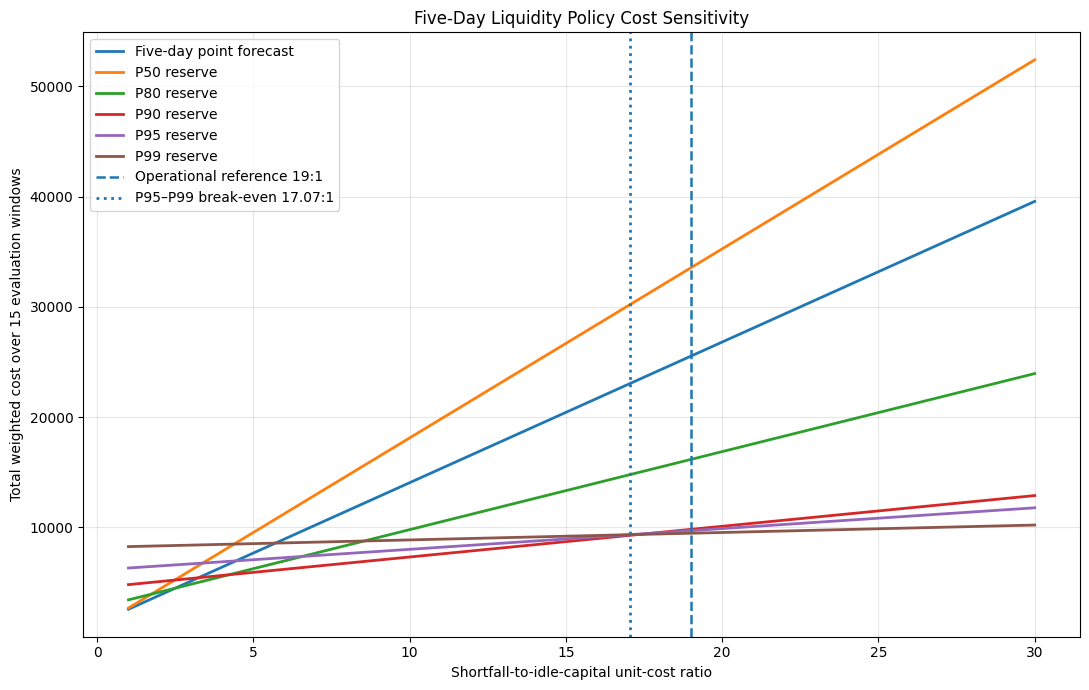

,check,observed,expected,status
0,policy_outcome_rows,6,6,PASS
1,cost_ratio_grid_points,991,991,PASS
2,cost_sensitivity_rows,5946,5946,PASS
3,cost_ratio_winner_rows,991,991,PASS
4,finite_p95_p99_break_even,True,True,PASS
5,p99_wins_operational_reference,reserve_p99,reserve_p99,PASS
6,operational_cost_recalculation_matches,True,True,PASS
7,nonfinite_cost_sensitivity_values,0,0,PASS
8,cost_sensitivity_figure_created,True,True,PASS



Empirical optimal-policy regions:


,winner_region_id,empirical_winner_policy_id,empirical_winner_policy_label,empirical_winner_nominal_quantile,minimum_cost_ratio,maximum_cost_ratio,minimum_theoretical_quantile,maximum_theoretical_quantile,grid_points
0,1,point_forecast_sum,Five-day point forecast,NaN,1.0000,2.5000,0.5000,0.7143,16
1,2,reserve_p80,P80 reserve,0.8000,2.6000,4.2000,0.7222,0.8077,17
2,3,reserve_p90,P90 reserve,0.9000,4.3000,17.3000,0.8113,0.9454,131
3,4,reserve_p99,P99 reserve,0.9900,17.4000,100.0000,0.9457,0.9901,827



Exact P95–P99 break-even:


,comparison,p95_total_shortfall,p99_total_shortfall,shortfall_reduction_with_p99,p95_total_idle_capital,p99_total_idle_capital,additional_idle_capital_with_p99,break_even_cost_ratio,break_even_theoretical_quantile,preferred_below_break_even,preferred_above_break_even,evaluation_windows
0,reserve_p95_vs_reserve_p99,188.1571,67.3872,120.7698,"6,139.7208","8,200.6959","2,060.9751",17.0653,0.9446,reserve_p95,reserve_p99,15



Operational reference — 19:1 cost regret:


,policy_id,nominal_quantile,mean_reserve_5d,shortfall_count,total_shortfall_amount,mean_idle_capital,service_level,total_cost,cost_regret_vs_empirical_winner,cost_regret_percent,is_empirical_cost_winner
0,reserve_p99,0.9900,"4,964.6922",1,67.3872,546.7131,0.9333,"9,481.0534",0.0000,0.0000,True
1,reserve_p95,0.9500,"4,819.2425",1,188.1571,409.3147,0.9333,"9,714.7049",233.6515,2.4644,False
2,reserve_p90,0.9000,"4,706.8000",2,278.3526,302.8852,0.8667,"9,831.9774",350.9239,3.7013,False
3,reserve_p80,0.8000,"4,557.5774",4,707.2784,182.2576,0.7333,"16,172.1537","6,691.1002",70.5734,False
4,point_forecast_sum,NaN,"4,425.1513",7,"1,274.8100",87.6671,0.5333,"25,536.3948","16,055.3414",169.3413,False
5,reserve_p50,0.5000,"4,374.1911",8,"1,713.4553",65.9498,0.4667,"33,544.8983","24,063.8449",253.8098,False


In [17]:
# ---------------------------------------------------------------------
# Policy outcomes independent of the assumed cost ratio
# ---------------------------------------------------------------------
liquidity_policy_outcomes = (
    reserve_policy_fold_base
    .groupby(
        [
            "policy_id",
            "policy_label",
            "policy_role",
            "nominal_quantile",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        evaluation_windows=("fold_id", "size"),
        mean_reserve_5d=("reserve_5d", "mean"),
        shortfall_count=("shortfall_event", "sum"),
        service_success_count=("service_success", "sum"),
        total_shortfall_amount=("shortfall_amount", "sum"),
        mean_shortfall_amount=("shortfall_amount", "mean"),
        maximum_shortfall_amount=("shortfall_amount", "max"),
        total_idle_capital=("idle_capital_amount", "sum"),
        mean_idle_capital=("idle_capital_amount", "mean"),
        maximum_idle_capital=("idle_capital_amount", "max"),
    )
)

liquidity_policy_outcomes["service_level"] = (
    liquidity_policy_outcomes["service_success_count"]
    / liquidity_policy_outcomes["evaluation_windows"]
)


# ---------------------------------------------------------------------
# Continuous sensitivity grid from 1:1 through 100:1
# ---------------------------------------------------------------------
cost_ratio_values = np.linspace(
    1.0,
    100.0,
    991,
)

cost_ratio_grid = pd.DataFrame(
    {
        "cost_ratio_shortfall_to_idle": (
            cost_ratio_values
        )
    }
)

cost_ratio_grid["theoretical_optimal_quantile"] = (
    cost_ratio_grid["cost_ratio_shortfall_to_idle"]
    / (
        cost_ratio_grid["cost_ratio_shortfall_to_idle"]
        + 1.0
    )
)


liquidity_cost_sensitivity = (
    liquidity_policy_outcomes.assign(_cross_key=1)
    .merge(
        cost_ratio_grid.assign(_cross_key=1),
        on="_cross_key",
        how="inner",
        validate="many_to_many",
    )
    .drop(columns="_cross_key")
)

liquidity_cost_sensitivity["total_cost"] = (
    liquidity_cost_sensitivity[
        "cost_ratio_shortfall_to_idle"
    ]
    * liquidity_cost_sensitivity[
        "total_shortfall_amount"
    ]
    + liquidity_cost_sensitivity[
        "total_idle_capital"
    ]
)

liquidity_cost_sensitivity["mean_cost_per_window"] = (
    liquidity_cost_sensitivity["total_cost"]
    / liquidity_cost_sensitivity[
        "evaluation_windows"
    ]
)


# ---------------------------------------------------------------------
# Identify the lowest-cost policy at every cost ratio
# ---------------------------------------------------------------------
cost_ratio_winner_indices = (
    liquidity_cost_sensitivity
    .groupby(
        "cost_ratio_shortfall_to_idle"
    )["total_cost"]
    .idxmin()
)

liquidity_cost_ratio_winners = (
    liquidity_cost_sensitivity
    .loc[
        cost_ratio_winner_indices,
        [
            "cost_ratio_shortfall_to_idle",
            "theoretical_optimal_quantile",
            "policy_id",
            "policy_label",
            "nominal_quantile",
            "mean_reserve_5d",
            "service_level",
            "total_shortfall_amount",
            "total_idle_capital",
            "total_cost",
            "mean_cost_per_window",
        ],
    ]
    .rename(
        columns={
            "policy_id": "empirical_winner_policy_id",
            "policy_label": "empirical_winner_policy_label",
            "nominal_quantile": (
                "empirical_winner_nominal_quantile"
            ),
        }
    )
    .sort_values("cost_ratio_shortfall_to_idle")
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Compress the grid into contiguous empirical winner regions
# ---------------------------------------------------------------------
liquidity_cost_ratio_winners["winner_changed"] = (
    liquidity_cost_ratio_winners[
        "empirical_winner_policy_id"
    ]
    .ne(
        liquidity_cost_ratio_winners[
            "empirical_winner_policy_id"
        ].shift()
    )
)

liquidity_cost_ratio_winners["winner_region_id"] = (
    liquidity_cost_ratio_winners[
        "winner_changed"
    ].cumsum()
)

liquidity_policy_optimal_regions = (
    liquidity_cost_ratio_winners
    .groupby(
        [
            "winner_region_id",
            "empirical_winner_policy_id",
            "empirical_winner_policy_label",
            "empirical_winner_nominal_quantile",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        minimum_cost_ratio=(
            "cost_ratio_shortfall_to_idle",
            "min",
        ),
        maximum_cost_ratio=(
            "cost_ratio_shortfall_to_idle",
            "max",
        ),
        minimum_theoretical_quantile=(
            "theoretical_optimal_quantile",
            "min",
        ),
        maximum_theoretical_quantile=(
            "theoretical_optimal_quantile",
            "max",
        ),
        grid_points=("total_cost", "size"),
    )
)


# ---------------------------------------------------------------------
# Exact P95 versus P99 break-even calculation
# ---------------------------------------------------------------------
p95_outcome = (
    liquidity_policy_outcomes.loc[
        liquidity_policy_outcomes["policy_id"]
        == "reserve_p95"
    ]
    .iloc[0]
)

p99_outcome = (
    liquidity_policy_outcomes.loc[
        liquidity_policy_outcomes["policy_id"]
        == "reserve_p99"
    ]
    .iloc[0]
)

shortfall_reduction_p99_vs_p95 = float(
    p95_outcome["total_shortfall_amount"]
    - p99_outcome["total_shortfall_amount"]
)

additional_idle_capital_p99_vs_p95 = float(
    p99_outcome["total_idle_capital"]
    - p95_outcome["total_idle_capital"]
)

if shortfall_reduction_p99_vs_p95 <= 0:
    raise ValueError(
        "P99 must reduce total shortfall relative to P95 "
        "for the requested break-even calculation."
    )

p95_p99_break_even_ratio = (
    additional_idle_capital_p99_vs_p95
    / shortfall_reduction_p99_vs_p95
)

p95_p99_break_even_quantile = (
    p95_p99_break_even_ratio
    / (p95_p99_break_even_ratio + 1.0)
)

p95_p99_break_even = pd.DataFrame(
    [
        {
            "comparison": "reserve_p95_vs_reserve_p99",
            "p95_total_shortfall": float(
                p95_outcome["total_shortfall_amount"]
            ),
            "p99_total_shortfall": float(
                p99_outcome["total_shortfall_amount"]
            ),
            "shortfall_reduction_with_p99": (
                shortfall_reduction_p99_vs_p95
            ),
            "p95_total_idle_capital": float(
                p95_outcome["total_idle_capital"]
            ),
            "p99_total_idle_capital": float(
                p99_outcome["total_idle_capital"]
            ),
            "additional_idle_capital_with_p99": (
                additional_idle_capital_p99_vs_p95
            ),
            "break_even_cost_ratio": float(
                p95_p99_break_even_ratio
            ),
            "break_even_theoretical_quantile": float(
                p95_p99_break_even_quantile
            ),
            "preferred_below_break_even": "reserve_p95",
            "preferred_above_break_even": "reserve_p99",
            "evaluation_windows": (
                EXPECTED_PROBABILISTIC_EVALUATION_FOLDS
            ),
        }
    ]
)


# ---------------------------------------------------------------------
# Cost and regret under the operational 19:1 reference scenario
# ---------------------------------------------------------------------
OPERATIONAL_COST_RATIO = 19.0

operational_base_cost_regret = (
    liquidity_policy_outcomes.copy()
)

operational_base_cost_regret[
    "cost_ratio_shortfall_to_idle"
] = OPERATIONAL_COST_RATIO

operational_base_cost_regret["total_cost"] = (
    OPERATIONAL_COST_RATIO
    * operational_base_cost_regret[
        "total_shortfall_amount"
    ]
    + operational_base_cost_regret[
        "total_idle_capital"
    ]
)

minimum_operational_cost = float(
    operational_base_cost_regret[
        "total_cost"
    ].min()
)

operational_base_cost_regret[
    "cost_regret_vs_empirical_winner"
] = (
    operational_base_cost_regret["total_cost"]
    - minimum_operational_cost
)

operational_base_cost_regret[
    "cost_regret_percent"
] = (
    100.0
    * operational_base_cost_regret[
        "cost_regret_vs_empirical_winner"
    ]
    / minimum_operational_cost
)

operational_base_cost_regret[
    "is_empirical_cost_winner"
] = (
    operational_base_cost_regret["total_cost"]
    == minimum_operational_cost
)

operational_base_cost_regret = (
    operational_base_cost_regret
    .sort_values("total_cost")
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Confirm agreement with the previously computed 19:1 table
# ---------------------------------------------------------------------
operational_cost_validation = (
    operational_base_cost_regret[
        ["policy_id", "total_cost"]
    ]
    .merge(
        operational_base_policy_comparison[
            [
                "policy_id",
                "total_cost",
            ]
        ].rename(
            columns={
                "total_cost": (
                    "previous_total_cost"
                )
            }
        ),
        on="policy_id",
        how="left",
        validate="one_to_one",
    )
)

operational_cost_validation[
    "absolute_difference"
] = (
    operational_cost_validation["total_cost"]
    - operational_cost_validation[
        "previous_total_cost"
    ]
).abs()

maximum_operational_cost_difference = float(
    operational_cost_validation[
        "absolute_difference"
    ].max()
)


# ---------------------------------------------------------------------
# Figure: policy cost sensitivity around the operational region
# ---------------------------------------------------------------------
cost_sensitivity_focus = (
    liquidity_cost_sensitivity.loc[
        liquidity_cost_sensitivity[
            "cost_ratio_shortfall_to_idle"
        ] <= 30.0
    ]
    .copy()
)

fig, ax = plt.subplots(figsize=(11, 7))

for policy_id, policy_data in (
    cost_sensitivity_focus.groupby("policy_id")
):
    policy_data = policy_data.sort_values(
        "cost_ratio_shortfall_to_idle"
    )

    policy_label = (
        policy_data["policy_label"].iloc[0]
    )

    ax.plot(
        policy_data[
            "cost_ratio_shortfall_to_idle"
        ],
        policy_data["total_cost"],
        linewidth=2,
        label=policy_label,
    )

ax.axvline(
    OPERATIONAL_COST_RATIO,
    linestyle="--",
    linewidth=1.8,
    label="Operational reference 19:1",
)

ax.axvline(
    p95_p99_break_even_ratio,
    linestyle=":",
    linewidth=2,
    label=(
        "P95–P99 break-even "
        f"{p95_p99_break_even_ratio:.2f}:1"
    ),
)

ax.set_title(
    "Five-Day Liquidity Policy Cost Sensitivity"
)
ax.set_xlabel(
    "Shortfall-to-idle-capital unit-cost ratio"
)
ax.set_ylabel(
    "Total weighted cost over 15 evaluation windows"
)
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()

cost_sensitivity_figure_path = (
    FIGURES_DIR
    / "07_liquidity_policy_cost_sensitivity.png"
)

fig.savefig(
    cost_sensitivity_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------------------
# Sensitivity-analysis audit
# ---------------------------------------------------------------------
expected_cost_ratio_points = len(
    cost_ratio_grid
)

expected_cost_sensitivity_rows = (
    expected_cost_ratio_points
    * len(reserve_policy_registry)
)

nonfinite_cost_sensitivity_values = int(
    (
        ~np.isfinite(
            liquidity_cost_sensitivity[
                [
                    "cost_ratio_shortfall_to_idle",
                    "total_shortfall_amount",
                    "total_idle_capital",
                    "total_cost",
                ]
            ].to_numpy(dtype=float)
        )
    ).sum()
)

liquidity_cost_sensitivity_audit = pd.DataFrame(
    [
        {
            "check": "policy_outcome_rows",
            "observed": len(
                liquidity_policy_outcomes
            ),
            "expected": 6,
        },
        {
            "check": "cost_ratio_grid_points",
            "observed": expected_cost_ratio_points,
            "expected": 991,
        },
        {
            "check": "cost_sensitivity_rows",
            "observed": len(
                liquidity_cost_sensitivity
            ),
            "expected": expected_cost_sensitivity_rows,
        },
        {
            "check": "cost_ratio_winner_rows",
            "observed": len(
                liquidity_cost_ratio_winners
            ),
            "expected": expected_cost_ratio_points,
        },
        {
            "check": "finite_p95_p99_break_even",
            "observed": bool(
                np.isfinite(
                    p95_p99_break_even_ratio
                )
            ),
            "expected": True,
        },
        {
            "check": "p99_wins_operational_reference",
            "observed": (
                operational_base_cost_regret
                .iloc[0]["policy_id"]
            ),
            "expected": "reserve_p99",
        },
        {
            "check": "operational_cost_recalculation_matches",
            "observed": (
                maximum_operational_cost_difference
                <= 1e-8
            ),
            "expected": True,
        },
        {
            "check": "nonfinite_cost_sensitivity_values",
            "observed": (
                nonfinite_cost_sensitivity_values
            ),
            "expected": 0,
        },
        {
            "check": "cost_sensitivity_figure_created",
            "observed": (
                cost_sensitivity_figure_path.exists()
            ),
            "expected": True,
        },
    ]
)

liquidity_cost_sensitivity_audit["status"] = np.where(
    liquidity_cost_sensitivity_audit[
        "observed"
    ].astype(str)
    == liquidity_cost_sensitivity_audit[
        "expected"
    ].astype(str),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Save all generated artifacts
# ---------------------------------------------------------------------
policy_outcomes_path = (
    DATA_PROCESSED_DIR
    / "07_liquidity_policy_outcomes.csv"
)

cost_sensitivity_path = (
    DATA_PROCESSED_DIR
    / "07_liquidity_cost_ratio_sensitivity.csv"
)

cost_ratio_winners_path = (
    DATA_PROCESSED_DIR
    / "07_liquidity_cost_ratio_winners.csv"
)

optimal_regions_path = (
    DATA_PROCESSED_DIR
    / "07_liquidity_policy_optimal_regions.csv"
)

break_even_path = (
    DATA_PROCESSED_DIR
    / "07_p95_p99_break_even_analysis.csv"
)

operational_regret_path = (
    DATA_PROCESSED_DIR
    / "07_operational_base_cost_regret.csv"
)

cost_sensitivity_audit_path = (
    DATA_PROCESSED_DIR
    / "07_liquidity_cost_sensitivity_audit.csv"
)


liquidity_policy_outcomes.to_csv(
    policy_outcomes_path,
    index=False,
)

liquidity_cost_sensitivity.to_csv(
    cost_sensitivity_path,
    index=False,
)

liquidity_cost_ratio_winners.to_csv(
    cost_ratio_winners_path,
    index=False,
)

liquidity_policy_optimal_regions.to_csv(
    optimal_regions_path,
    index=False,
)

p95_p99_break_even.to_csv(
    break_even_path,
    index=False,
)

operational_base_cost_regret.to_csv(
    operational_regret_path,
    index=False,
)

liquidity_cost_sensitivity_audit.to_csv(
    cost_sensitivity_audit_path,
    index=False,
)


required_sensitivity_paths = [
    policy_outcomes_path,
    cost_sensitivity_path,
    cost_ratio_winners_path,
    optimal_regions_path,
    break_even_path,
    operational_regret_path,
    cost_sensitivity_audit_path,
    cost_sensitivity_figure_path,
]

assert all(
    path.exists()
    for path in required_sensitivity_paths
)

assert liquidity_cost_sensitivity_audit[
    "status"
].eq("PASS").all(), (
    "The liquidity-cost sensitivity analysis failed."
)


display(liquidity_cost_sensitivity_audit)

print("\nEmpirical optimal-policy regions:")
display(liquidity_policy_optimal_regions)

print("\nExact P95–P99 break-even:")
display(p95_p99_break_even)

print("\nOperational reference — 19:1 cost regret:")
display(
    operational_base_cost_regret[
        [
            "policy_id",
            "nominal_quantile",
            "mean_reserve_5d",
            "shortfall_count",
            "total_shortfall_amount",
            "mean_idle_capital",
            "service_level",
            "total_cost",
            "cost_regret_vs_empirical_winner",
            "cost_regret_percent",
            "is_empirical_cost_winner",
        ]
    ]
)

## 14. Leave-one-window-out policy robustness

The operational evaluation contains only 15 five-day windows. A single extreme shortfall may therefore influence the cost-sensitive policy decision.

A leave-one-window-out analysis is used to test whether the operational policy remains stable when each evaluation window is removed in turn.

For every omitted window:

1. Business metrics are recomputed over the remaining 14 windows.
2. The lowest-cost reserve policy is identified under the 19:1 operational cost ratio.
3. P95 and P99 are compared directly.
4. The P95–P99 break-even ratio is recalculated.

This analysis does not refit the forecasting model or regenerate probabilistic forecasts. It evaluates only the robustness of the business-policy decision based on the already frozen out-of-sample reserves.

A robust P99 decision would be supported if:

- P99 remains the lowest-cost policy in most leave-one-out samples.
- P99 generally retains lower cost than P95.
- The recalculated P95–P99 break-even ratio remains near or below the operational 19:1 assumption.

The analysis is diagnostic because 14-window subsets still represent limited evidence.

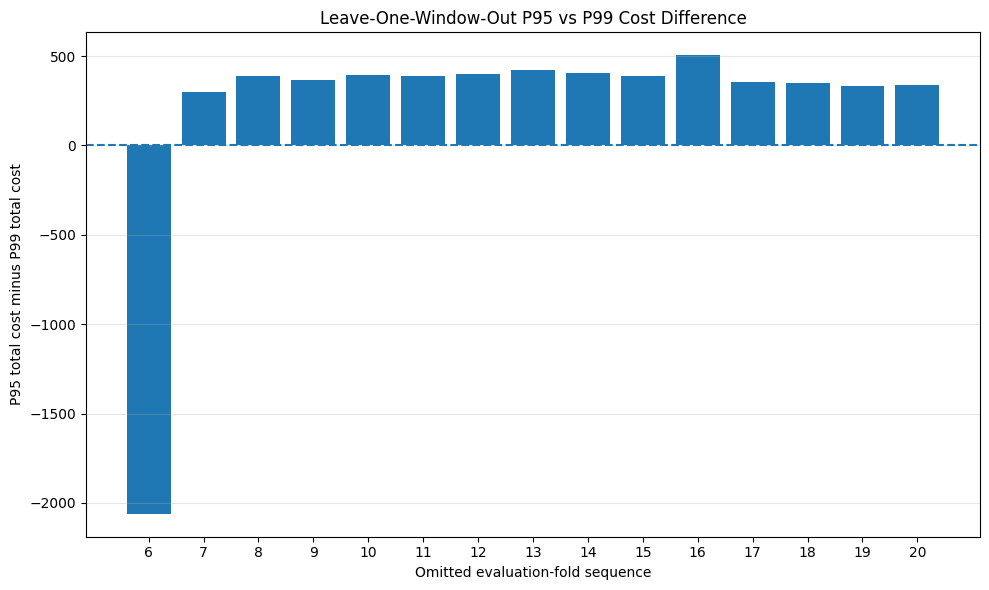

,check,observed,expected,status
0,evaluation_windows,15,15,PASS
1,leave_one_out_policy_metric_rows,90,90,PASS
2,leave_one_out_winner_rows,15,15,PASS
3,leave_one_out_p95_p99_rows,15,15,PASS
4,retained_windows_per_policy,14,14,PASS
5,duplicate_omission_policy_rows,0,0,PASS
6,nonfinite_leave_one_out_costs,0,0,PASS
7,leave_one_out_figure_created,True,True,PASS



Leave-one-window-out policy winners:


,winning_policy_id,winning_policy_label,winning_nominal_quantile,leave_one_out_samples_won,mean_winning_cost,mean_winning_service_level
0,reserve_p99,P99 reserve,0.9900,13,"8,868.4684",0.9286
1,reserve_p90,P90 reserve,0.9000,2,"7,187.6278",0.9286



P95 versus P99 preference summary:


,preferred_policy,leave_one_out_samples,mean_p95_minus_p99_cost,median_p95_minus_p99_cost
0,reserve_p99,14,380.8640,387.0030
1,reserve_p95,1,"-2,060.9751","-2,060.9751"



P95–P99 break-even robustness:


,leave_one_out_samples,finite_break_even_samples,minimum_break_even_ratio,median_break_even_ratio,mean_break_even_ratio,maximum_break_even_ratio,samples_break_even_at_or_below_19,samples_p99_preferred_at_19,samples_p95_preferred_at_19,samples_tied_at_19
0,15,14,14.8198,15.7955,15.8464,16.5147,14,14,1,0


In [18]:
# ---------------------------------------------------------------------
# Leave-one-window-out robustness under the operational 19:1 scenario
# ---------------------------------------------------------------------
OPERATIONAL_COST_RATIO = 19.0

evaluation_windows = (
    reserve_policy_fold_base[
        ["fold_id", "fold_sequence"]
    ]
    .drop_duplicates()
    .sort_values("fold_sequence")
    .reset_index(drop=True)
)

leave_one_out_metric_frames = []
leave_one_out_winner_rows = []
leave_one_out_p95_p99_rows = []

for omitted_window in evaluation_windows.itertuples(index=False):

    retained_data = reserve_policy_fold_base.loc[
        reserve_policy_fold_base["fold_id"]
        != omitted_window.fold_id
    ].copy()

    leave_one_out_metrics = (
        retained_data
        .groupby(
            [
                "policy_id",
                "policy_label",
                "nominal_quantile",
            ],
            as_index=False,
            dropna=False,
        )
        .agg(
            retained_windows=("fold_id", "nunique"),
            mean_reserve_5d=("reserve_5d", "mean"),
            shortfall_count=("shortfall_event", "sum"),
            total_shortfall_amount=(
                "shortfall_amount",
                "sum",
            ),
            total_idle_capital=(
                "idle_capital_amount",
                "sum",
            ),
            mean_idle_capital=(
                "idle_capital_amount",
                "mean",
            ),
            service_success_count=(
                "service_success",
                "sum",
            ),
        )
    )

    leave_one_out_metrics["service_level"] = (
        leave_one_out_metrics[
            "service_success_count"
        ]
        / leave_one_out_metrics["retained_windows"]
    )

    leave_one_out_metrics["total_cost"] = (
        OPERATIONAL_COST_RATIO
        * leave_one_out_metrics[
            "total_shortfall_amount"
        ]
        + leave_one_out_metrics[
            "total_idle_capital"
        ]
    )

    minimum_cost = float(
        leave_one_out_metrics["total_cost"].min()
    )

    leave_one_out_metrics[
        "cost_regret_vs_loo_winner"
    ] = (
        leave_one_out_metrics["total_cost"]
        - minimum_cost
    )

    leave_one_out_metrics[
        "omitted_fold_id"
    ] = omitted_window.fold_id

    leave_one_out_metrics[
        "omitted_fold_sequence"
    ] = omitted_window.fold_sequence

    leave_one_out_metric_frames.append(
        leave_one_out_metrics
    )

    winning_row = (
        leave_one_out_metrics
        .sort_values(
            ["total_cost", "policy_id"]
        )
        .iloc[0]
    )

    leave_one_out_winner_rows.append(
        {
            "omitted_fold_id": omitted_window.fold_id,
            "omitted_fold_sequence": (
                omitted_window.fold_sequence
            ),
            "winning_policy_id": (
                winning_row["policy_id"]
            ),
            "winning_policy_label": (
                winning_row["policy_label"]
            ),
            "winning_nominal_quantile": (
                winning_row["nominal_quantile"]
            ),
            "winning_total_cost": float(
                winning_row["total_cost"]
            ),
            "winning_service_level": float(
                winning_row["service_level"]
            ),
            "winning_shortfall_count": int(
                winning_row["shortfall_count"]
            ),
        }
    )

    p95_row = (
        leave_one_out_metrics.loc[
            leave_one_out_metrics["policy_id"]
            == "reserve_p95"
        ]
        .iloc[0]
    )

    p99_row = (
        leave_one_out_metrics.loc[
            leave_one_out_metrics["policy_id"]
            == "reserve_p99"
        ]
        .iloc[0]
    )

    shortfall_reduction = float(
        p95_row["total_shortfall_amount"]
        - p99_row["total_shortfall_amount"]
    )

    additional_idle_capital = float(
        p99_row["total_idle_capital"]
        - p95_row["total_idle_capital"]
    )

    if shortfall_reduction > 0:
        break_even_ratio = (
            additional_idle_capital
            / shortfall_reduction
        )

        break_even_quantile = (
            break_even_ratio
            / (break_even_ratio + 1.0)
        )
    else:
        break_even_ratio = np.nan
        break_even_quantile = np.nan

    p95_minus_p99_cost = float(
        p95_row["total_cost"]
        - p99_row["total_cost"]
    )

    if p95_minus_p99_cost > 0:
        preferred_policy = "reserve_p99"
    elif p95_minus_p99_cost < 0:
        preferred_policy = "reserve_p95"
    else:
        preferred_policy = "tie"

    leave_one_out_p95_p99_rows.append(
        {
            "omitted_fold_id": omitted_window.fold_id,
            "omitted_fold_sequence": (
                omitted_window.fold_sequence
            ),
            "p95_total_cost": float(
                p95_row["total_cost"]
            ),
            "p99_total_cost": float(
                p99_row["total_cost"]
            ),
            "p95_minus_p99_total_cost": (
                p95_minus_p99_cost
            ),
            "preferred_policy": preferred_policy,
            "p95_total_shortfall": float(
                p95_row["total_shortfall_amount"]
            ),
            "p99_total_shortfall": float(
                p99_row["total_shortfall_amount"]
            ),
            "shortfall_reduction_with_p99": (
                shortfall_reduction
            ),
            "p95_total_idle_capital": float(
                p95_row["total_idle_capital"]
            ),
            "p99_total_idle_capital": float(
                p99_row["total_idle_capital"]
            ),
            "additional_idle_capital_with_p99": (
                additional_idle_capital
            ),
            "break_even_cost_ratio": (
                break_even_ratio
            ),
            "break_even_theoretical_quantile": (
                break_even_quantile
            ),
        }
    )


leave_one_out_policy_metrics = pd.concat(
    leave_one_out_metric_frames,
    ignore_index=True,
)

leave_one_out_policy_winners = pd.DataFrame(
    leave_one_out_winner_rows
)

leave_one_out_p95_p99 = pd.DataFrame(
    leave_one_out_p95_p99_rows
)


# ---------------------------------------------------------------------
# Compact robustness summaries
# ---------------------------------------------------------------------
leave_one_out_winner_summary = (
    leave_one_out_policy_winners
    .groupby(
        [
            "winning_policy_id",
            "winning_policy_label",
            "winning_nominal_quantile",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        leave_one_out_samples_won=(
            "omitted_fold_id",
            "size",
        ),
        mean_winning_cost=(
            "winning_total_cost",
            "mean",
        ),
        mean_winning_service_level=(
            "winning_service_level",
            "mean",
        ),
    )
    .sort_values(
        [
            "leave_one_out_samples_won",
            "winning_policy_id",
        ],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)


p95_p99_preference_summary = (
    leave_one_out_p95_p99
    .groupby(
        "preferred_policy",
        as_index=False,
    )
    .agg(
        leave_one_out_samples=(
            "omitted_fold_id",
            "size",
        ),
        mean_p95_minus_p99_cost=(
            "p95_minus_p99_total_cost",
            "mean",
        ),
        median_p95_minus_p99_cost=(
            "p95_minus_p99_total_cost",
            "median",
        ),
    )
    .sort_values(
        "leave_one_out_samples",
        ascending=False,
    )
    .reset_index(drop=True)
)


finite_break_even_values = (
    leave_one_out_p95_p99[
        "break_even_cost_ratio"
    ]
    .dropna()
)

p95_p99_break_even_robustness = pd.DataFrame(
    [
        {
            "leave_one_out_samples": len(
                leave_one_out_p95_p99
            ),
            "finite_break_even_samples": len(
                finite_break_even_values
            ),
            "minimum_break_even_ratio": float(
                finite_break_even_values.min()
            ),
            "median_break_even_ratio": float(
                finite_break_even_values.median()
            ),
            "mean_break_even_ratio": float(
                finite_break_even_values.mean()
            ),
            "maximum_break_even_ratio": float(
                finite_break_even_values.max()
            ),
            "samples_break_even_at_or_below_19": int(
                (
                    finite_break_even_values
                    <= OPERATIONAL_COST_RATIO
                ).sum()
            ),
            "samples_p99_preferred_at_19": int(
                (
                    leave_one_out_p95_p99[
                        "preferred_policy"
                    ]
                    == "reserve_p99"
                ).sum()
            ),
            "samples_p95_preferred_at_19": int(
                (
                    leave_one_out_p95_p99[
                        "preferred_policy"
                    ]
                    == "reserve_p95"
                ).sum()
            ),
            "samples_tied_at_19": int(
                (
                    leave_one_out_p95_p99[
                        "preferred_policy"
                    ]
                    == "tie"
                ).sum()
            ),
        }
    ]
)


# ---------------------------------------------------------------------
# Figure: P95 cost minus P99 cost after omitting each window
# Positive values indicate that P99 has lower total cost.
# ---------------------------------------------------------------------
figure_data = (
    leave_one_out_p95_p99
    .sort_values("omitted_fold_sequence")
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    figure_data["omitted_fold_sequence"].astype(str),
    figure_data["p95_minus_p99_total_cost"],
)

ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1.5,
)

ax.set_title(
    "Leave-One-Window-Out P95 vs P99 Cost Difference"
)
ax.set_xlabel("Omitted evaluation-fold sequence")
ax.set_ylabel(
    "P95 total cost minus P99 total cost"
)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

leave_one_out_figure_path = (
    FIGURES_DIR
    / "07_leave_one_out_p95_vs_p99_cost_difference.png"
)

fig.savefig(
    leave_one_out_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------------------
# Robustness audit
# ---------------------------------------------------------------------
nonfinite_leave_one_out_costs = int(
    (
        ~np.isfinite(
            leave_one_out_policy_metrics[
                [
                    "total_shortfall_amount",
                    "total_idle_capital",
                    "service_level",
                    "total_cost",
                ]
            ].to_numpy(dtype=float)
        )
    ).sum()
)

leave_one_out_policy_audit = pd.DataFrame(
    [
        {
            "check": "evaluation_windows",
            "observed": len(evaluation_windows),
            "expected": 15,
        },
        {
            "check": "leave_one_out_policy_metric_rows",
            "observed": len(
                leave_one_out_policy_metrics
            ),
            "expected": 90,
        },
        {
            "check": "leave_one_out_winner_rows",
            "observed": len(
                leave_one_out_policy_winners
            ),
            "expected": 15,
        },
        {
            "check": "leave_one_out_p95_p99_rows",
            "observed": len(
                leave_one_out_p95_p99
            ),
            "expected": 15,
        },
        {
            "check": "retained_windows_per_policy",
            "observed": int(
                leave_one_out_policy_metrics[
                    "retained_windows"
                ].min()
            ),
            "expected": 14,
        },
        {
            "check": "duplicate_omission_policy_rows",
            "observed": int(
                leave_one_out_policy_metrics
                .duplicated(
                    subset=[
                        "omitted_fold_id",
                        "policy_id",
                    ]
                )
                .sum()
            ),
            "expected": 0,
        },
        {
            "check": "nonfinite_leave_one_out_costs",
            "observed": (
                nonfinite_leave_one_out_costs
            ),
            "expected": 0,
        },
        {
            "check": "leave_one_out_figure_created",
            "observed": (
                leave_one_out_figure_path.exists()
            ),
            "expected": True,
        },
    ]
)

leave_one_out_policy_audit["status"] = np.where(
    leave_one_out_policy_audit[
        "observed"
    ].astype(str)
    == leave_one_out_policy_audit[
        "expected"
    ].astype(str),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Save every output generated by this cell
# ---------------------------------------------------------------------
leave_one_out_metrics_path = (
    DATA_PROCESSED_DIR
    / "07_leave_one_out_policy_metrics.csv"
)

leave_one_out_winners_path = (
    DATA_PROCESSED_DIR
    / "07_leave_one_out_policy_winners.csv"
)

leave_one_out_winner_summary_path = (
    DATA_PROCESSED_DIR
    / "07_leave_one_out_policy_winner_summary.csv"
)

leave_one_out_p95_p99_path = (
    DATA_PROCESSED_DIR
    / "07_leave_one_out_p95_p99_comparison.csv"
)

p95_p99_preference_summary_path = (
    DATA_PROCESSED_DIR
    / "07_leave_one_out_p95_p99_preference_summary.csv"
)

break_even_robustness_path = (
    DATA_PROCESSED_DIR
    / "07_leave_one_out_p95_p99_break_even_robustness.csv"
)

leave_one_out_audit_path = (
    DATA_PROCESSED_DIR
    / "07_leave_one_out_policy_audit.csv"
)


leave_one_out_policy_metrics.to_csv(
    leave_one_out_metrics_path,
    index=False,
)

leave_one_out_policy_winners.to_csv(
    leave_one_out_winners_path,
    index=False,
)

leave_one_out_winner_summary.to_csv(
    leave_one_out_winner_summary_path,
    index=False,
)

leave_one_out_p95_p99.to_csv(
    leave_one_out_p95_p99_path,
    index=False,
)

p95_p99_preference_summary.to_csv(
    p95_p99_preference_summary_path,
    index=False,
)

p95_p99_break_even_robustness.to_csv(
    break_even_robustness_path,
    index=False,
)

leave_one_out_policy_audit.to_csv(
    leave_one_out_audit_path,
    index=False,
)


required_leave_one_out_paths = [
    leave_one_out_metrics_path,
    leave_one_out_winners_path,
    leave_one_out_winner_summary_path,
    leave_one_out_p95_p99_path,
    p95_p99_preference_summary_path,
    break_even_robustness_path,
    leave_one_out_audit_path,
    leave_one_out_figure_path,
]

assert all(
    path.exists()
    for path in required_leave_one_out_paths
)

assert leave_one_out_policy_audit[
    "status"
].eq("PASS").all(), (
    "The leave-one-window-out policy analysis failed."
)


display(leave_one_out_policy_audit)

print("\nLeave-one-window-out policy winners:")
display(leave_one_out_winner_summary)

print("\nP95 versus P99 preference summary:")
display(p95_p99_preference_summary)

print("\nP95–P99 break-even robustness:")
display(p95_p99_break_even_robustness)

## 15. Final liquidity reserve-policy decision

The selected operational five-day liquidity policy is:

```text
P99 reserve

In [19]:

# ---------------------------------------------------------------------
# Frozen reserve-policy decisions
# ---------------------------------------------------------------------
SELECTED_RESERVE_POLICY = "reserve_p99"
SENSITIVITY_RESERVE_POLICY = "reserve_p90"
THEORETICAL_OPERATIONAL_POLICY = "reserve_p95"

OPERATIONAL_COST_RATIO = 19.0


# ---------------------------------------------------------------------
# Recover the relevant evaluated policy outcomes
# ---------------------------------------------------------------------
selected_policy_row = (
    operational_base_cost_regret.loc[
        operational_base_cost_regret["policy_id"]
        == SELECTED_RESERVE_POLICY
    ]
    .iloc[0]
)

sensitivity_policy_row = (
    operational_base_cost_regret.loc[
        operational_base_cost_regret["policy_id"]
        == SENSITIVITY_RESERVE_POLICY
    ]
    .iloc[0]
)

theoretical_policy_row = (
    operational_base_cost_regret.loc[
        operational_base_cost_regret["policy_id"]
        == THEORETICAL_OPERATIONAL_POLICY
    ]
    .iloc[0]
)

point_policy_row = (
    operational_base_cost_regret.loc[
        operational_base_cost_regret["policy_id"]
        == "point_forecast_sum"
    ]
    .iloc[0]
)


# ---------------------------------------------------------------------
# Recover robustness evidence
# ---------------------------------------------------------------------
p99_leave_one_out_wins = int(
    leave_one_out_winner_summary.loc[
        leave_one_out_winner_summary[
            "winning_policy_id"
        ] == SELECTED_RESERVE_POLICY,
        "leave_one_out_samples_won",
    ].iloc[0]
)

p90_leave_one_out_wins = int(
    leave_one_out_winner_summary.loc[
        leave_one_out_winner_summary[
            "winning_policy_id"
        ] == SENSITIVITY_RESERVE_POLICY,
        "leave_one_out_samples_won",
    ].iloc[0]
)

p99_preferred_to_p95_samples = int(
    p95_p99_break_even_robustness[
        "samples_p99_preferred_at_19"
    ].iloc[0]
)

p95_preferred_to_p99_samples = int(
    p95_p99_break_even_robustness[
        "samples_p95_preferred_at_19"
    ].iloc[0]
)

full_sample_break_even_ratio = float(
    p95_p99_break_even[
        "break_even_cost_ratio"
    ].iloc[0]
)

median_leave_one_out_break_even_ratio = float(
    p95_p99_break_even_robustness[
        "median_break_even_ratio"
    ].iloc[0]
)


# ---------------------------------------------------------------------
# Recover empirical cost-ratio regions
# ---------------------------------------------------------------------
p99_optimal_region = (
    liquidity_policy_optimal_regions.loc[
        liquidity_policy_optimal_regions[
            "empirical_winner_policy_id"
        ] == SELECTED_RESERVE_POLICY
    ]
    .iloc[0]
)

p90_optimal_region = (
    liquidity_policy_optimal_regions.loc[
        liquidity_policy_optimal_regions[
            "empirical_winner_policy_id"
        ] == SENSITIVITY_RESERVE_POLICY
    ]
    .iloc[0]
)

p95_is_empirical_region_winner = bool(
    (
        liquidity_policy_optimal_regions[
            "empirical_winner_policy_id"
        ] == THEORETICAL_OPERATIONAL_POLICY
    ).any()
)


# ---------------------------------------------------------------------
# Register the operational role of every evaluated reserve policy
# ---------------------------------------------------------------------
policy_status_map = {
    "point_forecast_sum": "NON_PROBABILISTIC_BENCHMARK",
    "reserve_p50": "BALANCED_REFERENCE",
    "reserve_p80": "LOWER_COST_SENSITIVITY",
    "reserve_p90": "RETAINED_COST_SENSITIVITY_CHALLENGER",
    "reserve_p95": (
        "THEORETICAL_19_TO_1_REFERENCE_NOT_EMPIRICAL_WINNER"
    ),
    "reserve_p99": "SELECTED_OPERATIONAL_POLICY",
}

liquidity_policy_role_registry = (
    reserve_policy_registry.copy()
)

liquidity_policy_role_registry["operational_status"] = (
    liquidity_policy_role_registry["policy_id"]
    .map(policy_status_map)
)

liquidity_policy_role_registry[
    "empirical_optimal_minimum_cost_ratio"
] = np.nan

liquidity_policy_role_registry[
    "empirical_optimal_maximum_cost_ratio"
] = np.nan

for region_row in (
    liquidity_policy_optimal_regions.itertuples(
        index=False
    )
):
    matching_policy = (
        liquidity_policy_role_registry["policy_id"]
        == region_row.empirical_winner_policy_id
    )

    liquidity_policy_role_registry.loc[
        matching_policy,
        "empirical_optimal_minimum_cost_ratio",
    ] = region_row.minimum_cost_ratio

    liquidity_policy_role_registry.loc[
        matching_policy,
        "empirical_optimal_maximum_cost_ratio",
    ] = region_row.maximum_cost_ratio


# ---------------------------------------------------------------------
# Formal operational policy decision
# ---------------------------------------------------------------------
liquidity_reserve_policy_decision = pd.DataFrame(
    [
        {
            "decision_scope": (
                "five_day_liquidity_reserve_policy"
            ),
            "selected_policy_id": (
                SELECTED_RESERVE_POLICY
            ),
            "selected_policy_quantile": float(
                selected_policy_row[
                    "nominal_quantile"
                ]
            ),
            "decision_status": (
                "SELECTED_OPERATIONAL_POLICY_UNDER_19_TO_1"
            ),
            "decision_is_cost_conditional": True,
            "operational_cost_ratio_shortfall_to_idle": (
                OPERATIONAL_COST_RATIO
            ),
            "cost_implied_theoretical_quantile": (
                OPERATIONAL_COST_RATIO
                / (OPERATIONAL_COST_RATIO + 1.0)
            ),
            "theoretical_policy_id": (
                THEORETICAL_OPERATIONAL_POLICY
            ),
            "theoretical_policy_status": (
                "REFERENCE_NOT_EMPIRICAL_WINNER"
            ),
            "daily_probabilistic_method": (
                SELECTED_PROBABILISTIC_METHOD
            ),
            "joint_five_day_method": (
                SELECTED_FIVE_DAY_JOINT_METHOD
            ),
            "funding_lead_time_days": (
                FUNDING_LEAD_TIME
            ),
            "mean_selected_reserve_ars_million": float(
                selected_policy_row[
                    "mean_reserve_5d"
                ]
            ),
            "mean_increment_vs_point_forecast": float(
                selected_policy_row[
                    "mean_reserve_5d"
                ]
                - point_policy_row[
                    "mean_reserve_5d"
                ]
            ),
            "observed_service_level": float(
                selected_policy_row[
                    "service_level"
                ]
            ),
            "shortfall_windows": int(
                selected_policy_row[
                    "shortfall_count"
                ]
            ),
            "total_shortfall_ars_million": float(
                selected_policy_row[
                    "total_shortfall_amount"
                ]
            ),
            "mean_idle_capital_ars_million": float(
                selected_policy_row[
                    "mean_idle_capital"
                ]
            ),
            "operational_total_cost": float(
                selected_policy_row[
                    "total_cost"
                ]
            ),
            "p95_cost_regret_vs_selected": float(
                theoretical_policy_row[
                    "cost_regret_vs_empirical_winner"
                ]
            ),
            "p95_cost_regret_percent": float(
                theoretical_policy_row[
                    "cost_regret_percent"
                ]
            ),
            "point_forecast_cost_regret_percent": float(
                point_policy_row[
                    "cost_regret_percent"
                ]
            ),
            "p95_p99_full_sample_break_even_ratio": (
                full_sample_break_even_ratio
            ),
            "p95_p99_median_loo_break_even_ratio": (
                median_leave_one_out_break_even_ratio
            ),
            "p99_leave_one_out_policy_wins": (
                p99_leave_one_out_wins
            ),
            "p90_leave_one_out_policy_wins": (
                p90_leave_one_out_wins
            ),
            "p99_preferred_to_p95_loo_samples": (
                p99_preferred_to_p95_samples
            ),
            "p95_preferred_to_p99_loo_samples": (
                p95_preferred_to_p99_samples
            ),
            "sensitivity_policy_id": (
                SENSITIVITY_RESERVE_POLICY
            ),
            "sensitivity_policy_minimum_cost_ratio": float(
                p90_optimal_region[
                    "minimum_cost_ratio"
                ]
            ),
            "sensitivity_policy_maximum_cost_ratio": float(
                p90_optimal_region[
                    "maximum_cost_ratio"
                ]
            ),
            "selected_policy_minimum_cost_ratio": float(
                p99_optimal_region[
                    "minimum_cost_ratio"
                ]
            ),
            "selected_policy_maximum_cost_ratio": float(
                p99_optimal_region[
                    "maximum_cost_ratio"
                ]
            ),
            "analyst_adjustment_status": (
                "NOT_APPLIED_IN_BACKTEST"
            ),
            "evidence_limitation": (
                "The decision uses 15 five-day evaluation "
                "windows and is materially influenced by one "
                "extreme cumulative shortfall."
            ),
            "selection_reason": (
                "P99 minimizes observed cost under the explicit "
                "19:1 scenario, is preferred to P95 in 14 of 15 "
                "leave-one-window-out samples, and remains the "
                "overall lowest-cost policy in 13 of 15 samples."
            ),
        }
    ]
)


# ---------------------------------------------------------------------
# Final policy-selection audit
# ---------------------------------------------------------------------
operational_ratio_inside_p99_region = bool(
    float(
        p99_optimal_region["minimum_cost_ratio"]
    )
    <= OPERATIONAL_COST_RATIO
    <= float(
        p99_optimal_region["maximum_cost_ratio"]
    )
)

liquidity_policy_selection_audit = pd.DataFrame(
    [
        {
            "check": "policies_registered",
            "observed": len(
                liquidity_policy_role_registry
            ),
            "expected": 6,
        },
        {
            "check": "one_operational_policy_selected",
            "observed": int(
                (
                    liquidity_policy_role_registry[
                        "operational_status"
                    ]
                    == "SELECTED_OPERATIONAL_POLICY"
                ).sum()
            ),
            "expected": 1,
        },
        {
            "check": "selected_policy_matches_decision",
            "observed": (
                liquidity_reserve_policy_decision[
                    "selected_policy_id"
                ].iloc[0]
            ),
            "expected": SELECTED_RESERVE_POLICY,
        },
        {
            "check": "operational_ratio_above_break_even",
            "observed": (
                OPERATIONAL_COST_RATIO
                > full_sample_break_even_ratio
            ),
            "expected": True,
        },
        {
            "check": "operational_ratio_inside_p99_region",
            "observed": (
                operational_ratio_inside_p99_region
            ),
            "expected": True,
        },
        {
            "check": "p99_majority_leave_one_out_wins",
            "observed": (
                p99_leave_one_out_wins
                > len(evaluation_windows) / 2
            ),
            "expected": True,
        },
        {
            "check": "p99_preferred_to_p95_in_majority",
            "observed": (
                p99_preferred_to_p95_samples
                > len(evaluation_windows) / 2
            ),
            "expected": True,
        },
        {
            "check": "p90_retained_as_sensitivity_policy",
            "observed": (
                liquidity_reserve_policy_decision[
                    "sensitivity_policy_id"
                ].iloc[0]
            ),
            "expected": SENSITIVITY_RESERVE_POLICY,
        },
        {
            "check": "p95_not_empirical_region_winner",
            "observed": p95_is_empirical_region_winner,
            "expected": False,
        },
        {
            "check": "daily_method_remains_frozen",
            "observed": (
                liquidity_reserve_policy_decision[
                    "daily_probabilistic_method"
                ].iloc[0]
            ),
            "expected": (
                SELECTED_PROBABILISTIC_METHOD
            ),
        },
        {
            "check": "joint_method_remains_frozen",
            "observed": (
                liquidity_reserve_policy_decision[
                    "joint_five_day_method"
                ].iloc[0]
            ),
            "expected": (
                SELECTED_FIVE_DAY_JOINT_METHOD
            ),
        },
        {
            "check": "evidence_limitation_recorded",
            "observed": (
                liquidity_reserve_policy_decision[
                    "evidence_limitation"
                ]
                .str.len()
                .gt(0)
                .all()
            ),
            "expected": True,
        },
    ]
)

liquidity_policy_selection_audit[
    "status"
] = np.where(
    liquidity_policy_selection_audit[
        "observed"
    ].astype(str)
    == liquidity_policy_selection_audit[
        "expected"
    ].astype(str),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Save all final policy-decision artifacts
# ---------------------------------------------------------------------
policy_role_registry_path = (
    DATA_PROCESSED_DIR
    / "07_liquidity_policy_role_registry.csv"
)

final_policy_decision_path = (
    DATA_PROCESSED_DIR
    / "07_final_liquidity_policy_decision.csv"
)

final_policy_audit_path = (
    DATA_PROCESSED_DIR
    / "07_final_liquidity_policy_selection_audit.csv"
)

liquidity_policy_role_registry.to_csv(
    policy_role_registry_path,
    index=False,
)

liquidity_reserve_policy_decision.to_csv(
    final_policy_decision_path,
    index=False,
)

liquidity_policy_selection_audit.to_csv(
    final_policy_audit_path,
    index=False,
)


required_final_policy_paths = [
    policy_role_registry_path,
    final_policy_decision_path,
    final_policy_audit_path,
]

assert all(
    path.exists()
    for path in required_final_policy_paths
)

assert liquidity_policy_selection_audit[
    "status"
].eq("PASS").all(), (
    "The final liquidity-policy selection failed its audit."
)


display(liquidity_policy_selection_audit)

print("\nFinal liquidity reserve-policy decision:")
display(liquidity_reserve_policy_decision)

print("\nReserve-policy role registry:")
display(
    liquidity_policy_role_registry[
        [
            "policy_id",
            "nominal_quantile",
            "operational_status",
            "empirical_optimal_minimum_cost_ratio",
            "empirical_optimal_maximum_cost_ratio",
        ]
    ]
)

,check,observed,expected,status
0,policies_registered,6,6,PASS
1,one_operational_policy_selected,1,1,PASS
2,selected_policy_matches_decision,reserve_p99,reserve_p99,PASS
3,operational_ratio_above_break_even,True,True,PASS
4,operational_ratio_inside_p99_region,True,True,PASS
5,p99_majority_leave_one_out_wins,True,True,PASS
6,p99_preferred_to_p95_in_majority,True,True,PASS
7,p90_retained_as_sensitivity_policy,reserve_p90,reserve_p90,PASS
8,p95_not_empirical_region_winner,False,False,PASS
9,daily_method_remains_frozen,empirical_log_expanding,empirical_log_expanding,PASS



Final liquidity reserve-policy decision:


,decision_scope,selected_policy_id,selected_policy_quantile,decision_status,decision_is_cost_conditional,operational_cost_ratio_shortfall_to_idle,cost_implied_theoretical_quantile,theoretical_policy_id,theoretical_policy_status,daily_probabilistic_method,joint_five_day_method,funding_lead_time_days,mean_selected_reserve_ars_million,mean_increment_vs_point_forecast,observed_service_level,shortfall_windows,total_shortfall_ars_million,mean_idle_capital_ars_million,operational_total_cost,p95_cost_regret_vs_selected,p95_cost_regret_percent,point_forecast_cost_regret_percent,p95_p99_full_sample_break_even_ratio,p95_p99_median_loo_break_even_ratio,p99_leave_one_out_policy_wins,p90_leave_one_out_policy_wins,p99_preferred_to_p95_loo_samples,p95_preferred_to_p99_loo_samples,sensitivity_policy_id,sensitivity_policy_minimum_cost_ratio,sensitivity_policy_maximum_cost_ratio,selected_policy_minimum_cost_ratio,selected_policy_maximum_cost_ratio,analyst_adjustment_status,evidence_limitation,selection_reason
0,five_day_liquidity_reserve_policy,reserve_p99,0.9900,SELECTED_OPERATIONAL_POLICY_UNDER_19_TO_1,True,19.0000,0.9500,reserve_p95,REFERENCE_NOT_EMPIRICAL_WINNER,empirical_log_expanding,moving_block_log_bootstrap,5,"4,964.6922",539.5409,0.9333,1,67.3872,546.7131,"9,481.0534",233.6515,2.4644,169.3413,17.0653,15.7955,13,2,14,1,reserve_p90,4.3000,17.3000,17.4000,100.0000,NOT_APPLIED_IN_BACKTEST,The decision uses 15 five-day evaluation windo...,P99 minimizes observed cost under the explicit...



Reserve-policy role registry:


,policy_id,nominal_quantile,operational_status,empirical_optimal_minimum_cost_ratio,empirical_optimal_maximum_cost_ratio
0,point_forecast_sum,NaN,NON_PROBABILISTIC_BENCHMARK,1.0000,2.5000
1,reserve_p50,0.5000,BALANCED_REFERENCE,NaN,NaN
2,reserve_p80,0.8000,LOWER_COST_SENSITIVITY,2.6000,4.2000
3,reserve_p90,0.9000,RETAINED_COST_SENSITIVITY_CHALLENGER,4.3000,17.3000
4,reserve_p95,0.9500,THEORETICAL_19_TO_1_REFERENCE_NOT_EMPIRICAL_WI...,NaN,NaN
5,reserve_p99,0.9900,SELECTED_OPERATIONAL_POLICY,17.4000,100.0000


## 16. Operational liquidity recommendation output

The final operational table separates the model recommendation from any future analyst intervention.

For each five-day funding window, the table retains:

- Point-forecast sum.
- P50, P90, P95 and P99 reserves.
- Selected model reserve.
- Analyst adjustment.
- Adjustment reason.
- Final reserve.
- Observed cumulative outflow.
- Shortfall and idle capital.
- Service outcome.

The analyst adjustment is initialized as zero because no manual intervention is permitted during backtesting.

The operational identity is:

$$
\text{Final reserve}
=
\text{Model-selected reserve}
+
\text{Analyst adjustment}
$$

Any future adjustment must be recorded explicitly and must not overwrite the model recommendation.

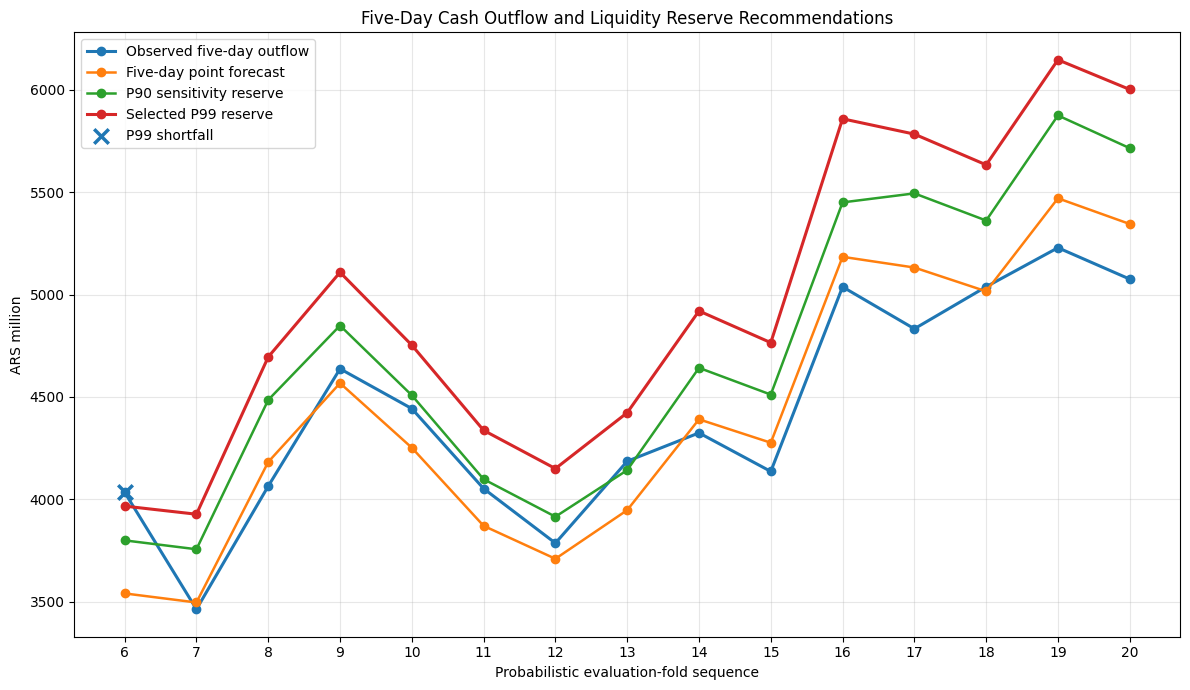

,check,observed,expected,status
0,operational_rows,15,15,PASS
1,one_summary_row,1,1,PASS
2,selected_policy_is_p99,True,True,PASS
3,sensitivity_policy_is_p90,True,True,PASS
4,analyst_adjustments_zero,True,True,PASS
5,final_reserve_identity,True,True,PASS
6,shortfall_idle_identity,True,True,PASS
7,shortfall_windows,1,1,PASS
8,nonfinite_operational_values,0,0,PASS
9,operational_figure_created,True,True,PASS



Operational recommendation summary:


,evaluation_windows,funding_lead_time_days,selected_policy_id,selected_policy_quantile,sensitivity_policy_id,operational_cost_ratio,mean_observed_outflow,mean_point_forecast,mean_selected_reserve,mean_increment_vs_point,shortfall_windows,service_level,total_shortfall_amount,mean_idle_capital,total_operational_cost,analyst_adjustments_applied
0,15,5,reserve_p99,0.9900,reserve_p90,19.0000,"4,422.4716","4,425.1513","4,964.6922",539.5409,1,0.9333,67.3872,546.7131,"9,481.0534",0



Operational recommendation preview:


,fold_id,target_start,target_end,observed_outflow,point_5d_total,reserve_p90,reserve_p95,reserve_p99,analyst_adjustment,final_reserve,shortfall_amount,idle_capital_amount,service_success
0,fold_06,2025-06-07,2025-06-11,"4,033.8440","3,539.8931","3,799.0279","3,845.6869","3,966.4568",0.0000,"3,966.4568",67.3872,0.0000,False
1,fold_07,2025-07-05,2025-07-09,"3,462.5410","3,495.5571","3,755.6751","3,860.3336","3,926.8340",0.0000,"3,926.8340",0.0000,464.2930,True
2,fold_08,2025-08-02,2025-08-06,"4,064.1200","4,182.2301","4,485.3340","4,542.9186","4,695.2773",0.0000,"4,695.2773",0.0000,631.1573,True
3,fold_09,2025-08-30,2025-09-03,"4,637.3750","4,567.3232","4,848.7192","4,973.4174","5,108.8023",0.0000,"5,108.8023",0.0000,471.4273,True
4,fold_10,2025-09-27,2025-10-01,"4,442.8300","4,251.6500","4,507.8998","4,594.4728","4,752.7522",0.0000,"4,752.7522",0.0000,309.9222,True
5,fold_11,2025-10-25,2025-10-29,"4,052.0690","3,870.0532","4,097.8525","4,182.2935","4,336.6378",0.0000,"4,336.6378",0.0000,284.5688,True
6,fold_12,2025-11-22,2025-11-26,"3,785.6300","3,709.1135","3,914.7061","3,985.9331","4,149.7639",0.0000,"4,149.7639",0.0000,364.1339,True
7,fold_13,2025-12-20,2025-12-24,"4,185.6870","3,946.7760","4,142.1505","4,235.4764","4,422.7773",0.0000,"4,422.7773",0.0000,237.0903,True
8,fold_14,2026-01-17,2026-01-21,"4,324.1540","4,390.5598","4,642.0074","4,749.3574","4,919.9743",0.0000,"4,919.9743",0.0000,595.8203,True
9,fold_15,2026-02-14,2026-02-18,"4,135.8440","4,276.1779","4,511.3931","4,610.4934","4,765.1395",0.0000,"4,765.1395",0.0000,629.2955,True


In [20]:
# ---------------------------------------------------------------------
# Operational recommendation table for Notebook 08 and dashboard use
# ---------------------------------------------------------------------
operational_liquidity_recommendations = (
    five_day_reserve_forecasts[
        [
            "fold_id",
            "fold_sequence",
            "forecast_origin",
            "target_start",
            "target_end",
            "actual_5d_total",
            "point_5d_total",
            "reserve_p50",
            "reserve_p80",
            "reserve_p90",
            "reserve_p95",
            "reserve_p99",
            "calibration_folds",
            "available_contiguous_blocks",
            "simulation_count",
            "joint_method_id",
        ]
    ]
    .copy()
    .sort_values("fold_sequence")
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Freeze the selected and sensitivity reserves
# ---------------------------------------------------------------------
operational_liquidity_recommendations[
    "daily_probabilistic_method"
] = SELECTED_PROBABILISTIC_METHOD

operational_liquidity_recommendations[
    "selected_policy_id"
] = SELECTED_RESERVE_POLICY

operational_liquidity_recommendations[
    "selected_policy_quantile"
] = 0.99

operational_liquidity_recommendations[
    "sensitivity_policy_id"
] = SENSITIVITY_RESERVE_POLICY

operational_liquidity_recommendations[
    "model_selected_reserve"
] = (
    operational_liquidity_recommendations[
        "reserve_p99"
    ]
)

operational_liquidity_recommendations[
    "sensitivity_reserve"
] = (
    operational_liquidity_recommendations[
        "reserve_p90"
    ]
)


# ---------------------------------------------------------------------
# Analyst-in-the-loop fields
# No adjustment is applied during backtesting.
# ---------------------------------------------------------------------
operational_liquidity_recommendations[
    "analyst_adjustment"
] = 0.0

operational_liquidity_recommendations[
    "adjustment_reason"
] = "NO_ADJUSTMENT_IN_BACKTEST"

operational_liquidity_recommendations[
    "final_reserve"
] = (
    operational_liquidity_recommendations[
        "model_selected_reserve"
    ]
    + operational_liquidity_recommendations[
        "analyst_adjustment"
    ]
)


# ---------------------------------------------------------------------
# Realized business outcomes
# ---------------------------------------------------------------------
operational_liquidity_recommendations[
    "observed_outflow"
] = (
    operational_liquidity_recommendations[
        "actual_5d_total"
    ]
)

operational_liquidity_recommendations[
    "shortfall_amount"
] = np.maximum(
    operational_liquidity_recommendations[
        "observed_outflow"
    ]
    - operational_liquidity_recommendations[
        "final_reserve"
    ],
    0.0,
)

operational_liquidity_recommendations[
    "idle_capital_amount"
] = np.maximum(
    operational_liquidity_recommendations[
        "final_reserve"
    ]
    - operational_liquidity_recommendations[
        "observed_outflow"
    ],
    0.0,
)

operational_liquidity_recommendations[
    "shortfall_event"
] = (
    operational_liquidity_recommendations[
        "shortfall_amount"
    ] > 0
)

operational_liquidity_recommendations[
    "service_success"
] = (
    ~operational_liquidity_recommendations[
        "shortfall_event"
    ]
)

operational_liquidity_recommendations[
    "operational_cost_ratio_shortfall_to_idle"
] = OPERATIONAL_COST_RATIO

operational_liquidity_recommendations[
    "shortfall_cost"
] = (
    OPERATIONAL_COST_RATIO
    * operational_liquidity_recommendations[
        "shortfall_amount"
    ]
)

operational_liquidity_recommendations[
    "idle_capital_cost"
] = (
    operational_liquidity_recommendations[
        "idle_capital_amount"
    ]
)

operational_liquidity_recommendations[
    "total_operational_cost"
] = (
    operational_liquidity_recommendations[
        "shortfall_cost"
    ]
    + operational_liquidity_recommendations[
        "idle_capital_cost"
    ]
)


# ---------------------------------------------------------------------
# Compact operational summary
# ---------------------------------------------------------------------
operational_recommendation_summary = pd.DataFrame(
    [
        {
            "evaluation_windows": len(
                operational_liquidity_recommendations
            ),
            "funding_lead_time_days": FUNDING_LEAD_TIME,
            "selected_policy_id": SELECTED_RESERVE_POLICY,
            "selected_policy_quantile": 0.99,
            "sensitivity_policy_id": (
                SENSITIVITY_RESERVE_POLICY
            ),
            "operational_cost_ratio": (
                OPERATIONAL_COST_RATIO
            ),
            "mean_observed_outflow": float(
                operational_liquidity_recommendations[
                    "observed_outflow"
                ].mean()
            ),
            "mean_point_forecast": float(
                operational_liquidity_recommendations[
                    "point_5d_total"
                ].mean()
            ),
            "mean_selected_reserve": float(
                operational_liquidity_recommendations[
                    "final_reserve"
                ].mean()
            ),
            "mean_increment_vs_point": float(
                (
                    operational_liquidity_recommendations[
                        "final_reserve"
                    ]
                    - operational_liquidity_recommendations[
                        "point_5d_total"
                    ]
                ).mean()
            ),
            "shortfall_windows": int(
                operational_liquidity_recommendations[
                    "shortfall_event"
                ].sum()
            ),
            "service_level": float(
                operational_liquidity_recommendations[
                    "service_success"
                ].mean()
            ),
            "total_shortfall_amount": float(
                operational_liquidity_recommendations[
                    "shortfall_amount"
                ].sum()
            ),
            "mean_idle_capital": float(
                operational_liquidity_recommendations[
                    "idle_capital_amount"
                ].mean()
            ),
            "total_operational_cost": float(
                operational_liquidity_recommendations[
                    "total_operational_cost"
                ].sum()
            ),
            "analyst_adjustments_applied": int(
                (
                    operational_liquidity_recommendations[
                        "analyst_adjustment"
                    ] != 0
                ).sum()
            ),
        }
    ]
)


# ---------------------------------------------------------------------
# Figure for Notebook 08 and the final README
# ---------------------------------------------------------------------
figure_data = (
    operational_liquidity_recommendations
    .sort_values("fold_sequence")
)

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    figure_data["fold_sequence"],
    figure_data["observed_outflow"],
    marker="o",
    linewidth=2.2,
    label="Observed five-day outflow",
)

ax.plot(
    figure_data["fold_sequence"],
    figure_data["point_5d_total"],
    marker="o",
    linewidth=1.8,
    label="Five-day point forecast",
)

ax.plot(
    figure_data["fold_sequence"],
    figure_data["sensitivity_reserve"],
    marker="o",
    linewidth=1.8,
    label="P90 sensitivity reserve",
)

ax.plot(
    figure_data["fold_sequence"],
    figure_data["final_reserve"],
    marker="o",
    linewidth=2.2,
    label="Selected P99 reserve",
)

shortfall_rows = figure_data.loc[
    figure_data["shortfall_event"]
]

if not shortfall_rows.empty:
    ax.scatter(
        shortfall_rows["fold_sequence"],
        shortfall_rows["observed_outflow"],
        marker="x",
        s=110,
        linewidths=2.5,
        label="P99 shortfall",
        zorder=5,
    )

ax.set_title(
    "Five-Day Cash Outflow and Liquidity Reserve Recommendations"
)
ax.set_xlabel("Probabilistic evaluation-fold sequence")
ax.set_ylabel("ARS million")
ax.set_xticks(
    figure_data["fold_sequence"]
)
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()

operational_figure_path = (
    FIGURES_DIR
    / "07_five_day_operational_liquidity_recommendations.png"
)

fig.savefig(
    operational_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------------------
# Operational-output audit
# ---------------------------------------------------------------------
final_reserve_identity_passed = bool(
    np.allclose(
        operational_liquidity_recommendations[
            "final_reserve"
        ],
        operational_liquidity_recommendations[
            "model_selected_reserve"
        ]
        + operational_liquidity_recommendations[
            "analyst_adjustment"
        ],
        atol=1e-10,
    )
)

business_identity_passed = bool(
    np.allclose(
        operational_liquidity_recommendations[
            "shortfall_amount"
        ]
        - operational_liquidity_recommendations[
            "idle_capital_amount"
        ],
        operational_liquidity_recommendations[
            "observed_outflow"
        ]
        - operational_liquidity_recommendations[
            "final_reserve"
        ],
        atol=1e-10,
    )
)

nonfinite_operational_values = int(
    (
        ~np.isfinite(
            operational_liquidity_recommendations[
                [
                    "observed_outflow",
                    "point_5d_total",
                    "model_selected_reserve",
                    "final_reserve",
                    "shortfall_amount",
                    "idle_capital_amount",
                    "total_operational_cost",
                ]
            ].to_numpy(dtype=float)
        )
    ).sum()
)

operational_output_audit = pd.DataFrame(
    [
        {
            "check": "operational_rows",
            "observed": len(
                operational_liquidity_recommendations
            ),
            "expected": 15,
        },
        {
            "check": "one_summary_row",
            "observed": len(
                operational_recommendation_summary
            ),
            "expected": 1,
        },
        {
            "check": "selected_policy_is_p99",
            "observed": (
                operational_liquidity_recommendations[
                    "selected_policy_id"
                ].nunique() == 1
                and operational_liquidity_recommendations[
                    "selected_policy_id"
                ].iloc[0] == "reserve_p99"
            ),
            "expected": True,
        },
        {
            "check": "sensitivity_policy_is_p90",
            "observed": (
                operational_liquidity_recommendations[
                    "sensitivity_policy_id"
                ].nunique() == 1
                and operational_liquidity_recommendations[
                    "sensitivity_policy_id"
                ].iloc[0] == "reserve_p90"
            ),
            "expected": True,
        },
        {
            "check": "analyst_adjustments_zero",
            "observed": bool(
                operational_liquidity_recommendations[
                    "analyst_adjustment"
                ].eq(0).all()
            ),
            "expected": True,
        },
        {
            "check": "final_reserve_identity",
            "observed": final_reserve_identity_passed,
            "expected": True,
        },
        {
            "check": "shortfall_idle_identity",
            "observed": business_identity_passed,
            "expected": True,
        },
        {
            "check": "shortfall_windows",
            "observed": int(
                operational_liquidity_recommendations[
                    "shortfall_event"
                ].sum()
            ),
            "expected": 1,
        },
        {
            "check": "nonfinite_operational_values",
            "observed": nonfinite_operational_values,
            "expected": 0,
        },
        {
            "check": "operational_figure_created",
            "observed": operational_figure_path.exists(),
            "expected": True,
        },
    ]
)

operational_output_audit["status"] = np.where(
    operational_output_audit[
        "observed"
    ].astype(str)
    == operational_output_audit[
        "expected"
    ].astype(str),
    "PASS",
    "FAIL",
)


# ---------------------------------------------------------------------
# Save outputs in the same cell
# ---------------------------------------------------------------------
operational_recommendations_path = (
    DATA_PROCESSED_DIR
    / "07_operational_liquidity_recommendations.csv"
)

operational_summary_path = (
    DATA_PROCESSED_DIR
    / "07_operational_liquidity_recommendation_summary.csv"
)

operational_output_audit_path = (
    DATA_PROCESSED_DIR
    / "07_operational_liquidity_output_audit.csv"
)

operational_liquidity_recommendations.to_csv(
    operational_recommendations_path,
    index=False,
)

operational_recommendation_summary.to_csv(
    operational_summary_path,
    index=False,
)

operational_output_audit.to_csv(
    operational_output_audit_path,
    index=False,
)


required_operational_paths = [
    operational_recommendations_path,
    operational_summary_path,
    operational_output_audit_path,
    operational_figure_path,
]

assert all(
    path.exists()
    for path in required_operational_paths
)

assert operational_output_audit[
    "status"
].eq("PASS").all(), (
    "The operational liquidity output failed its audit."
)


display(operational_output_audit)

print("\nOperational recommendation summary:")
display(operational_recommendation_summary)

print("\nOperational recommendation preview:")
display(
    operational_liquidity_recommendations[
        [
            "fold_id",
            "target_start",
            "target_end",
            "observed_outflow",
            "point_5d_total",
            "reserve_p90",
            "reserve_p95",
            "reserve_p99",
            "analyst_adjustment",
            "final_reserve",
            "shortfall_amount",
            "idle_capital_amount",
            "service_success",
        ]
    ]
)

## 17. Notebook 07 conclusions

This notebook extended the frozen universal point model into a probabilistic forecasting and liquidity-policy framework.

### Daily probabilistic forecasts

The selected daily marginal method is:

```text
empirical_log_expanding

In [21]:

# ---------------------------------------------------------------------
# Notebook 07 final paths
# ---------------------------------------------------------------------
notebook07_summary_path = (
    DATA_PROCESSED_DIR
    / "07_notebook07_technical_summary.csv"
)

notebook08_handoff_path = (
    DATA_PROCESSED_DIR
    / "07_notebook08_handoff.csv"
)

notebook07_closure_audit_path = (
    DATA_PROCESSED_DIR
    / "07_notebook07_closure_audit.csv"
)

notebook07_artifact_registry_path = (
    DATA_PROCESSED_DIR
    / "07_notebook07_artifact_registry.csv"
)


# Create a placeholder so its existence can be included in the closure audit.
pd.DataFrame(
    columns=[
        "artifact_name",
        "relative_path",
        "artifact_group",
        "file_extension",
        "file_size_bytes",
        "row_count",
        "column_count",
        "read_status",
    ]
).to_csv(
    notebook07_artifact_registry_path,
    index=False,
)


# ---------------------------------------------------------------------
# Recover the frozen final rows
# ---------------------------------------------------------------------
daily_method_row = (
    probabilistic_method_decision.iloc[0]
)

joint_method_row = (
    five_day_joint_method_decision.iloc[0]
)

policy_decision_row = (
    liquidity_reserve_policy_decision.iloc[0]
)

operational_summary_row = (
    operational_recommendation_summary.iloc[0]
)


# ---------------------------------------------------------------------
# Notebook 07 technical summary
# ---------------------------------------------------------------------
notebook07_technical_summary = pd.DataFrame(
    [
        {
            "notebook": (
                "07_probabilistic_forecasting_and_liquidity_policy"
            ),
            "notebook_status": (
                "VALIDATED_NOTEBOOK07_PROBABILISTIC_"
                "FORECASTING_AND_LIQUIDITY_POLICY"
            ),
            "final_point_model": FINAL_POINT_MODEL,
            "point_model_status": "FROZEN_FROM_NOTEBOOK06",
            "daily_probabilistic_method": (
                SELECTED_PROBABILISTIC_METHOD
            ),
            "daily_probabilistic_evaluation_rows": (
                len(selected_probabilistic_predictions)
            ),
            "daily_probabilistic_evaluation_folds": (
                selected_probabilistic_predictions[
                    "fold_id"
                ].nunique()
            ),
            "daily_p95_coverage": float(
                daily_method_row["p95_coverage"]
            ),
            "daily_p99_coverage": float(
                daily_method_row["p99_coverage"]
            ),
            "daily_pi90_coverage": float(
                daily_method_row["pi90_coverage"]
            ),
            "daily_pi98_coverage": float(
                daily_method_row["pi98_coverage"]
            ),
            "joint_five_day_method": (
                SELECTED_FIVE_DAY_JOINT_METHOD
            ),
            "funding_lead_time_days": FUNDING_LEAD_TIME,
            "five_day_evaluation_windows": int(
                joint_method_row["evaluation_folds"]
            ),
            "five_day_p95_coverage": float(
                joint_method_row["p95_coverage"]
            ),
            "five_day_p99_coverage": float(
                joint_method_row["p99_coverage"]
            ),
            "five_day_p95_exceedances": int(
                joint_method_row["p95_exceedances"]
            ),
            "five_day_p99_exceedances": int(
                joint_method_row["p99_exceedances"]
            ),
            "selected_reserve_policy": (
                SELECTED_RESERVE_POLICY
            ),
            "selected_reserve_quantile": float(
                policy_decision_row[
                    "selected_policy_quantile"
                ]
            ),
            "sensitivity_reserve_policy": (
                SENSITIVITY_RESERVE_POLICY
            ),
            "operational_cost_ratio": (
                OPERATIONAL_COST_RATIO
            ),
            "p95_p99_break_even_ratio": float(
                policy_decision_row[
                    "p95_p99_full_sample_break_even_ratio"
                ]
            ),
            "mean_selected_reserve_ars_million": float(
                operational_summary_row[
                    "mean_selected_reserve"
                ]
            ),
            "mean_increment_vs_point_ars_million": float(
                operational_summary_row[
                    "mean_increment_vs_point"
                ]
            ),
            "observed_service_level": float(
                operational_summary_row[
                    "service_level"
                ]
            ),
            "shortfall_windows": int(
                operational_summary_row[
                    "shortfall_windows"
                ]
            ),
            "total_shortfall_ars_million": float(
                operational_summary_row[
                    "total_shortfall_amount"
                ]
            ),
            "mean_idle_capital_ars_million": float(
                operational_summary_row[
                    "mean_idle_capital"
                ]
            ),
            "total_operational_cost": float(
                operational_summary_row[
                    "total_operational_cost"
                ]
            ),
            "analyst_adjustments_applied": int(
                operational_summary_row[
                    "analyst_adjustments_applied"
                ]
            ),
            "settlement_status": (
                "CONDITIONAL_SCENARIO_ONLY"
            ),
            "evidence_limitation": (
                "Five-day policy evidence is based on "
                "15 prequential evaluation windows."
            ),
            "next_notebook": (
                "08_dashboard_data_and_final_results"
            ),
            "next_step_status": (
                "READY_FOR_NOTEBOOK08_DASHBOARD_AND_FINAL_RESULTS"
            ),
        }
    ]
)

notebook07_technical_summary.to_csv(
    notebook07_summary_path,
    index=False,
)

assert notebook07_summary_path.exists()


# ---------------------------------------------------------------------
# Structured handoff to Notebook 08
# ---------------------------------------------------------------------
notebook08_handoff_rows = [
    {
        "section": "status",
        "key": "notebook07_status",
        "value": (
            "VALIDATED_NOTEBOOK07_PROBABILISTIC_"
            "FORECASTING_AND_LIQUIDITY_POLICY"
        ),
    },
    {
        "section": "point_forecast",
        "key": "final_point_model",
        "value": FINAL_POINT_MODEL,
    },
    {
        "section": "probabilistic_forecast",
        "key": "daily_probabilistic_method",
        "value": SELECTED_PROBABILISTIC_METHOD,
    },
    {
        "section": "probabilistic_forecast",
        "key": "joint_five_day_method",
        "value": SELECTED_FIVE_DAY_JOINT_METHOD,
    },
    {
        "section": "probabilistic_forecast",
        "key": "funding_lead_time_days",
        "value": str(FUNDING_LEAD_TIME),
    },
    {
        "section": "reserve_policy",
        "key": "selected_policy",
        "value": SELECTED_RESERVE_POLICY,
    },
    {
        "section": "reserve_policy",
        "key": "selected_quantile",
        "value": "0.99",
    },
    {
        "section": "reserve_policy",
        "key": "sensitivity_policy",
        "value": SENSITIVITY_RESERVE_POLICY,
    },
    {
        "section": "reserve_policy",
        "key": "operational_cost_ratio",
        "value": str(OPERATIONAL_COST_RATIO),
    },
    {
        "section": "reserve_policy",
        "key": "p95_p99_break_even_ratio",
        "value": (
            f"{policy_decision_row['p95_p99_full_sample_break_even_ratio']:.4f}"
        ),
    },
    {
        "section": "operational_results",
        "key": "mean_selected_reserve_ars_million",
        "value": (
            f"{operational_summary_row['mean_selected_reserve']:.4f}"
        ),
    },
    {
        "section": "operational_results",
        "key": "service_level",
        "value": (
            f"{operational_summary_row['service_level']:.4f}"
        ),
    },
    {
        "section": "operational_results",
        "key": "shortfall_windows",
        "value": str(
            int(
                operational_summary_row[
                    "shortfall_windows"
                ]
            )
        ),
    },
    {
        "section": "operational_results",
        "key": "total_shortfall_ars_million",
        "value": (
            f"{operational_summary_row['total_shortfall_amount']:.4f}"
        ),
    },
    {
        "section": "operational_results",
        "key": "mean_idle_capital_ars_million",
        "value": (
            f"{operational_summary_row['mean_idle_capital']:.4f}"
        ),
    },
    {
        "section": "operational_results",
        "key": "total_operational_cost",
        "value": (
            f"{operational_summary_row['total_operational_cost']:.4f}"
        ),
    },
    {
        "section": "limitations",
        "key": "five_day_evaluation_windows",
        "value": "15",
    },
    {
        "section": "limitations",
        "key": "settlement_status",
        "value": "CONDITIONAL_SCENARIO_ONLY",
    },
    {
        "section": "limitations",
        "key": "analyst_adjustments",
        "value": "NOT_APPLIED_IN_BACKTEST",
    },
    {
        "section": "required_artifact",
        "key": "operational_recommendations",
        "value": operational_recommendations_path.name,
    },
    {
        "section": "required_artifact",
        "key": "operational_summary",
        "value": operational_summary_path.name,
    },
    {
        "section": "required_artifact",
        "key": "final_policy_decision",
        "value": final_policy_decision_path.name,
    },
    {
        "section": "required_artifact",
        "key": "daily_probabilistic_predictions",
        "value": selected_predictions_path.name,
    },
    {
        "section": "required_artifact",
        "key": "five_day_cumulative_forecasts",
        "value": selected_joint_forecasts_path.name,
    },
    {
        "section": "required_figure",
        "key": "operational_liquidity_figure",
        "value": operational_figure_path.name,
    },
    {
        "section": "required_figure",
        "key": "cost_sensitivity_figure",
        "value": cost_sensitivity_figure_path.name,
    },
    {
        "section": "next_step",
        "key": "next_notebook",
        "value": (
            "08_dashboard_data_and_final_results.ipynb"
        ),
    },
    {
        "section": "next_step",
        "key": "next_status",
        "value": (
            "READY_FOR_NOTEBOOK08_DASHBOARD_AND_FINAL_RESULTS"
        ),
    },
    {
        "section": "next_step",
        "key": "instruction",
        "value": (
            "Consolidate final dashboard tables and figures, "
            "prepare the business recommendation, close the "
            "README and document limitations without reopening "
            "model or reserve-policy selection."
        ),
    },
]

notebook08_handoff = pd.DataFrame(
    notebook08_handoff_rows
)

notebook08_handoff.to_csv(
    notebook08_handoff_path,
    index=False,
)

assert notebook08_handoff_path.exists()


# ---------------------------------------------------------------------
# Verify all previous Notebook 07 audits without recomputing them
# ---------------------------------------------------------------------
audit_tables = [
    startup_audit,
    probabilistic_base_audit,
    probabilistic_protocol_audit,
    probabilistic_generation_audit,
    probabilistic_evaluation_audit,
    horizon_stability_audit,
    condition_evaluation_audit,
    probabilistic_method_selection_audit,
    five_day_joint_generation_audit,
    five_day_joint_evaluation_audit,
    five_day_joint_method_selection_audit,
    reserve_scenario_audit,
    liquidity_policy_evaluation_audit,
    liquidity_cost_sensitivity_audit,
    leave_one_out_policy_audit,
    liquidity_policy_selection_audit,
    operational_output_audit,
]

all_previous_audits_pass = bool(
    all(
        audit_table["status"].eq("PASS").all()
        for audit_table in audit_tables
    )
)


# ---------------------------------------------------------------------
# Required closure artifacts
# ---------------------------------------------------------------------
required_closure_artifacts = [
    notebook07_summary_path,
    notebook08_handoff_path,
    notebook07_artifact_registry_path,
    selected_predictions_path,
    method_decision_path,
    selected_joint_forecasts_path,
    joint_method_decision_path,
    final_policy_decision_path,
    operational_recommendations_path,
    operational_summary_path,
    calibration_figure_path,
    horizon_pinball_figure_path,
    cost_sensitivity_figure_path,
    operational_figure_path,
]

required_closure_artifacts_exist = bool(
    all(
        path.exists()
        for path in required_closure_artifacts
    )
)


# ---------------------------------------------------------------------
# Notebook 07 closure audit
# ---------------------------------------------------------------------
notebook07_closure_audit = pd.DataFrame(
    [
        {
            "check": "all_previous_audits_pass",
            "observed": all_previous_audits_pass,
            "expected": True,
        },
        {
            "check": "final_point_model_remains_frozen",
            "observed": FINAL_POINT_MODEL,
            "expected": (
                "calendar_promotion_trend_arima011_errors"
            ),
        },
        {
            "check": "daily_probabilistic_method_selected",
            "observed": SELECTED_PROBABILISTIC_METHOD,
            "expected": "empirical_log_expanding",
        },
        {
            "check": "joint_five_day_method_selected",
            "observed": SELECTED_FIVE_DAY_JOINT_METHOD,
            "expected": "moving_block_log_bootstrap",
        },
        {
            "check": "one_final_reserve_policy_selected",
            "observed": SELECTED_RESERVE_POLICY,
            "expected": "reserve_p99",
        },
        {
            "check": "sensitivity_policy_retained",
            "observed": SENSITIVITY_RESERVE_POLICY,
            "expected": "reserve_p90",
        },
        {
            "check": "daily_probabilistic_rows",
            "observed": len(
                selected_probabilistic_predictions
            ),
            "expected": 420,
        },
        {
            "check": "five_day_evaluation_windows",
            "observed": len(
                operational_liquidity_recommendations
            ),
            "expected": 15,
        },
        {
            "check": "operational_shortfall_windows",
            "observed": int(
                operational_liquidity_recommendations[
                    "shortfall_event"
                ].sum()
            ),
            "expected": 1,
        },
        {
            "check": "analyst_adjustments_not_applied",
            "observed": int(
                (
                    operational_liquidity_recommendations[
                        "analyst_adjustment"
                    ] != 0
                ).sum()
            ),
            "expected": 0,
        },
        {
            "check": "required_closure_artifacts_exist",
            "observed": (
                required_closure_artifacts_exist
            ),
            "expected": True,
        },
        {
            "check": "notebook08_handoff_ready",
            "observed": (
                notebook07_technical_summary[
                    "next_step_status"
                ].iloc[0]
            ),
            "expected": (
                "READY_FOR_NOTEBOOK08_DASHBOARD_AND_FINAL_RESULTS"
            ),
        },
    ]
)

notebook07_closure_audit["status"] = np.where(
    notebook07_closure_audit[
        "observed"
    ].astype(str)
    == notebook07_closure_audit[
        "expected"
    ].astype(str),
    "PASS",
    "FAIL",
)

notebook07_closure_audit.to_csv(
    notebook07_closure_audit_path,
    index=False,
)

assert notebook07_closure_audit_path.exists()
assert notebook07_closure_audit[
    "status"
].eq("PASS").all()


# ---------------------------------------------------------------------
# Complete Notebook 07 artifact registry
# ---------------------------------------------------------------------
artifact_rows = []

artifact_directories = [
    ("processed_table", DATA_PROCESSED_DIR),
    ("figure", FIGURES_DIR),
    ("model", MODELS_DIR),
]

for artifact_group, artifact_directory in artifact_directories:

    for artifact_path in sorted(
        artifact_directory.glob("07_*")
    ):
        if (
            artifact_path
            == notebook07_artifact_registry_path
        ):
            continue

        row_count = np.nan
        column_count = np.nan
        read_status = "NOT_APPLICABLE"

        if artifact_path.suffix.lower() == ".csv":
            try:
                artifact_data = pd.read_csv(
                    artifact_path
                )

                row_count = len(artifact_data)
                column_count = len(
                    artifact_data.columns
                )
                read_status = "READABLE"
            except Exception as error:
                read_status = (
                    f"READ_ERROR: {type(error).__name__}"
                )

        try:
            relative_path = str(
                artifact_path.relative_to(
                    PROJECT_ROOT
                )
            )
        except ValueError:
            relative_path = str(artifact_path)

        artifact_rows.append(
            {
                "artifact_name": artifact_path.name,
                "relative_path": relative_path,
                "artifact_group": artifact_group,
                "file_extension": (
                    artifact_path.suffix.lower()
                ),
                "file_size_bytes": (
                    artifact_path.stat().st_size
                ),
                "row_count": row_count,
                "column_count": column_count,
                "read_status": read_status,
            }
        )


notebook07_artifact_registry = pd.DataFrame(
    artifact_rows
)

# Register the registry itself without introducing a circular size calculation.
notebook07_artifact_registry = pd.concat(
    [
        notebook07_artifact_registry,
        pd.DataFrame(
            [
                {
                    "artifact_name": (
                        notebook07_artifact_registry_path.name
                    ),
                    "relative_path": str(
                        notebook07_artifact_registry_path.relative_to(
                            PROJECT_ROOT
                        )
                    ),
                    "artifact_group": "processed_table",
                    "file_extension": ".csv",
                    "file_size_bytes": np.nan,
                    "row_count": np.nan,
                    "column_count": np.nan,
                    "read_status": "SELF_REGISTERED",
                }
            ]
        ),
    ],
    ignore_index=True,
)

notebook07_artifact_registry = (
    notebook07_artifact_registry
    .sort_values(
        ["artifact_group", "artifact_name"]
    )
    .reset_index(drop=True)
)

notebook07_artifact_registry.to_csv(
    notebook07_artifact_registry_path,
    index=False,
)

assert notebook07_artifact_registry_path.exists()


# ---------------------------------------------------------------------
# Add artifact counts to the technical summary
# ---------------------------------------------------------------------
notebook07_technical_summary[
    "registered_artifacts"
] = len(
    notebook07_artifact_registry
)

notebook07_technical_summary[
    "registered_processed_tables"
] = int(
    (
        notebook07_artifact_registry[
            "artifact_group"
        ] == "processed_table"
    ).sum()
)

notebook07_technical_summary[
    "registered_figures"
] = int(
    (
        notebook07_artifact_registry[
            "artifact_group"
        ] == "figure"
    ).sum()
)

notebook07_technical_summary[
    "closure_checks_passed"
] = int(
    notebook07_closure_audit[
        "status"
    ].eq("PASS").sum()
)

notebook07_technical_summary[
    "closure_checks_failed"
] = int(
    notebook07_closure_audit[
        "status"
    ].eq("FAIL").sum()
)

notebook07_technical_summary.to_csv(
    notebook07_summary_path,
    index=False,
)


# ---------------------------------------------------------------------
# Final existence checks
# ---------------------------------------------------------------------
final_notebook07_paths = [
    notebook07_summary_path,
    notebook08_handoff_path,
    notebook07_closure_audit_path,
    notebook07_artifact_registry_path,
]

assert all(
    path.exists()
    for path in final_notebook07_paths
)


display(notebook07_closure_audit)

print("\nNotebook 07 technical summary:")
display(notebook07_technical_summary)

print("\nNotebook 08 handoff:")
display(notebook08_handoff)

print("\nArtifact registry summary:")
display(
    notebook07_artifact_registry
    .groupby(
        "artifact_group",
        as_index=False,
    )
    .agg(
        registered_artifacts=(
            "artifact_name",
            "size",
        )
    )
)

print(
    "\nNotebook 07 closed successfully:"
    "\nVALIDATED_NOTEBOOK07_PROBABILISTIC_"
    "FORECASTING_AND_LIQUIDITY_POLICY"
    "\n\nNext status:"
    "\nREADY_FOR_NOTEBOOK08_DASHBOARD_AND_FINAL_RESULTS"
)

,check,observed,expected,status
0,all_previous_audits_pass,True,True,PASS
1,final_point_model_remains_frozen,calendar_promotion_trend_arima011_errors,calendar_promotion_trend_arima011_errors,PASS
2,daily_probabilistic_method_selected,empirical_log_expanding,empirical_log_expanding,PASS
3,joint_five_day_method_selected,moving_block_log_bootstrap,moving_block_log_bootstrap,PASS
4,one_final_reserve_policy_selected,reserve_p99,reserve_p99,PASS
5,sensitivity_policy_retained,reserve_p90,reserve_p90,PASS
6,daily_probabilistic_rows,420,420,PASS
7,five_day_evaluation_windows,15,15,PASS
8,operational_shortfall_windows,1,1,PASS
9,analyst_adjustments_not_applied,0,0,PASS



Notebook 07 technical summary:


,notebook,notebook_status,final_point_model,point_model_status,daily_probabilistic_method,daily_probabilistic_evaluation_rows,daily_probabilistic_evaluation_folds,daily_p95_coverage,daily_p99_coverage,daily_pi90_coverage,daily_pi98_coverage,joint_five_day_method,funding_lead_time_days,five_day_evaluation_windows,five_day_p95_coverage,five_day_p99_coverage,five_day_p95_exceedances,five_day_p99_exceedances,selected_reserve_policy,selected_reserve_quantile,sensitivity_reserve_policy,operational_cost_ratio,p95_p99_break_even_ratio,mean_selected_reserve_ars_million,mean_increment_vs_point_ars_million,observed_service_level,shortfall_windows,total_shortfall_ars_million,mean_idle_capital_ars_million,total_operational_cost,analyst_adjustments_applied,settlement_status,evidence_limitation,next_notebook,next_step_status,registered_artifacts,registered_processed_tables,registered_figures,closure_checks_passed,closure_checks_failed
0,07_probabilistic_forecasting_and_liquidity_policy,VALIDATED_NOTEBOOK07_PROBABILISTIC_FORECASTING...,calendar_promotion_trend_arima011_errors,FROZEN_FROM_NOTEBOOK06,empirical_log_expanding,420,15,0.9690,0.9929,0.9310,0.9810,moving_block_log_bootstrap,5,15,0.9333,0.9333,1,1,reserve_p99,0.9900,reserve_p90,19.0000,17.0653,"4,964.6922",539.5409,0.9333,1,67.3872,546.7131,"9,481.0534",0,CONDITIONAL_SCENARIO_ONLY,Five-day policy evidence is based on 15 preque...,08_dashboard_data_and_final_results,READY_FOR_NOTEBOOK08_DASHBOARD_AND_FINAL_RESULTS,87,82,5,12,0



Notebook 08 handoff:


,section,key,value
0,status,notebook07_status,VALIDATED_NOTEBOOK07_PROBABILISTIC_FORECASTING...
1,point_forecast,final_point_model,calendar_promotion_trend_arima011_errors
2,probabilistic_forecast,daily_probabilistic_method,empirical_log_expanding
3,probabilistic_forecast,joint_five_day_method,moving_block_log_bootstrap
4,probabilistic_forecast,funding_lead_time_days,5
5,reserve_policy,selected_policy,reserve_p99
6,reserve_policy,selected_quantile,0.99
7,reserve_policy,sensitivity_policy,reserve_p90
8,reserve_policy,operational_cost_ratio,19.0
9,reserve_policy,p95_p99_break_even_ratio,17.0653



Artifact registry summary:


,artifact_group,registered_artifacts
0,figure,5
1,processed_table,82



Notebook 07 closed successfully:
VALIDATED_NOTEBOOK07_PROBABILISTIC_FORECASTING_AND_LIQUIDITY_POLICY

Next status:
READY_FOR_NOTEBOOK08_DASHBOARD_AND_FINAL_RESULTS
